In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
from numpy.lib.stride_tricks import sliding_window_view
from UPVfab_tools import open_file, filter_wavelength, find_minima

# Functions

In [2]:
def calculate_FSR(wavelength_dut, power_dut, threshold, separation, dL, plot=False):
    #####################################################################################################################
    # Function to calculate FSR from MZI spectrum
    # Inputs:
    # - wavelength_dut: array of wavelength values for the DUT
    # - power_dut: array of power values for the DUT
    # - threshold: minimum prominence of the peaks for minima detection
    # - separation: minimum distance between peaks for minima detection
    # - dL: path length difference of the MZI in meters
    # - plot: boolean to indicate whether to plot the power difference and detected minima (default
    # Outputs:
    # - fsr: calculated FSR value in nm
    # - ng: calculated group index value
    # - indices: array of indices of detected minima
    #####################################################################################################################

    # Find indices of minima in the power spectrum
    indices = find_minima(power_dut, wavelength_dut, threshold, separation) 

    # Calculate FSR and group index
    fsr = np.diff(wavelength_dut[indices]).mean()
    ng = (wavelength_dut[indices]**2/(fsr*dL)*1e-9)

    # Plot power difference and detected minima
    if plot == True:
        plt.plot(wavelength_dut, power_dut, label='Power Difference')
        plt.scatter(wavelength_dut[indices], power_dut[indices], color='red', label='Detected Minima')
        plt.xlabel('Wavelength (nm)')
        plt.ylabel('Power Difference (dB)')
        plt.legend()
        plt.grid()
        plt.show()

    return fsr, ng, indices

def mean_array(arrays):
    #####################################################################################################################
    # Function to calculate mean array from a list of arrays
    # Inputs:
    # - arrays: list of arrays to be averaged
    # Outputs:
    # - mean: array of mean values calculated from the input arrays
    #####################################################################################################################
    array_df = pd.DataFrame(arrays)
    mean = np.array(array_df.mean(axis=0).tolist())

    return mean

def ideal_dephase(wavelength_dut, power_dut_11, power_dut_12, normalize = False):
    ######################################################################################################################
    # Function to calculate ideal dephase from power values of the two MZI arms
    # Inputs:
    # - wavelength_dut: array of wavelength values for the DUT
    # - power_dut_11: array of power values for arm 1 of the DUT
    # - power_dut_12: array of power values for arm 2 of the DUT
    # - normalize: boolean to indicate whether to normalize power values to the maximum (default: False)
    # Outputs:
    # - delta_phi: calculated ideal dephase in radians
    ######################################################################################################################

    # Normalize power values to the maximum if normalize is set to True
    if normalize == True:
        power_dut_11 = power_dut_11 - np.max(power_dut_11) 
        power_dut_12 = power_dut_12 - np.max(power_dut_12)

    # Convert power from dB to linear scale
    power_1 = 10**(power_dut_11/10)
    power_2 = 10**(power_dut_12/10)

    # Calculate ideal absolute dephase using the formula: |delta_phi| = 2*arctan(sqrt(P2/P1))
    delta_phi = 2*np.arctan(np.sqrt(power_2/power_1))

    return delta_phi

def refractive_indices(wavelength_dut_left, wavelength_dut_center, wavelength_dut_right, power_dut_left, power_dut_center, power_dut_right, indices_left, indices_center, indices_right, fsr, ng_center, plot = False):
    #######################################################################################################################
    # Function to calculate refractive indices from the detected minima in the power spectrum of the three MZI arms
    # Inputs:
    # - wavelength_dut_left: array of wavelength values for the left peak
    # - wavelength_dut_center: array of wavelength values for the center peak
    # - wavelength_dut_right: array of wavelength values for the right peak
    # - power_dut_left: array of power values for the left peak
    # - power_dut_center: array of power values for the center peak
    # - power_dut_right: array of power values for the right peak
    # - indices_left: array of indices of detected minima for the left
    # - indices_center: array of indices of detected minima for the center
    # - indices_right: array of indices of detected minima for the right
    # - fsr: calculated FSR value in nm
    # - ng_center: calculated group index value for the center
    # - plot: boolean to indicate whether to plot the power spectra around the detected minima (default: False)
    # Outputs:
    # - delta_lambda: array of wavelength differences between the detected minima of the three peaks
    # - delta_neff: array of effective index differences calculated from the wavelength differences and group index
    #######################################################################################################################

    # Calculate mean indices from the three peaks
    indices = mean_array([indices_right, indices_center, indices_left]).astype(int)

    # Calculate wavelength differences and effective index differences
    delta_lambda = np.zeros(len(indices_right))
    delta_neff = np.zeros(len(indices_right))
    
    # Calculate wavelength differences and effective index differences for each detected minimum
    for j in range(len(indices_right)):
        delta_lambda[j] = (abs(wavelength_dut_right[indices_right[j]] - wavelength_dut_center[indices_center[j]]) + abs(wavelength_dut_left[indices_left[j]] - wavelength_dut_center[indices_center[j]]))/2
        delta_neff[j] = ng_center[j]/wavelength_dut_center[indices_center[j]]*delta_lambda[j]
    
    # Plot power spectra around the detected minima
    if plot == True:
        counts = 0
        for i in range(len(indices_right)):
            wl_0 = wavelength_dut_center[indices[0]] + (i-1/2)*fsr
            wl_1 = wavelength_dut_center[indices[0]] + (i+1/2)*fsr
            wl_min = min(wavelength_dut_center)
            wl_max = max(wavelength_dut_center)
    
            if (wl_min < wl_0 < wl_max) & (wl_min < wl_1 < wl_max):
                counts += 1

                filtered_wavelength_dut_right, filtered_power_dut_right = filter_wavelength(wavelength_dut_right, power_dut_right, wl_0, wl_1)
                filtered_wavelength_dut_center, filtered_power_dut_center = filter_wavelength(wavelength_dut_center, power_dut_center, wl_0, wl_1)
                filtered_wavelength_dut_left, filtered_power_dut_left = filter_wavelength(wavelength_dut_left, power_dut_left, wl_0, wl_1)

                plt.plot(filtered_wavelength_dut_right, filtered_power_dut_right, label='Right')
                plt.plot(filtered_wavelength_dut_center, filtered_power_dut_center, label='Center')
                plt.plot(filtered_wavelength_dut_left, filtered_power_dut_left, label='Left')

                plt.scatter(wavelength_dut_right[indices_right[i]], power_dut_right[indices_right[i]], color='r')
                plt.scatter(wavelength_dut_center[indices_center[i]], power_dut_center[indices_center[i]], color='r')
                plt.scatter(wavelength_dut_left[indices_left[i]], power_dut_left[indices_left[i]], color='r')

                plt.grid()
                plt.legend()
                plt.show()

        # If no valid minima are found within the wavelength range, plot the spectra around the detected minima without filtering
        if counts == 0:
            for i in range(len(indices_right)):
                wl_0 = (1-i)*(wavelength_dut_right[0]) + i*(wavelength_dut_right[indices[0]] + fsr/2)
                wl_1 = (1-i)*(wavelength_dut_right[indices[0]] + fsr/2) + i*(wavelength_dut_right[-1])

                filtered_wavelength_dut_right, filtered_power_dut_right = filter_wavelength(wavelength_dut_right, power_dut_right, wl_0, wl_1)
                filtered_wavelength_dut_center, filtered_power_dut_center = filter_wavelength(wavelength_dut_center, power_dut_center, wl_0, wl_1)
                filtered_wavelength_dut_left, filtered_power_dut_left = filter_wavelength(wavelength_dut_left, power_dut_left, wl_0, wl_1)

                plt.plot(filtered_wavelength_dut_right, filtered_power_dut_right, label='Right')
                plt.plot(filtered_wavelength_dut_center, filtered_power_dut_center, label='Center')
                plt.plot(filtered_wavelength_dut_left, filtered_power_dut_left, label='Left')

                plt.scatter(wavelength_dut_right[indices_right[i]], power_dut_right[indices_right[i]], color='r')
                plt.scatter(wavelength_dut_center[indices_center[i]], power_dut_center[indices_center[i]], color='r')
                plt.scatter(wavelength_dut_left[indices_left[i]], power_dut_left[indices_left[i]], color='r')

                plt.grid()
                plt.legend()
                plt.show()

    return delta_lambda, delta_neff

def cosine_fit(wavelength_dut, power_dut, dL, wavelength_out = None):
    #####################################################################################################################
    # Function to fit a cosine model to the power spectrum of an MZI and extract fitting parameters
    # Inputs:
    # - wavelength_dut: array of wavelength values for the DUT
    # - power_dut: array of power values for the DUT
    # - dL: path length difference of the MZI in meters
    # - wavelength_out: array of wavelength values for the output (optional, default: None, in which case it will be set to wavelength_dut)
    # Outputs:
    # - power_fit: array of power values obtained from the cosine fit
    # - popt: array of fitting parameters obtained from the curve fit (p_in and n_0)
    # Note: The fitting parameters are:
    # - p_in: input power to the MZI
    # - n_0: effective index of the MZI
    #####################################################################################################################
    
    # Convert data units and prepare for fitting
    power_linear = 10**(power_dut/10)
    wl_0 = 1550
    dL = dL*1e9

    # Define the cosine model for fitting
    def cosine_model(wl, p_in, n_0, d_n):
        # Linear dependence of effective index on wavelength
        n_eff = n_0 + d_n*(wl - wl_0) 
        return p_in*np.cos(np.pi*n_eff/wl*dL)**2
    
    # Set initial guess and bounds for fitting parameters
    p0 = [1, 1.9, -1e-5]
    limits = ([0, 1.8, -1e-4], [2, 2.2, 1e-4])
    popt, pcov = curve_fit(cosine_model, wavelength_dut, power_linear, bounds = limits, p0=p0, maxfev = 1e5)

    # If wavelength_out is not provided, set it to wavelength_dut
    if wavelength_out is None:
        wavelength_out = wavelength_dut

    power_fit = cosine_model(wavelength_out, *popt)

    # Convert fitted power back to dB scale
    power_fit = 10*np.log10(power_fit) 

    return power_fit, popt

def surpress_noise(wavelength_dut, power_dut, window_size, threshold_dB, sensitivity=2, plot=False):
    ######################################################################################################################
    # Function to suppress noise in the power spectrum using a rolling standard deviation method
    # Inputs:
    # - wavelength_dut: array of wavelength values for the DUT
    # - power_dut: array of power values for the DUT (in dB)
    # - window_size: size of the rolling window in nm
    # - threshold_dB: threshold in dB for noise suppression
    # - plot: boolean to indicate whether to plot the filtered spectrum and suppressed noise (default: False)
    # Outputs:
    # - wavelength_filtered: array of wavelength values for the filtered spectrum
    # - power_filtered: array of power values for the filtered spectrum (in dB)
    # - wavelength_noise: array of wavelength values for the suppressed noise
    # - power_noise: array of power values for the suppressed noise (in dB)
    ######################################################################################################################

    # Convert power from dB to linear scale
    power_dut_linear = 10**(power_dut/10) 

    # Calculate the number of points in the rolling window based on the specified window size and the average step size in wavelength
    step = np.mean(np.diff(wavelength_dut))
    window_size_points = int(window_size / step)
    windows = sliding_window_view(power_dut_linear, window_shape=window_size_points)

     # Calculate rolling standard deviation using a sliding window view
    rolling_std = np.std(windows, axis=1) 

    # Pad the rolling standard deviation array to match the original length of the power array
    pad_start = (window_size_points - 1) // 2
    pad_end = (window_size_points - 1) - pad_start
    rolling_std_full = np.pad(rolling_std, (pad_start, pad_end), mode='edge')

    # Calculate median and MAD of the rolling standard deviation to determine the noise threshold
    median_std = np.median(rolling_std_full)
    mad_std = np.median(np.abs(rolling_std_full - median_std))
    threshold = median_std + (sensitivity * mad_std)

    # Identify noisy regions where the rolling standard deviation exceeds the threshold
    noisy_regions = rolling_std_full > threshold

    changes = np.diff(noisy_regions.astype(int))
    start = np.where(changes == 1)[0] + 1
    end = np.where(changes == -1)[0]

    if noisy_regions[0]: start = np.insert(start, 0, 0)
    if noisy_regions[-1]: end = np.append(end, len(power_dut_linear) - 1)

    # Create a mask for clean regions and apply the noise suppression based on the specified threshold in dB
    clean_mask = ~noisy_regions
    power_clean = power_dut_linear[clean_mask]

    threshold_dB = max(power_clean) - threshold_dB

    threshold = 10**(threshold_dB/10)
    threshold_mask = power_dut_linear > threshold
    filter_mask = clean_mask & threshold_mask

    power_filtered = power_dut_linear[filter_mask]
    wavelength_filtered = wavelength_dut[filter_mask]

    # Identify noise values and their corresponding wavelengths
    noise_mask = ~filter_mask
    power_noise = power_dut_linear[noise_mask]
    wavelength_noise = wavelength_dut[noise_mask]
   
    # Plot the filtered spectrum and suppressed noise
    if plot == True:
        fig, ax = plt.subplots(1,2, figsize=(12, 4))

        ax[0].plot(wavelength_dut, 10**(power_dut/10), label='Original')
        ax[0].plot(wavelength_noise, power_noise, color='red', label='Noise')

        ax[1].plot(wavelength_dut, power_dut, label='Original')
        ax[1].plot(wavelength_noise, 10*np.log10(power_noise), color='red', label='Noise')

        ax[0].set_xlabel('Wavelength (nm)')   
        ax[0].set_ylabel('Power (mW)')
        ax[0].set_title('Spectrum (Linear Scale)')
        ax[0].legend()
        ax[0].grid()

        ax[1].set_xlabel('Wavelength (nm)')   
        ax[1].set_ylabel('Power (dBm)')
        ax[1].set_title('Spectrum (dB Scale)')
        ax[1].legend()
        ax[1].grid()

        plt.tight_layout()
        plt.show()

    return wavelength_filtered, 10*np.log10(power_filtered), wavelength_noise, 10*np.log10(power_noise)

# Initialization

In [3]:
# ASE1 range
wl_0 = 1530 
wl_1 = 1600

test_reticle = '160MJ-0.4um'

In [4]:
### COPY 1 ###############################################################################################################
file_path= rf"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/{test_reticle}/1\wg.txt"
wavelength_wg_v1, power_wg_v1 = open_file(file_path)
wavelength_wg_v1, power_wg_v1 = filter_wavelength(wavelength_wg_v1, power_wg_v1, wl_0, wl_1)

file_path= rf"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/{test_reticle}/1\mzi_1_11.txt"
wavelength_mzi1_11_v1, power_mzi1_11_v1 = open_file(file_path)
wavelength_mzi1_11_v1, power_mzi1_11_v1 = filter_wavelength(wavelength_mzi1_11_v1, power_mzi1_11_v1, wl_0, wl_1)
power_mzi1_11_v1 = power_mzi1_11_v1 - power_wg_v1

file_path= rf"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/{test_reticle}/1\mzi_1_12.txt"
wavelength_mzi1_12_v1, power_mzi1_12_v1 = open_file(file_path)
wavelength_mzi1_12_v1, power_mzi1_12_v1 = filter_wavelength(wavelength_mzi1_12_v1, power_mzi1_12_v1, wl_0, wl_1)
power_mzi1_12_v1 = power_mzi1_12_v1 - power_wg_v1

'''file_path= rf"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/{test_reticle}/1\mzi_2_11.txt"
wavelength_mzi2_11_v1, power_mzi2_11_v1 = open_file(file_path)
wavelength_mzi2_11_v1, power_mzi2_11_v1 = filter_wavelength(wavelength_mzi2_11_v1, power_mzi2_11_v1, wl_0, wl_1)
power_mzi2_11_v1 = power_mzi2_11_v1 - power_wg_v1

file_path= rf"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/{test_reticle}/1\mzi_2_12.txt"
wavelength_mzi2_12_v1, power_mzi2_12_v1 = open_file(file_path)
wavelength_mzi2_12_v1, power_mzi2_12_v1 = filter_wavelength(wavelength_mzi2_12_v1, power_mzi2_12_v1, wl_0, wl_1)
power_mzi2_12_v1 = power_mzi2_12_v1 - power_wg_v1'''

file_path= rf"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/{test_reticle}/1\mzi_3_11.txt"
wavelength_mzi3_11_v1, power_mzi3_11_v1 = open_file(file_path)
wavelength_mzi3_11_v1, power_mzi3_11_v1 = filter_wavelength(wavelength_mzi3_11_v1, power_mzi3_11_v1, wl_0, wl_1)
power_mzi3_11_v1 = power_mzi3_11_v1 - power_wg_v1

file_path= rf"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/{test_reticle}/1\mzi_3_12.txt"
wavelength_mzi3_12_v1, power_mzi3_12_v1 = open_file(file_path)
wavelength_mzi3_12_v1, power_mzi3_12_v1 = filter_wavelength(wavelength_mzi3_12_v1, power_mzi3_12_v1, wl_0, wl_1)
power_mzi3_12_v1 = power_mzi3_12_v1 - power_wg_v1

'''file_path= rf"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/{test_reticle}/1\mzi_4_11.txt"
wavelength_mzi4_11_v1, power_mzi4_11_v1 = open_file(file_path)
wavelength_mzi4_11_v1, power_mzi4_11_v1 = filter_wavelength(wavelength_mzi4_11_v1, power_mzi4_11_v1, wl_0, wl_1)
power_mzi4_11_v1 = power_mzi4_11_v1 - power_wg_v1

file_path= rf"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/{test_reticle}/1\mzi_4_12.txt"
wavelength_mzi4_12_v1, power_mzi4_12_v1 = open_file(file_path)
wavelength_mzi4_12_v1, power_mzi4_12_v1 = filter_wavelength(wavelength_mzi4_12_v1, power_mzi4_12_v1, wl_0, wl_1)
power_mzi4_12_v1 = power_mzi4_12_v1 - power_wg_v1'''

file_path= rf"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/{test_reticle}/1\mzi_5_11.txt"
wavelength_mzi5_11_v1, power_mzi5_11_v1 = open_file(file_path)
wavelength_mzi5_11_v1, power_mzi5_11_v1 = filter_wavelength(wavelength_mzi5_11_v1, power_mzi5_11_v1, wl_0, wl_1)
power_mzi5_11_v1 = power_mzi5_11_v1 - power_wg_v1

file_path= rf"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/{test_reticle}/1\mzi_5_12.txt"
wavelength_mzi5_12_v1, power_mzi5_12_v1 = open_file(file_path)
wavelength_mzi5_12_v1, power_mzi5_12_v1 = filter_wavelength(wavelength_mzi5_12_v1, power_mzi5_12_v1, wl_0, wl_1)
power_mzi5_12_v1 = power_mzi5_12_v1 - power_wg_v1

### COPY 2 ###############################################################################################################
file_path= rf"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/{test_reticle}/2\wg.txt"
wavelength_wg_v2, power_wg_v2 = open_file(file_path)
wavelength_wg_v2, power_wg_v2 = filter_wavelength(wavelength_wg_v2, power_wg_v2, wl_0, wl_1)

file_path= rf"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/{test_reticle}/2\mzi_1_11.txt"
wavelength_mzi1_11_v2, power_mzi1_11_v2 = open_file(file_path)
wavelength_mzi1_11_v2, power_mzi1_11_v2 = filter_wavelength(wavelength_mzi1_11_v2, power_mzi1_11_v2, wl_0, wl_1)
power_mzi1_11_v2 = power_mzi1_11_v2 - power_wg_v2

file_path= rf"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/{test_reticle}/2\mzi_1_12.txt"
wavelength_mzi1_12_v2, power_mzi1_12_v2 = open_file(file_path)
wavelength_mzi1_12_v2, power_mzi1_12_v2 = filter_wavelength(wavelength_mzi1_12_v2, power_mzi1_12_v2, wl_0, wl_1)
power_mzi1_12_v2 = power_mzi1_12_v2 - power_wg_v2

'''file_path= rf"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/{test_reticle}/2\mzi_2_11.txt"
wavelength_mzi2_11_v2, power_mzi2_11_v2 = open_file(file_path)
wavelength_mzi2_11_v2, power_mzi2_11_v2 = filter_wavelength(wavelength_mzi2_11_v2, power_mzi2_11_v2, wl_0, wl_1)
power_mzi2_11_v2 = power_mzi2_11_v2 - power_wg_v2

file_path= rf"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/{test_reticle}/2\mzi_2_12.txt"
wavelength_mzi2_12_v2, power_mzi2_12_v2 = open_file(file_path)
wavelength_mzi2_12_v2, power_mzi2_12_v2 = filter_wavelength(wavelength_mzi2_12_v2, power_mzi2_12_v2, wl_0, wl_1)
power_mzi2_12_v2 = power_mzi2_12_v2 - power_wg_v2'''

file_path= rf"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/{test_reticle}/2\mzi_3_11.txt"
wavelength_mzi3_11_v2, power_mzi3_11_v2 = open_file(file_path)
wavelength_mzi3_11_v2, power_mzi3_11_v2 = filter_wavelength(wavelength_mzi3_11_v2, power_mzi3_11_v2, wl_0, wl_1)
power_mzi3_11_v2 = power_mzi3_11_v2 - power_wg_v2

file_path= rf"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/{test_reticle}/2\mzi_3_12.txt"
wavelength_mzi3_12_v2, power_mzi3_12_v2 = open_file(file_path)
wavelength_mzi3_12_v2, power_mzi3_12_v2 = filter_wavelength(wavelength_mzi3_12_v2, power_mzi3_12_v2, wl_0, wl_1)
power_mzi3_12_v2 = power_mzi3_12_v2 - power_wg_v2

'''file_path= rf"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/{test_reticle}/2\mzi_4_11.txt"
wavelength_mzi4_11_v2, power_mzi4_11_v2 = open_file(file_path)
wavelength_mzi4_11_v2, power_mzi4_11_v2 = filter_wavelength(wavelength_mzi4_11_v2, power_mzi4_11_v2, wl_0, wl_1)
power_mzi4_11_v2 = power_mzi4_11_v2 - power_wg_v2

file_path= rf"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/{test_reticle}/2\mzi_4_12.txt"
wavelength_mzi4_12_v2, power_mzi4_12_v2 = open_file(file_path)
wavelength_mzi4_12_v2, power_mzi4_12_v2 = filter_wavelength(wavelength_mzi4_12_v2, power_mzi4_12_v2, wl_0, wl_1)
power_mzi4_12_v2 = power_mzi4_12_v2 - power_wg_v2'''

file_path= rf"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/{test_reticle}/2\mzi_5_11.txt"
wavelength_mzi5_11_v2, power_mzi5_11_v2 = open_file(file_path)
wavelength_mzi5_11_v2, power_mzi5_11_v2 = filter_wavelength(wavelength_mzi5_11_v2, power_mzi5_11_v2, wl_0, wl_1)
power_mzi5_11_v2 = power_mzi5_11_v2 - power_wg_v2

file_path= rf"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/{test_reticle}/2\mzi_5_12.txt"
wavelength_mzi5_12_v2, power_mzi5_12_v2 = open_file(file_path)
wavelength_mzi5_12_v2, power_mzi5_12_v2 = filter_wavelength(wavelength_mzi5_12_v2, power_mzi5_12_v2, wl_0, wl_1)
power_mzi5_12_v2 = power_mzi5_12_v2 - power_wg_v2

### COPY 3 ###############################################################################################################
file_path= rf"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/{test_reticle}/3\wg.txt"
wavelength_wg_v3, power_wg_v3 = open_file(file_path)
wavelength_wg_v3, power_wg_v3 = filter_wavelength(wavelength_wg_v3, power_wg_v3, wl_0, wl_1)

file_path= rf"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/{test_reticle}/3\mzi_1_11.txt"
wavelength_mzi1_11_v3, power_mzi1_11_v3 = open_file(file_path)
wavelength_mzi1_11_v3, power_mzi1_11_v3 = filter_wavelength(wavelength_mzi1_11_v3, power_mzi1_11_v3, wl_0, wl_1)
power_mzi1_11_v3 = power_mzi1_11_v3 - power_wg_v3

file_path= rf"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/{test_reticle}/3\mzi_1_12.txt"
wavelength_mzi1_12_v3, power_mzi1_12_v3 = open_file(file_path)
wavelength_mzi1_12_v3, power_mzi1_12_v3 = filter_wavelength(wavelength_mzi1_12_v3, power_mzi1_12_v3, wl_0, wl_1)
power_mzi1_12_v3 = power_mzi1_12_v3 - power_wg_v3

'''file_path= rf"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/{test_reticle}/3\mzi_2_11.txt"
wavelength_mzi2_11_v3, power_mzi2_11_v3 = open_file(file_path)
wavelength_mzi2_11_v3, power_mzi2_11_v3 = filter_wavelength(wavelength_mzi2_11_v3, power_mzi2_11_v3, wl_0, wl_1)
power_mzi2_11_v3 = power_mzi2_11_v3 - power_wg_v3

file_path= rf"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/{test_reticle}/3\mzi_2_12.txt"
wavelength_mzi2_12_v3, power_mzi2_12_v3 = open_file(file_path)
wavelength_mzi2_12_v3, power_mzi2_12_v3 = filter_wavelength(wavelength_mzi2_12_v3, power_mzi2_12_v3, wl_0, wl_1)
power_mzi2_12_v3 = power_mzi2_12_v3 - power_wg_v3'''

file_path= rf"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/{test_reticle}/3\mzi_3_11.txt"
wavelength_mzi3_11_v3, power_mzi3_11_v3 = open_file(file_path)
wavelength_mzi3_11_v3, power_mzi3_11_v3 = filter_wavelength(wavelength_mzi3_11_v3, power_mzi3_11_v3, wl_0, wl_1)
power_mzi3_11_v3 = power_mzi3_11_v3 - power_wg_v3

file_path= rf"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/{test_reticle}/3\mzi_3_12.txt"
wavelength_mzi3_12_v3, power_mzi3_12_v3 = open_file(file_path)
wavelength_mzi3_12_v3, power_mzi3_12_v3 = filter_wavelength(wavelength_mzi3_12_v3, power_mzi3_12_v3, wl_0, wl_1)
power_mzi3_12_v3 = power_mzi3_12_v3 - power_wg_v3

'''file_path= rf"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/{test_reticle}/3\mzi_4_11.txt"
wavelength_mzi4_11_v3, power_mzi4_11_v3 = open_file(file_path)
wavelength_mzi4_11_v3, power_mzi4_11_v3 = filter_wavelength(wavelength_mzi4_11_v3, power_mzi4_11_v3, wl_0, wl_1)
power_mzi4_11_v3 = power_mzi4_11_v3 - power_wg_v3

file_path= rf"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/{test_reticle}/3\mzi_4_12.txt"
wavelength_mzi4_12_v3, power_mzi4_12_v3 = open_file(file_path)
wavelength_mzi4_12_v3, power_mzi4_12_v3 = filter_wavelength(wavelength_mzi4_12_v3, power_mzi4_12_v3, wl_0, wl_1)
power_mzi4_12_v3 = power_mzi4_12_v3 - power_wg_v3'''

file_path= rf"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/{test_reticle}/3\mzi_5_11.txt"
wavelength_mzi5_11_v3, power_mzi5_11_v3 = open_file(file_path)
wavelength_mzi5_11_v3, power_mzi5_11_v3 = filter_wavelength(wavelength_mzi5_11_v3, power_mzi5_11_v3, wl_0, wl_1)
power_mzi5_11_v3 = power_mzi5_11_v3 - power_wg_v3

file_path= rf"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/{test_reticle}/3\mzi_5_12.txt"
wavelength_mzi5_12_v3, power_mzi5_12_v3 = open_file(file_path)
wavelength_mzi5_12_v3, power_mzi5_12_v3 = filter_wavelength(wavelength_mzi5_12_v3, power_mzi5_12_v3, wl_0, wl_1)
power_mzi5_12_v3 = power_mzi5_12_v3 - power_wg_v3

<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:71: SyntaxWarning: invalid escape sequence '\m'
<>:91: SyntaxWarning: invalid escape sequence '\m'
<>:126: SyntaxWarning: invalid escape sequence '\m'
<>:146: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:71: SyntaxWarning: invalid escape sequence '\m'
<>:91: SyntaxWarning: invalid escape sequence '\m'
<>:126: SyntaxWarning: invalid escape sequence '\m'
<>:146: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_23900/893568842.py:16: SyntaxWarning: invalid escape sequence '\m'
  '''file_path= rf"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/{test_reticle}/1\mzi_2_11.txt"
/tmp/ipykernel_23900/893568842.py:36: SyntaxWarning: invalid escape sequence '\m'
  '''file_path= rf"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/{test_reticle}/1\mzi_4_11.txt"
/tmp/ipykernel

# Routine

## Reference Waveguides

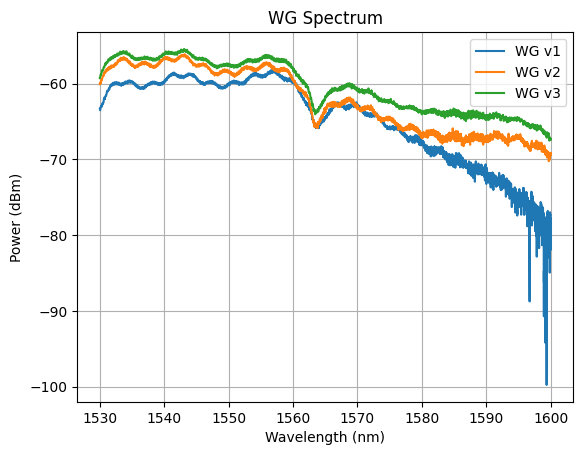

In [5]:
plt.plot(wavelength_wg_v1, power_wg_v1, label='WG v1')
plt.plot(wavelength_wg_v2, power_wg_v2, label='WG v2')
plt.plot(wavelength_wg_v3, power_wg_v3, label='WG v3')

plt.xlabel('Wavelength (nm)')   
plt.ylabel('Power (dBm)')
plt.title('WG Spectrum')
plt.legend()
plt.grid()
plt.show()

## MZI ΔL = 0 um

In [6]:
# Common variables
dL = 0.0

### Fitting

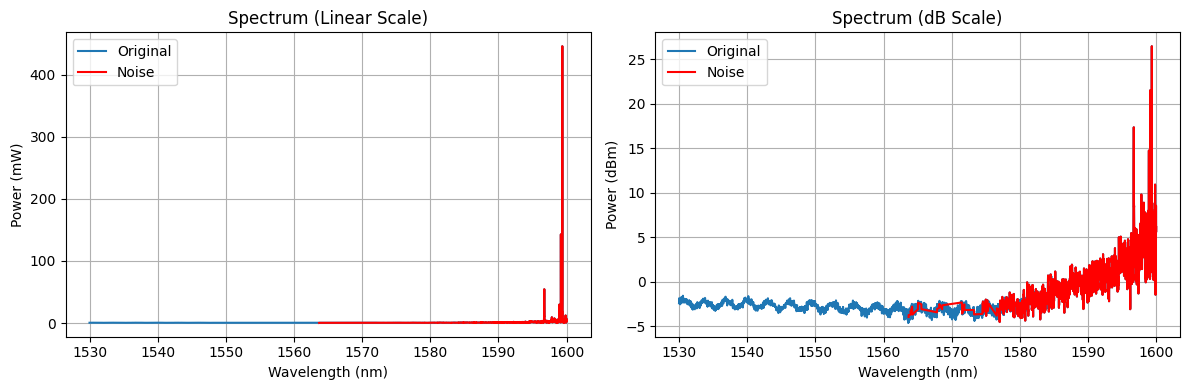

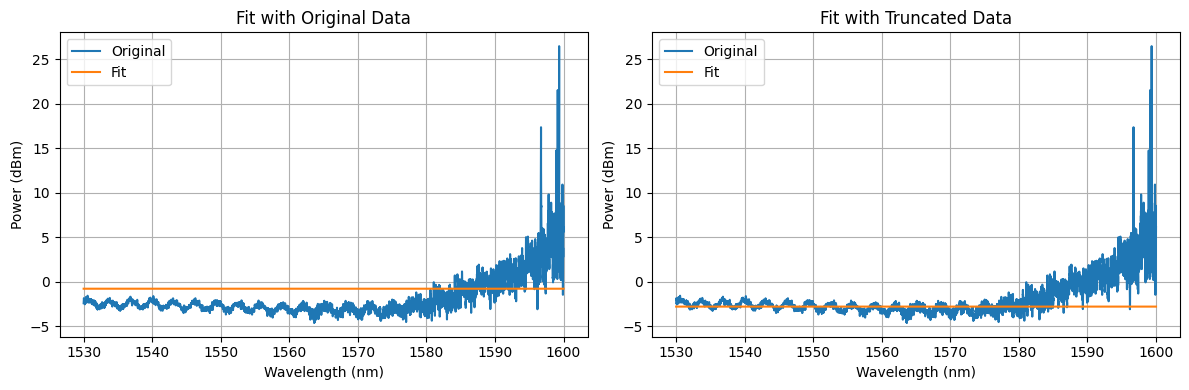

In [7]:
## Output port 1, v1
threshold_dB = 20
wavelength_mzi1_11_v1_filter, power_mzi1_11_v1_filter, wavelength_noise, power_noise = surpress_noise(wavelength_mzi1_11_v1, power_mzi1_11_v1, window_size = 0.1, threshold_dB = threshold_dB, plot=True)

power_mzi1_11_v1_fit, popt_mzi1_11_v1 = cosine_fit(wavelength_mzi1_11_v1, power_mzi1_11_v1, dL)
power_mzi1_11_v1_fit_2, popt_mzi1_11_v1_2 = cosine_fit(wavelength_mzi1_11_v1_filter, power_mzi1_11_v1_filter, dL, wavelength_out = wavelength_mzi1_11_v1)

fig, ax = plt.subplots(1,2, figsize=(12, 4))

ax[0].plot(wavelength_mzi1_11_v1, power_mzi1_11_v1, label = 'Original')
ax[0].plot(wavelength_mzi1_11_v1, power_mzi1_11_v1_fit, label='Fit')

ax[1].plot(wavelength_mzi1_11_v1, power_mzi1_11_v1, label = 'Original')
ax[1].plot(wavelength_mzi1_11_v1, power_mzi1_11_v1_fit_2, label='Fit')

ax[0].set_xlabel('Wavelength (nm)')   
ax[0].set_ylabel('Power (dBm)')
ax[0].set_title('Fit with Original Data')
ax[0].legend()
ax[0].grid()

ax[1].set_xlabel('Wavelength (nm)')   
ax[1].set_ylabel('Power (dBm)')
ax[1].set_title('Fit with Truncated Data')
ax[1].legend()
ax[1].grid()

plt.tight_layout()
plt.show()

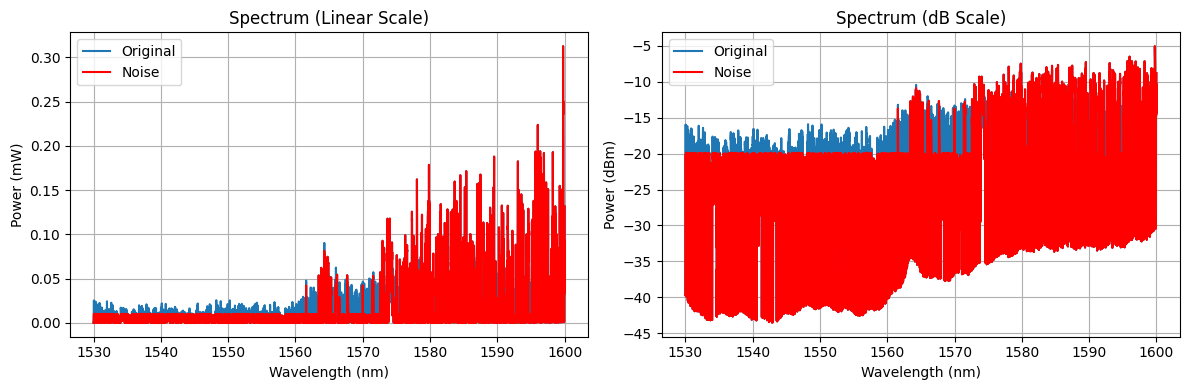

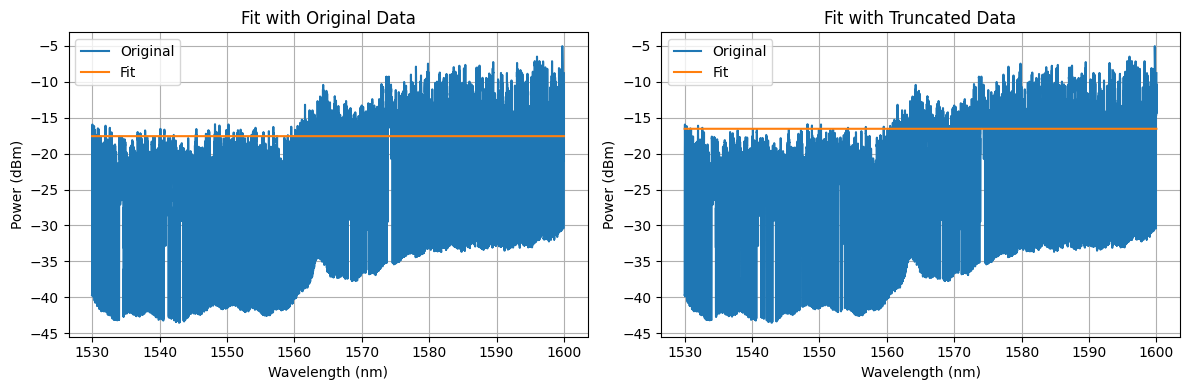

In [8]:
## Output port 1, v2
threshold_dB = 20
wavelength_mzi1_11_v2_filter, power_mzi1_11_v2_filter, wavelength_noise, power_noise = surpress_noise(wavelength_mzi1_11_v2, power_mzi1_11_v2, window_size = 0.1, threshold_dB = threshold_dB, plot=True)

power_mzi1_11_v2_fit, popt_mzi1_11_v2 = cosine_fit(wavelength_mzi1_11_v2, power_mzi1_11_v2, dL)
power_mzi1_11_v2_fit_2, popt_mzi1_11_v2_2 = cosine_fit(wavelength_mzi1_11_v2_filter, power_mzi1_11_v2_filter, dL, wavelength_out = wavelength_mzi1_11_v2)

fig, ax = plt.subplots(1,2, figsize=(12, 4))

ax[0].plot(wavelength_mzi1_11_v2, power_mzi1_11_v2, label = 'Original')
ax[0].plot(wavelength_mzi1_11_v2, power_mzi1_11_v2_fit, label='Fit')

ax[1].plot(wavelength_mzi1_11_v2, power_mzi1_11_v2, label = 'Original')
ax[1].plot(wavelength_mzi1_11_v2, power_mzi1_11_v2_fit_2, label='Fit')

ax[0].set_xlabel('Wavelength (nm)')   
ax[0].set_ylabel('Power (dBm)')
ax[0].set_title('Fit with Original Data')
ax[0].legend()
ax[0].grid()

ax[1].set_xlabel('Wavelength (nm)')   
ax[1].set_ylabel('Power (dBm)')
ax[1].set_title('Fit with Truncated Data')
ax[1].legend()
ax[1].grid()

plt.tight_layout()
plt.show()

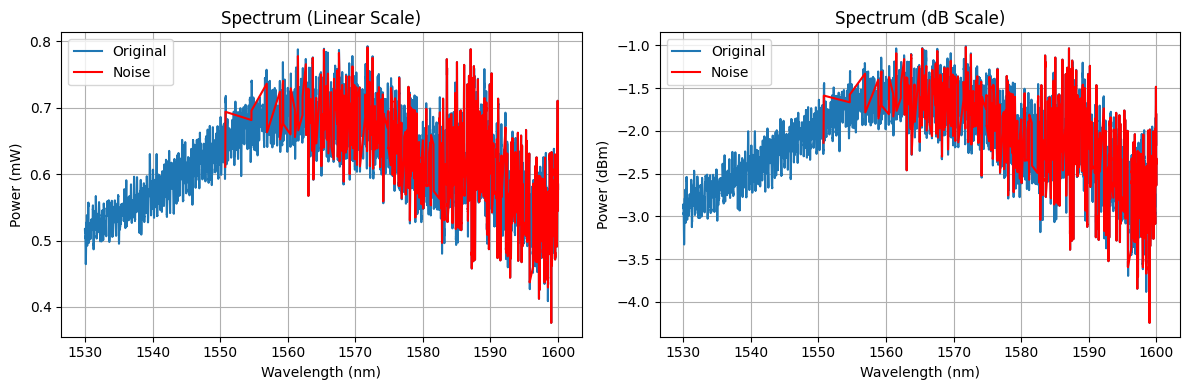

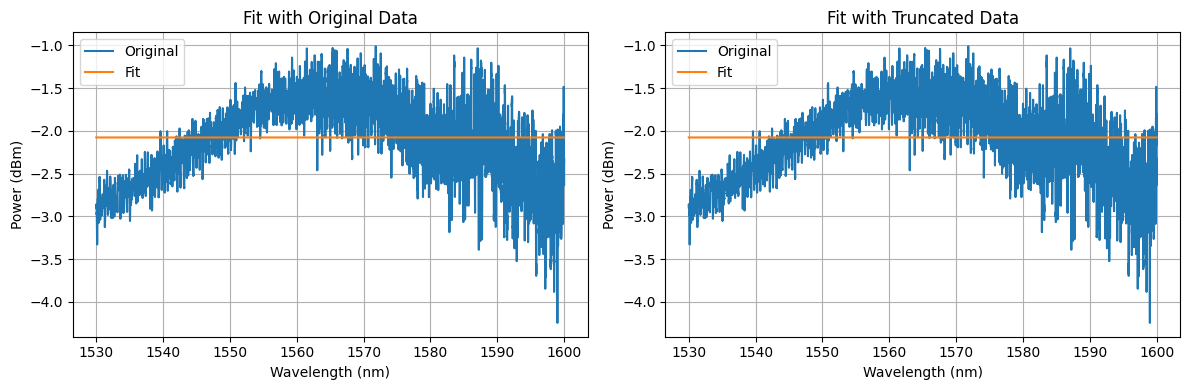

In [9]:
## Output port 1, v3
threshold_dB = 20
wavelength_mzi1_11_v3_filter, power_mzi1_11_v3_filter, wavelength_noise, power_noise = surpress_noise(wavelength_mzi1_11_v3, power_mzi1_11_v3, window_size = 0.1, threshold_dB = threshold_dB, plot=True)

power_mzi1_11_v3_fit, popt_mzi1_11_v3 = cosine_fit(wavelength_mzi1_11_v3, power_mzi1_11_v3, dL)
power_mzi1_11_v3_fit_2, popt_mzi1_11_v3_2 = cosine_fit(wavelength_mzi1_11_v3_filter, power_mzi1_11_v3_filter, dL, wavelength_out = wavelength_mzi1_11_v3)

fig, ax = plt.subplots(1,2, figsize=(12, 4))

ax[0].plot(wavelength_mzi1_11_v3, power_mzi1_11_v3, label = 'Original')
ax[0].plot(wavelength_mzi1_11_v3, power_mzi1_11_v3_fit, label='Fit')

ax[1].plot(wavelength_mzi1_11_v3, power_mzi1_11_v3, label = 'Original')
ax[1].plot(wavelength_mzi1_11_v3, power_mzi1_11_v3_fit_2, label='Fit')

ax[0].set_xlabel('Wavelength (nm)')   
ax[0].set_ylabel('Power (dBm)')
ax[0].set_title('Fit with Original Data')
ax[0].legend()
ax[0].grid()

ax[1].set_xlabel('Wavelength (nm)')   
ax[1].set_ylabel('Power (dBm)')
ax[1].set_title('Fit with Truncated Data')
ax[1].legend()
ax[1].grid()

plt.tight_layout()
plt.show()

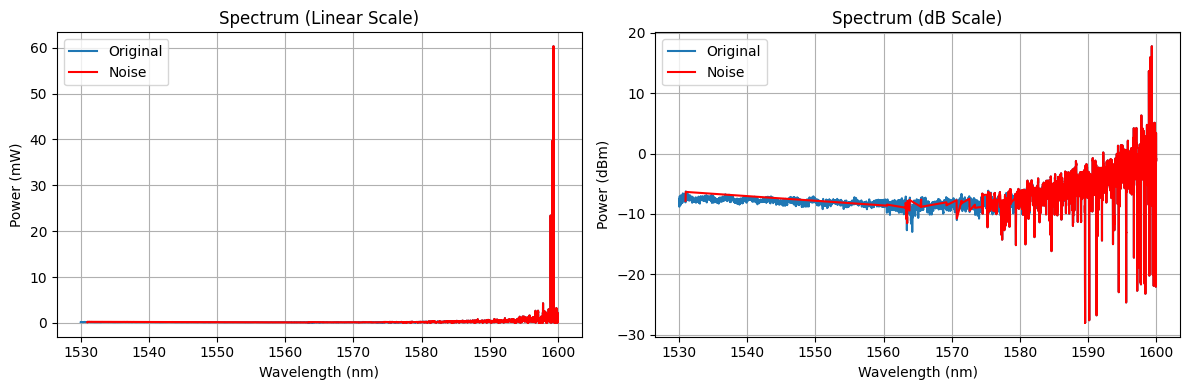

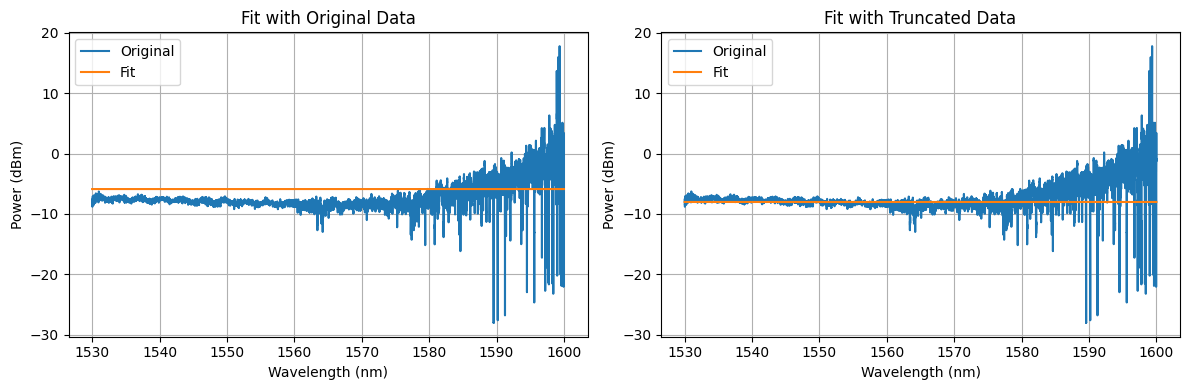

In [10]:
## Output port 2, v1
threshold_dB = 20
wavelength_mzi1_12_v1_filter, power_mzi1_12_v1_filter, wavelength_noise, power_noise = surpress_noise(wavelength_mzi1_12_v1, power_mzi1_12_v1, window_size = 0.1, threshold_dB = threshold_dB, plot=True)

power_mzi1_12_v1_fit, popt_mzi1_12_v1 = cosine_fit(wavelength_mzi1_12_v1, power_mzi1_12_v1, dL)
power_mzi1_12_v1_fit_2, popt_mzi1_12_v1_2 = cosine_fit(wavelength_mzi1_12_v1_filter, power_mzi1_12_v1_filter, dL, wavelength_out = wavelength_mzi1_12_v1)

fig, ax = plt.subplots(1,2, figsize=(12, 4))

ax[0].plot(wavelength_mzi1_12_v1, power_mzi1_12_v1, label = 'Original')
ax[0].plot(wavelength_mzi1_12_v1, power_mzi1_12_v1_fit, label='Fit')

ax[1].plot(wavelength_mzi1_12_v1, power_mzi1_12_v1, label = 'Original')
ax[1].plot(wavelength_mzi1_12_v1, power_mzi1_12_v1_fit_2, label='Fit')

ax[0].set_xlabel('Wavelength (nm)')   
ax[0].set_ylabel('Power (dBm)')
ax[0].set_title('Fit with Original Data')
ax[0].legend()
ax[0].grid()

ax[1].set_xlabel('Wavelength (nm)')   
ax[1].set_ylabel('Power (dBm)')
ax[1].set_title('Fit with Truncated Data')
ax[1].legend()
ax[1].grid()

plt.tight_layout()
plt.show()

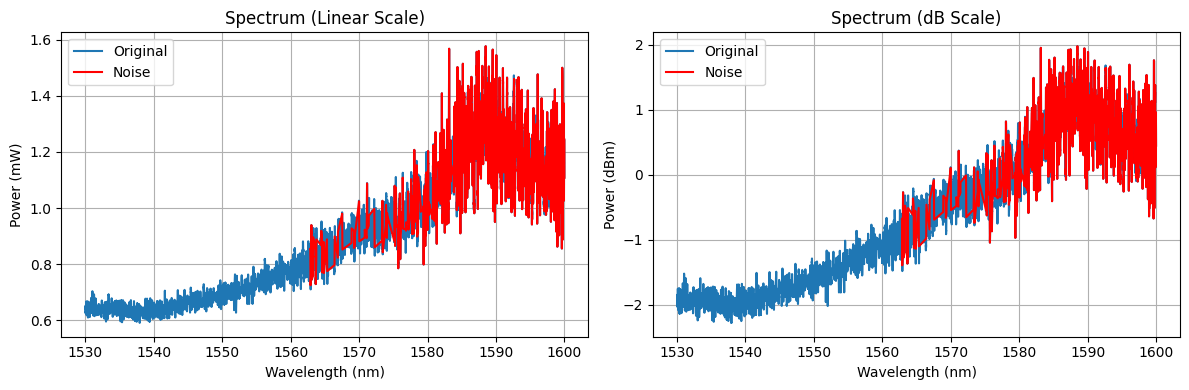

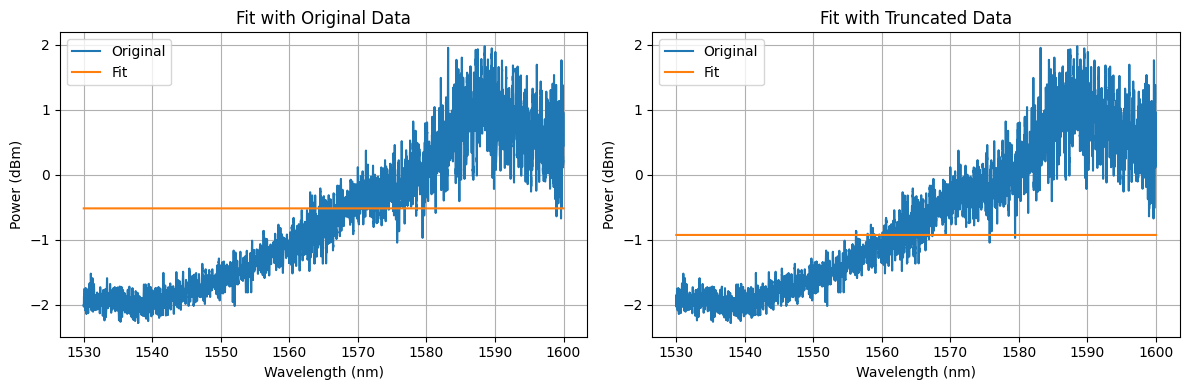

In [11]:
## Output port 2, v2
threshold_dB = 20
wavelength_mzi1_12_v2_filter, power_mzi1_12_v2_filter, wavelength_noise, power_noise = surpress_noise(wavelength_mzi1_12_v2, power_mzi1_12_v2, window_size = 0.1, threshold_dB = threshold_dB, plot=True)

power_mzi1_12_v2_fit, popt_mzi1_12_v2 = cosine_fit(wavelength_mzi1_12_v2, power_mzi1_12_v2, dL)
power_mzi1_12_v2_fit_2, popt_mzi1_12_v2_2 = cosine_fit(wavelength_mzi1_12_v2_filter, power_mzi1_12_v2_filter, dL, wavelength_out = wavelength_mzi1_12_v2)

fig, ax = plt.subplots(1,2, figsize=(12, 4))

ax[0].plot(wavelength_mzi1_12_v2, power_mzi1_12_v2, label = 'Original')
ax[0].plot(wavelength_mzi1_12_v2, power_mzi1_12_v2_fit, label='Fit')

ax[1].plot(wavelength_mzi1_12_v2, power_mzi1_12_v2, label = 'Original')
ax[1].plot(wavelength_mzi1_12_v2, power_mzi1_12_v2_fit_2, label='Fit')

ax[0].set_xlabel('Wavelength (nm)')   
ax[0].set_ylabel('Power (dBm)')
ax[0].set_title('Fit with Original Data')
ax[0].legend()
ax[0].grid()

ax[1].set_xlabel('Wavelength (nm)')   
ax[1].set_ylabel('Power (dBm)')
ax[1].set_title('Fit with Truncated Data')
ax[1].legend()
ax[1].grid()

plt.tight_layout()
plt.show()

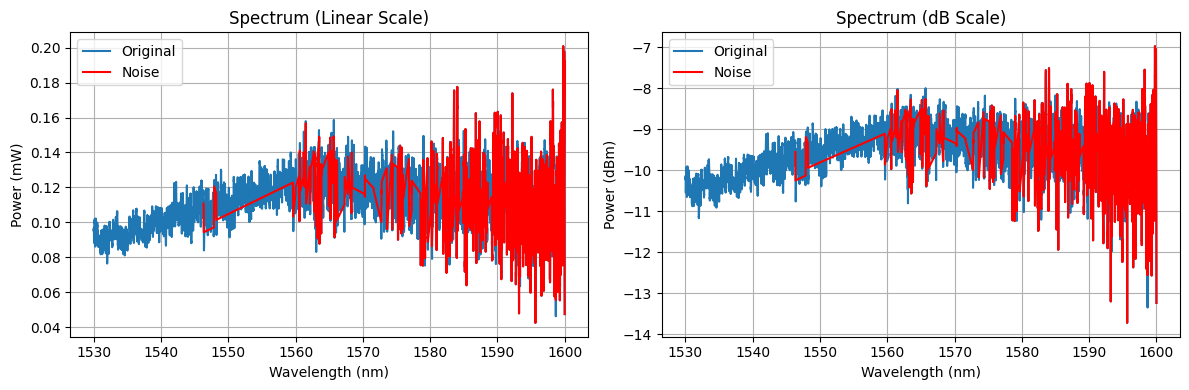

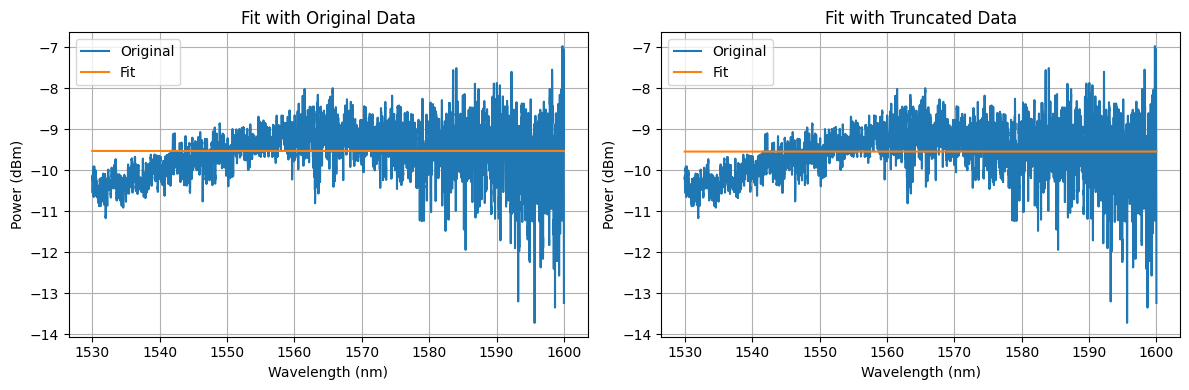

In [12]:
## Output port 2, v3
threshold_dB = 20
wavelength_mzi1_12_v3_filter, power_mzi1_12_v3_filter, wavelength_noise, power_noise = surpress_noise(wavelength_mzi1_12_v3, power_mzi1_12_v3, window_size = 0.1, threshold_dB = threshold_dB, plot=True)

power_mzi1_12_v3_fit, popt_mzi1_12_v3 = cosine_fit(wavelength_mzi1_12_v3, power_mzi1_12_v3, dL)
power_mzi1_12_v3_fit_2, popt_mzi1_12_v3_2 = cosine_fit(wavelength_mzi1_12_v3_filter, power_mzi1_12_v3_filter, dL, wavelength_out = wavelength_mzi1_12_v3)

fig, ax = plt.subplots(1,2, figsize=(12, 4))

ax[0].plot(wavelength_mzi1_12_v3, power_mzi1_12_v3, label = 'Original')
ax[0].plot(wavelength_mzi1_12_v3, power_mzi1_12_v3_fit, label='Fit')

ax[1].plot(wavelength_mzi1_12_v3, power_mzi1_12_v3, label = 'Original')
ax[1].plot(wavelength_mzi1_12_v3, power_mzi1_12_v3_fit_2, label='Fit')

ax[0].set_xlabel('Wavelength (nm)')   
ax[0].set_ylabel('Power (dBm)')
ax[0].set_title('Fit with Original Data')
ax[0].legend()
ax[0].grid()

ax[1].set_xlabel('Wavelength (nm)')   
ax[1].set_ylabel('Power (dBm)')
ax[1].set_title('Fit with Truncated Data')
ax[1].legend()
ax[1].grid()

plt.tight_layout()
plt.show()

### Absolute Dephase

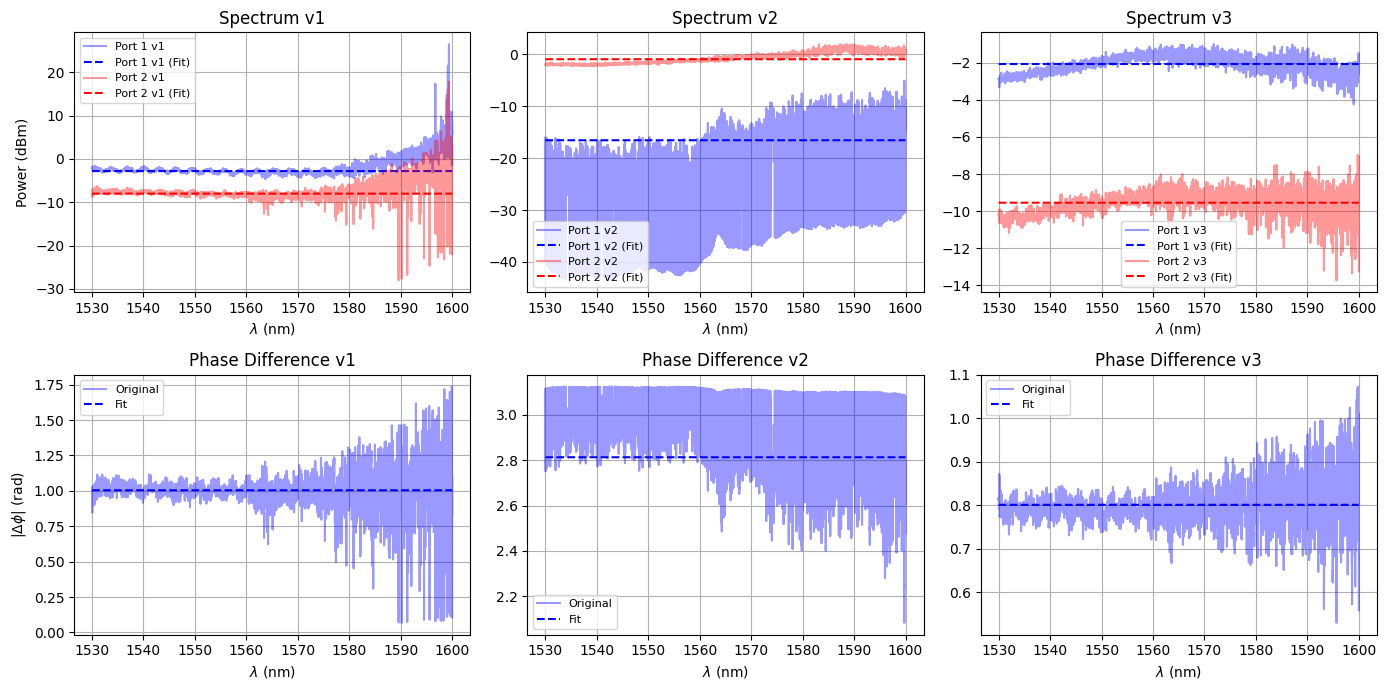

In [13]:
fig, axs = plt.subplots(2, 3, figsize=(14, 7))

axs[0, 0].plot(wavelength_mzi1_11_v1, power_mzi1_11_v1, label='Port 1 v1', alpha=0.4, color='blue')
axs[0, 0].plot(wavelength_mzi1_11_v1, power_mzi1_11_v1_fit_2, label='Port 1 v1 (Fit)', color='blue', linestyle='--')
axs[0, 0].plot(wavelength_mzi1_12_v1, power_mzi1_12_v1, label='Port 2 v1', alpha=0.4, color='red')
axs[0, 0].plot(wavelength_mzi1_12_v1, power_mzi1_12_v1_fit_2, label='Port 2 v1 (Fit)', color='red', linestyle='--')
axs[0, 0].set_title('Spectrum v1')
axs[0, 0].set_xlabel(r'$\lambda$ (nm)')
axs[0, 0].set_ylabel('Power (dBm)')
axs[0, 0].grid()
axs[0, 0].legend(fontsize=8)

axs[0, 1].plot(wavelength_mzi1_11_v2, power_mzi1_11_v2, label='Port 1 v2', alpha=0.4, color='blue')
axs[0, 1].plot(wavelength_mzi1_11_v2, power_mzi1_11_v2_fit_2, label='Port 1 v2 (Fit)', color='blue', linestyle='--')
axs[0, 1].plot(wavelength_mzi1_12_v2, power_mzi1_12_v2, label='Port 2 v2', alpha=0.4, color='red')
axs[0, 1].plot(wavelength_mzi1_12_v2, power_mzi1_12_v2_fit_2, label='Port 2 v2 (Fit)', color='red', linestyle='--')
axs[0, 1].set_title('Spectrum v2')
axs[0, 1].set_xlabel(r'$\lambda$ (nm)')
axs[0, 1].grid()
axs[0, 1].legend(fontsize=8)

axs[0, 2].plot(wavelength_mzi1_11_v3, power_mzi1_11_v3, label='Port 1 v3', alpha=0.4, color='blue')
axs[0, 2].plot(wavelength_mzi1_11_v3, power_mzi1_11_v3_fit_2, label='Port 1 v3 (Fit)', color='blue', linestyle='--')
axs[0, 2].plot(wavelength_mzi1_12_v3, power_mzi1_12_v3, label='Port 2 v3', alpha=0.4, color='red')
axs[0, 2].plot(wavelength_mzi1_12_v3, power_mzi1_12_v3_fit_2, label='Port 2 v3 (Fit)', color='red', linestyle='--')
axs[0, 2].set_title('Spectrum v3')
axs[0, 2].set_xlabel(r'$\lambda$ (nm)')
axs[0, 2].grid()
axs[0, 2].legend(fontsize=8)

delta_phi_v1 = ideal_dephase(wavelength_mzi1_11_v1, power_mzi1_11_v1, power_mzi1_12_v1)
delta_phi_v2 = ideal_dephase(wavelength_mzi1_11_v2, power_mzi1_11_v2, power_mzi1_12_v2)
delta_phi_v3 = ideal_dephase(wavelength_mzi1_11_v3, power_mzi1_11_v3, power_mzi1_12_v3)

delta_phi_v1_fit = ideal_dephase(wavelength_mzi1_11_v1, power_mzi1_11_v1_fit_2, power_mzi1_12_v1_fit_2)
delta_phi_v2_fit = ideal_dephase(wavelength_mzi1_11_v2, power_mzi1_11_v2_fit_2, power_mzi1_12_v2_fit_2)
delta_phi_v3_fit = ideal_dephase(wavelength_mzi1_11_v3, power_mzi1_11_v3_fit_2, power_mzi1_12_v3_fit_2)

axs[1, 0].plot(wavelength_mzi1_11_v1, delta_phi_v1, label='Original', alpha=0.4, color='blue')
axs[1, 0].plot(wavelength_mzi1_11_v1, delta_phi_v1_fit, label='Fit', color='blue', linestyle='--')
axs[1, 0].set_title('Phase Difference v1')
axs[1, 0].set_xlabel(r'$\lambda$ (nm)')
axs[1, 0].set_ylabel(r'$|\Delta \phi|$ (rad)')
axs[1, 0].legend(fontsize=8)
axs[1, 0].grid()

axs[1, 1].plot(wavelength_mzi1_11_v2, delta_phi_v2, label='Original', alpha=0.4, color='blue')
axs[1, 1].plot(wavelength_mzi1_11_v2, delta_phi_v2_fit, label='Fit', color='blue', linestyle='--')
axs[1, 1].set_title('Phase Difference v2')
axs[1, 1].set_xlabel(r'$\lambda$ (nm)')
axs[1, 1].legend(fontsize=8)
axs[1, 1].grid()

axs[1, 2].plot(wavelength_mzi1_11_v3, delta_phi_v3, label='Original', alpha=0.4, color='blue')
axs[1, 2].plot(wavelength_mzi1_11_v3, delta_phi_v3_fit, label='Fit', color='blue', linestyle='--')
axs[1, 2].set_title('Phase Difference v3')
axs[1, 2].set_xlabel(r'$\lambda$ (nm)')
axs[1, 2].legend(fontsize=8)
axs[1, 2].grid()

#plt.suptitle(r'MZI: $\Delta L = 0$ um', fontsize=14)
plt.tight_layout()
plt.show()

## MZI ΔL = 10 um

In [136]:
# Common variables
dL = 10e-6

### Fitting

In [137]:
## Output port 1, v1
threshold_dB = np.inf
wavelength_mzi2_11_v1_filter, power_mzi2_11_v1_filter, wavelength_noise, power_noise = surpress_noise(wavelength_mzi2_11_v1, power_mzi2_11_v1, window_size = 0.1, threshold_dB = threshold_dB, plot=True)

power_mzi2_11_v1_fit, popt_mzi2_11_v1 = cosine_fit(wavelength_mzi2_11_v1, power_mzi2_11_v1, dL)
power_mzi2_11_v1_fit_2, popt_mzi2_11_v1_2 = cosine_fit(wavelength_mzi2_11_v1_filter, power_mzi2_11_v1_filter, dL, wavelength_out = wavelength_mzi2_11_v1)

fig, ax = plt.subplots(2,2, figsize=(12, 8))

ax[0, 0].plot(wavelength_mzi2_11_v1, power_mzi2_11_v1, label = 'Original')
ax[0, 0].plot(wavelength_mzi2_11_v1, power_mzi2_11_v1_fit, label='Fit')
ax[0, 0].set_xlabel('Wavelength (nm)')   
ax[0, 0].set_ylabel('Power (dBm)')
ax[0, 0].set_title('Fit with Original Data (dB Scale)')
ax[0, 0].legend()
ax[0, 0].grid()

ax[0, 1].plot(wavelength_mzi2_11_v1, 10**(power_mzi2_11_v1/10), label = 'Original')
ax[0, 1].plot(wavelength_mzi2_11_v1, 10**(power_mzi2_11_v1_fit/10), label='Fit')
ax[0, 1].set_ylim(0, 1)
ax[0, 1].set_xlabel('Wavelength (nm)')   
ax[0, 1].set_ylabel('Power (mW)')
ax[0, 1].set_title('Fit with Original Data (Linear Scale)')
ax[0, 1].legend()
ax[0, 1].grid()

ax[1, 0].plot(wavelength_mzi2_11_v1, power_mzi2_11_v1, label = 'Original')
ax[1, 0].plot(wavelength_mzi2_11_v1, power_mzi2_11_v1_fit_2, label='Fit')
ax[1, 0].set_xlabel('Wavelength (nm)')   
ax[1, 0].set_ylabel('Power (dBm)')
ax[1, 0].set_title('Fit with Truncated Data (dB Scale)')
ax[1, 0].legend()
ax[1, 0].grid()

ax[1, 1].plot(wavelength_mzi2_11_v1, 10**(power_mzi2_11_v1/10), label = 'Original')
ax[1, 1].plot(wavelength_mzi2_11_v1, 10**(power_mzi2_11_v1_fit_2/10), label='Fit')
ax[1, 1].set_ylim(0, 1)
ax[1, 1].set_xlabel('Wavelength (nm)')   
ax[1, 1].set_ylabel('Power (mW)')
ax[1, 1].set_title('Fit with Truncated Data (Linear Scale)')
ax[1, 1].legend()
ax[1, 1].grid()

plt.tight_layout()
plt.show()

NameError: name 'wavelength_mzi2_11_v1' is not defined

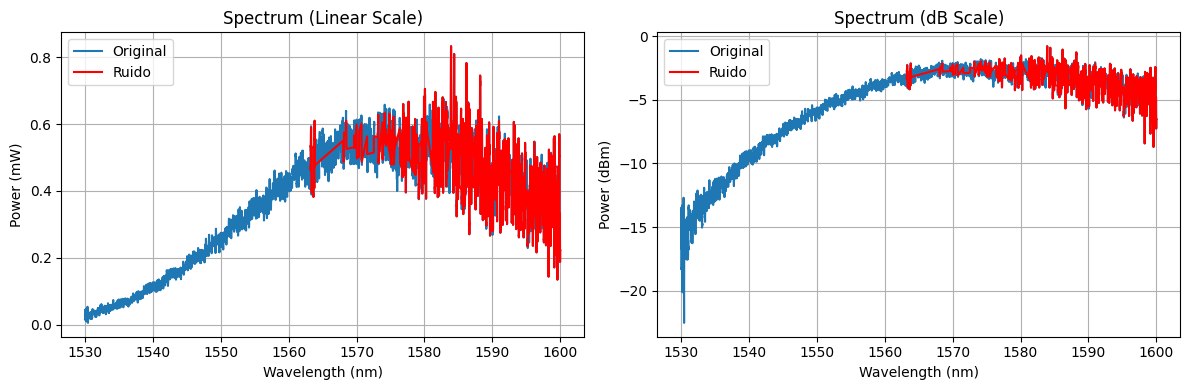

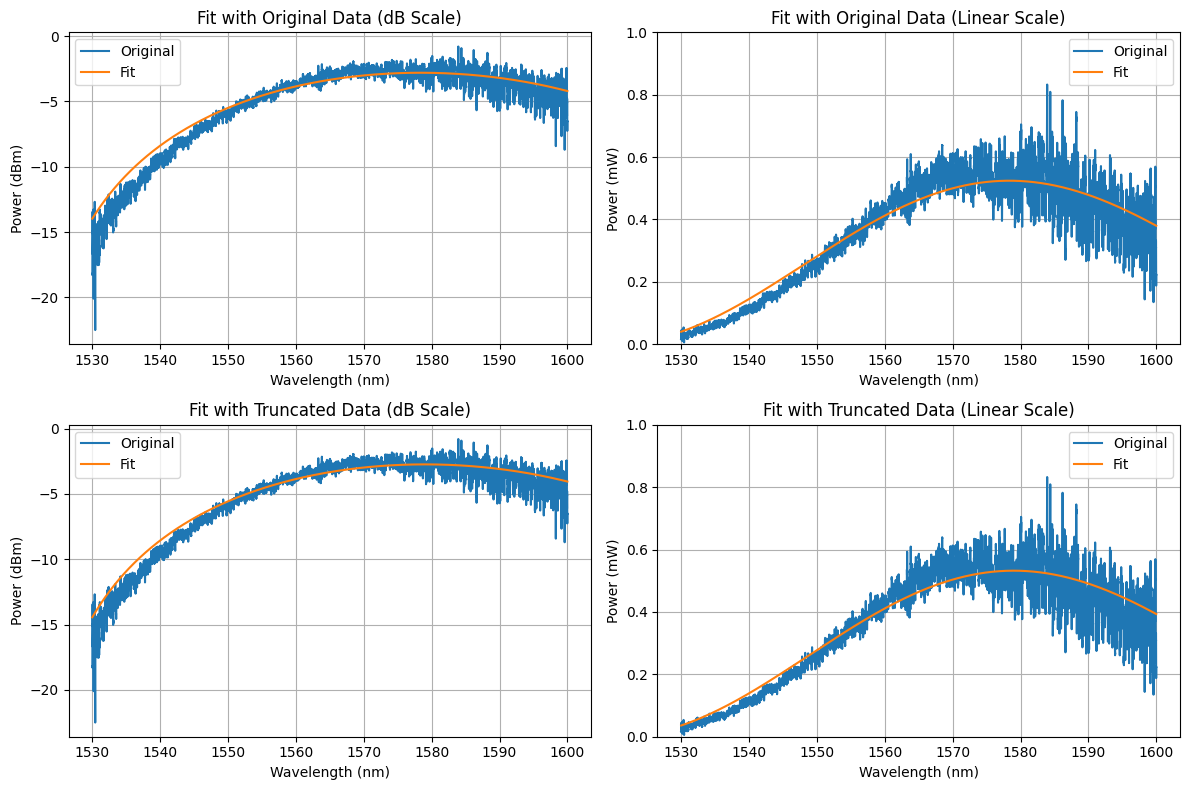

In [ ]:
## Output port 1, v2
threshold_dB = np.inf
wavelength_mzi2_11_v2_filter, power_mzi2_11_v2_filter, wavelength_noise, power_noise = surpress_noise(wavelength_mzi2_11_v2, power_mzi2_11_v2, window_size = 0.1, threshold_dB = threshold_dB, plot=True)

power_mzi2_11_v2_fit, popt_mzi2_11_v2 = cosine_fit(wavelength_mzi2_11_v2, power_mzi2_11_v2, dL)

power_mzi2_11_v2_fit_2, popt_mzi2_11_v2_2 = cosine_fit(wavelength_mzi2_11_v2_filter, power_mzi2_11_v2_filter, dL, wavelength_out = wavelength_mzi2_11_v2)

fig, ax = plt.subplots(2,2, figsize=(12, 8))

ax[0, 0].plot(wavelength_mzi2_11_v2, power_mzi2_11_v2, label = 'Original')
ax[0, 0].plot(wavelength_mzi2_11_v2, power_mzi2_11_v2_fit, label='Fit')
ax[0, 0].set_xlabel('Wavelength (nm)')   
ax[0, 0].set_ylabel('Power (dBm)')
ax[0, 0].set_title('Fit with Original Data (dB Scale)')
ax[0, 0].legend()
ax[0, 0].grid()

ax[0, 1].plot(wavelength_mzi2_11_v2, 10**(power_mzi2_11_v2/10), label = 'Original')
ax[0, 1].plot(wavelength_mzi2_11_v2, 10**(power_mzi2_11_v2_fit/10), label='Fit')
ax[0, 1].set_ylim(0, 1)
ax[0, 1].set_xlabel('Wavelength (nm)')   
ax[0, 1].set_ylabel('Power (mW)')
ax[0, 1].set_title('Fit with Original Data (Linear Scale)')
ax[0, 1].legend()
ax[0, 1].grid()

ax[1, 0].plot(wavelength_mzi2_11_v2, power_mzi2_11_v2, label = 'Original')
ax[1, 0].plot(wavelength_mzi2_11_v2, power_mzi2_11_v2_fit_2, label='Fit')
ax[1, 0].set_xlabel('Wavelength (nm)')   
ax[1, 0].set_ylabel('Power (dBm)')
ax[1, 0].set_title('Fit with Truncated Data (dB Scale)')
ax[1, 0].legend()
ax[1, 0].grid()

ax[1, 1].plot(wavelength_mzi2_11_v2, 10**(power_mzi2_11_v2/10), label = 'Original')
ax[1, 1].plot(wavelength_mzi2_11_v2, 10**(power_mzi2_11_v2_fit_2/10), label='Fit')
ax[1, 1].set_ylim(0, 1)
ax[1, 1].set_xlabel('Wavelength (nm)')   
ax[1, 1].set_ylabel('Power (mW)')
ax[1, 1].set_title('Fit with Truncated Data (Linear Scale)')
ax[1, 1].legend()
ax[1, 1].grid()

plt.tight_layout()
plt.show()

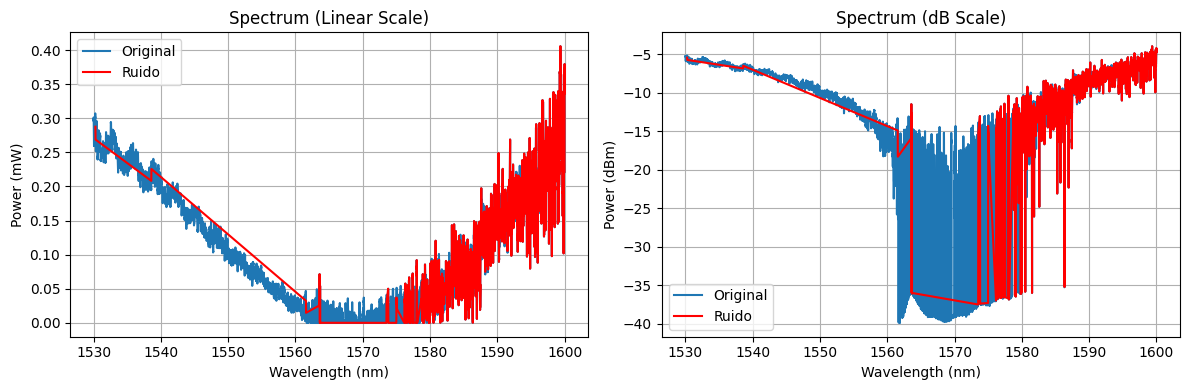

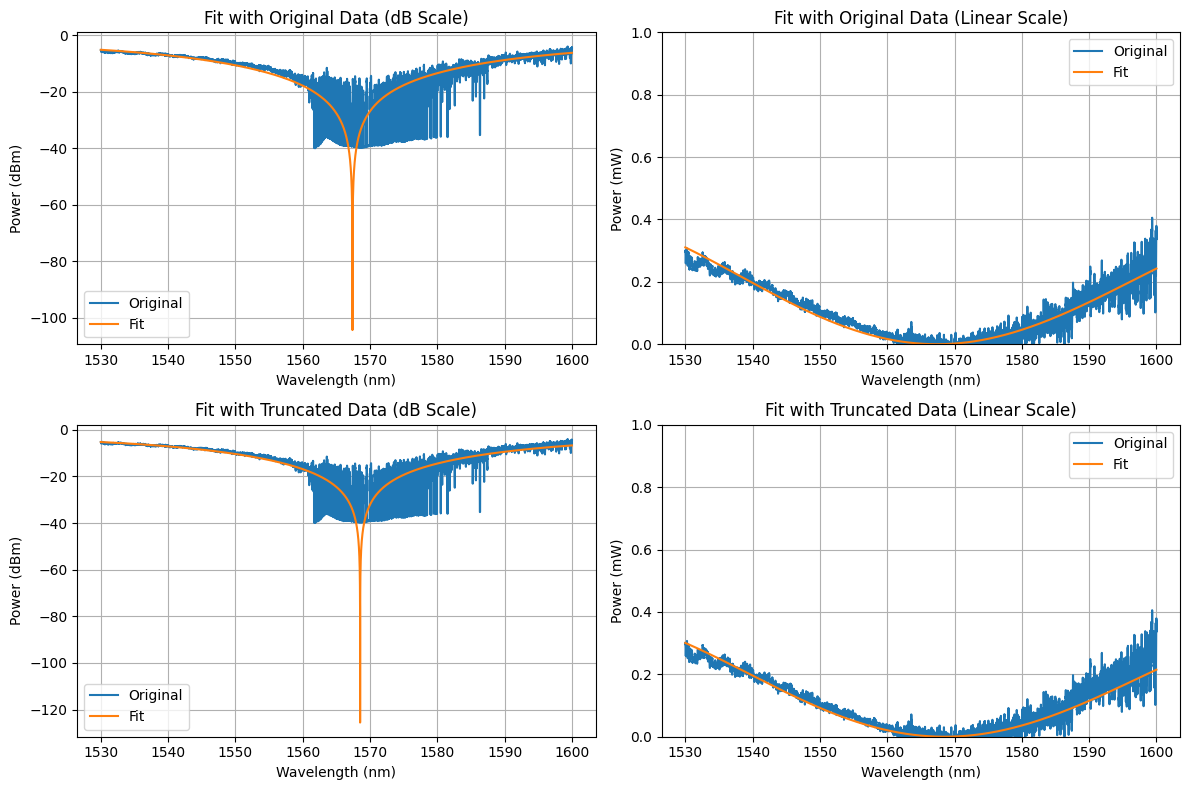

In [ ]:
## Output port 1, v3
threshold_dB = np.inf
wavelength_mzi2_11_v3_filter, power_mzi2_11_v3_filter, wavelength_noise, power_noise = surpress_noise(wavelength_mzi2_11_v3, power_mzi2_11_v3, window_size = 0.1, threshold_dB = threshold_dB, plot=True)

power_mzi2_11_v3_fit, popt_mzi2_11_v3 = cosine_fit(wavelength_mzi2_11_v3, power_mzi2_11_v3, dL)
power_mzi2_11_v3_fit_2, popt_mzi2_11_v3_2 = cosine_fit(wavelength_mzi2_11_v3_filter, power_mzi2_11_v3_filter, dL, wavelength_out = wavelength_mzi2_11_v3)

fig, ax = plt.subplots(2,2, figsize=(12, 8))

ax[0, 0].plot(wavelength_mzi2_11_v3, power_mzi2_11_v3, label = 'Original')
ax[0, 0].plot(wavelength_mzi2_11_v3, power_mzi2_11_v3_fit, label='Fit')
ax[0, 0].set_xlabel('Wavelength (nm)')   
ax[0, 0].set_ylabel('Power (dBm)')
ax[0, 0].set_title('Fit with Original Data (dB Scale)')
ax[0, 0].legend()
ax[0, 0].grid()

ax[0, 1].plot(wavelength_mzi2_11_v3, 10**(power_mzi2_11_v3/10), label = 'Original')
ax[0, 1].plot(wavelength_mzi2_11_v3, 10**(power_mzi2_11_v3_fit/10), label='Fit')
ax[0, 1].set_ylim(0, 1)
ax[0, 1].set_xlabel('Wavelength (nm)')   
ax[0, 1].set_ylabel('Power (mW)')
ax[0, 1].set_title('Fit with Original Data (Linear Scale)')
ax[0, 1].legend()
ax[0, 1].grid()

ax[1, 0].plot(wavelength_mzi2_11_v3, power_mzi2_11_v3, label = 'Original')
ax[1, 0].plot(wavelength_mzi2_11_v3, power_mzi2_11_v3_fit_2, label='Fit')
ax[1, 0].set_xlabel('Wavelength (nm)')   
ax[1, 0].set_ylabel('Power (dBm)')
ax[1, 0].set_title('Fit with Truncated Data (dB Scale)')
ax[1, 0].legend()
ax[1, 0].grid()

ax[1, 1].plot(wavelength_mzi2_11_v3, 10**(power_mzi2_11_v3/10), label = 'Original')
ax[1, 1].plot(wavelength_mzi2_11_v3, 10**(power_mzi2_11_v3_fit_2/10), label='Fit')
ax[1, 1].set_ylim(0, 1)
ax[1, 1].set_xlabel('Wavelength (nm)')   
ax[1, 1].set_ylabel('Power (mW)')
ax[1, 1].set_title('Fit with Truncated Data (Linear Scale)')
ax[1, 1].legend()
ax[1, 1].grid()

plt.tight_layout()
plt.show()

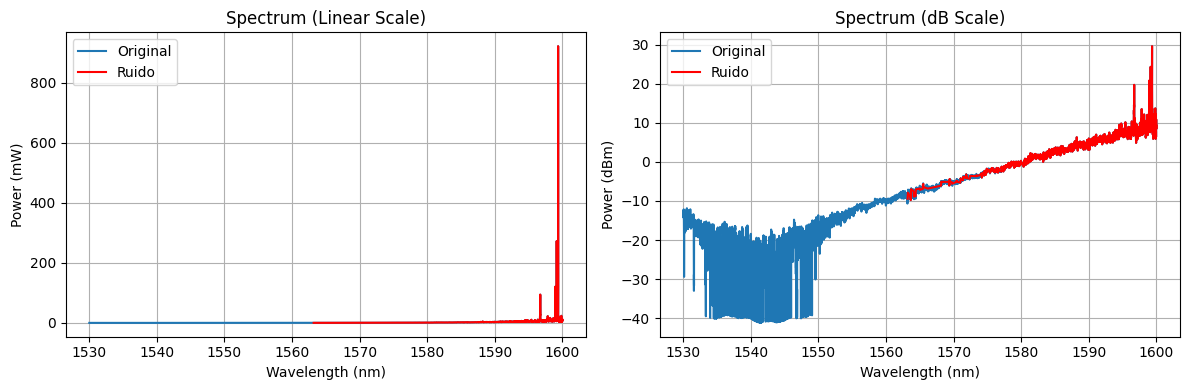

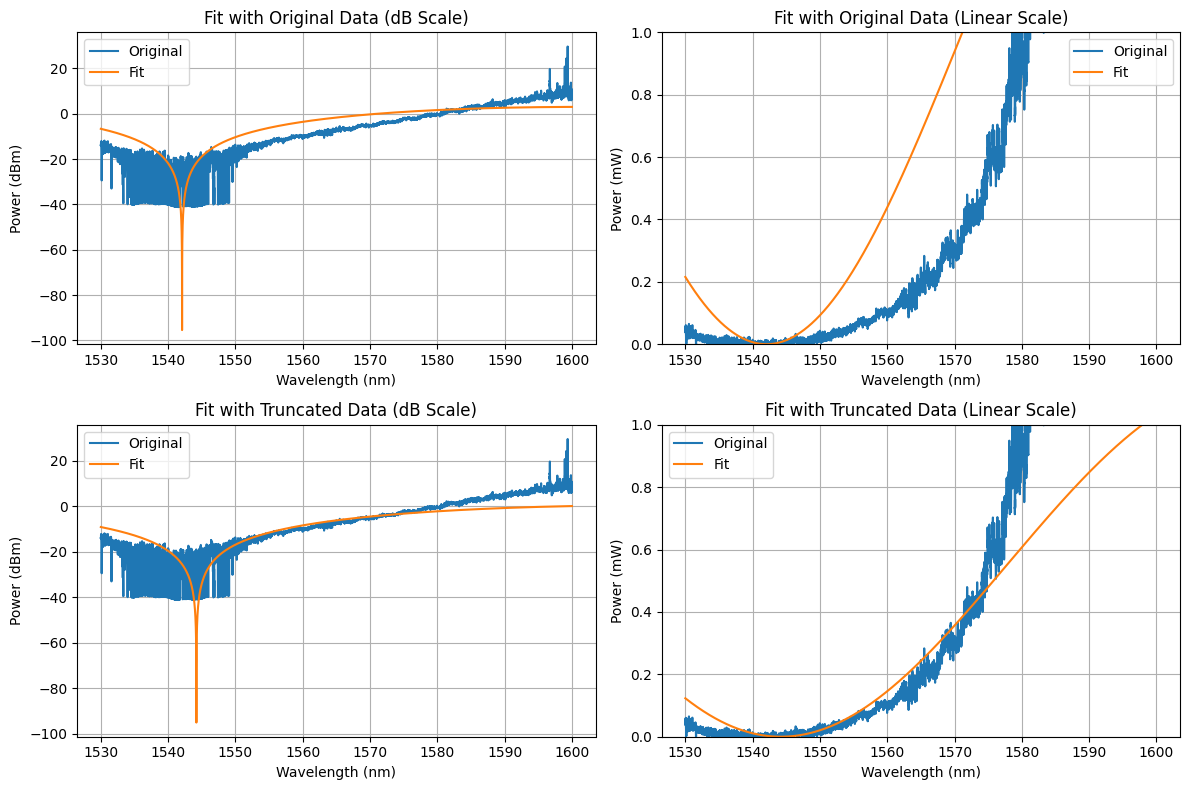

In [ ]:
## Output port 2, v1
threshold_dB = np.inf
wavelength_mzi2_12_v1_filter, power_mzi2_12_v1_filter, wavelength_noise, power_noise = surpress_noise(wavelength_mzi2_12_v1, power_mzi2_12_v1, window_size = 0.1, threshold_dB = threshold_dB, plot=True)

power_mzi2_12_v1_fit, popt_mzi2_12_v1 = cosine_fit(wavelength_mzi2_12_v1, power_mzi2_12_v1, dL)
power_mzi2_12_v1_fit_2, popt_mzi2_12_v1_2 = cosine_fit(wavelength_mzi2_12_v1_filter, power_mzi2_12_v1_filter, dL, wavelength_out = wavelength_mzi2_12_v1)

fig, ax = plt.subplots(2,2, figsize=(12, 8))

ax[0, 0].plot(wavelength_mzi2_12_v1, power_mzi2_12_v1, label = 'Original')
ax[0, 0].plot(wavelength_mzi2_12_v1, power_mzi2_12_v1_fit, label='Fit')
ax[0, 0].set_xlabel('Wavelength (nm)')   
ax[0, 0].set_ylabel('Power (dBm)')
ax[0, 0].set_title('Fit with Original Data (dB Scale)')
ax[0, 0].legend()
ax[0, 0].grid()

ax[0, 1].plot(wavelength_mzi2_12_v1, 10**(power_mzi2_12_v1/10), label = 'Original')
ax[0, 1].plot(wavelength_mzi2_12_v1, 10**(power_mzi2_12_v1_fit/10), label='Fit')
ax[0, 1].set_ylim(0, 1)
ax[0, 1].set_xlabel('Wavelength (nm)')   
ax[0, 1].set_ylabel('Power (mW)')
ax[0, 1].set_title('Fit with Original Data (Linear Scale)')
ax[0, 1].legend()
ax[0, 1].grid()

ax[1, 0].plot(wavelength_mzi2_12_v1, power_mzi2_12_v1, label = 'Original')
ax[1, 0].plot(wavelength_mzi2_12_v1, power_mzi2_12_v1_fit_2, label='Fit')
ax[1, 0].set_xlabel('Wavelength (nm)')   
ax[1, 0].set_ylabel('Power (dBm)')
ax[1, 0].set_title('Fit with Truncated Data (dB Scale)')
ax[1, 0].legend()
ax[1, 0].grid()

ax[1, 1].plot(wavelength_mzi2_12_v1, 10**(power_mzi2_12_v1/10), label = 'Original')
ax[1, 1].plot(wavelength_mzi2_12_v1, 10**(power_mzi2_12_v1_fit_2/10), label='Fit')
ax[1, 1].set_ylim(0, 1)
ax[1, 1].set_xlabel('Wavelength (nm)')   
ax[1, 1].set_ylabel('Power (mW)')
ax[1, 1].set_title('Fit with Truncated Data (Linear Scale)')
ax[1, 1].legend()
ax[1, 1].grid()

plt.tight_layout()
plt.show()

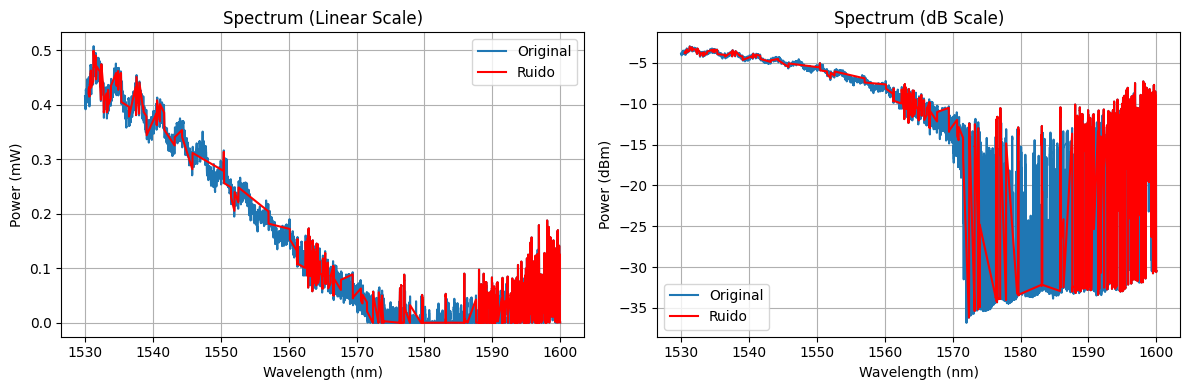

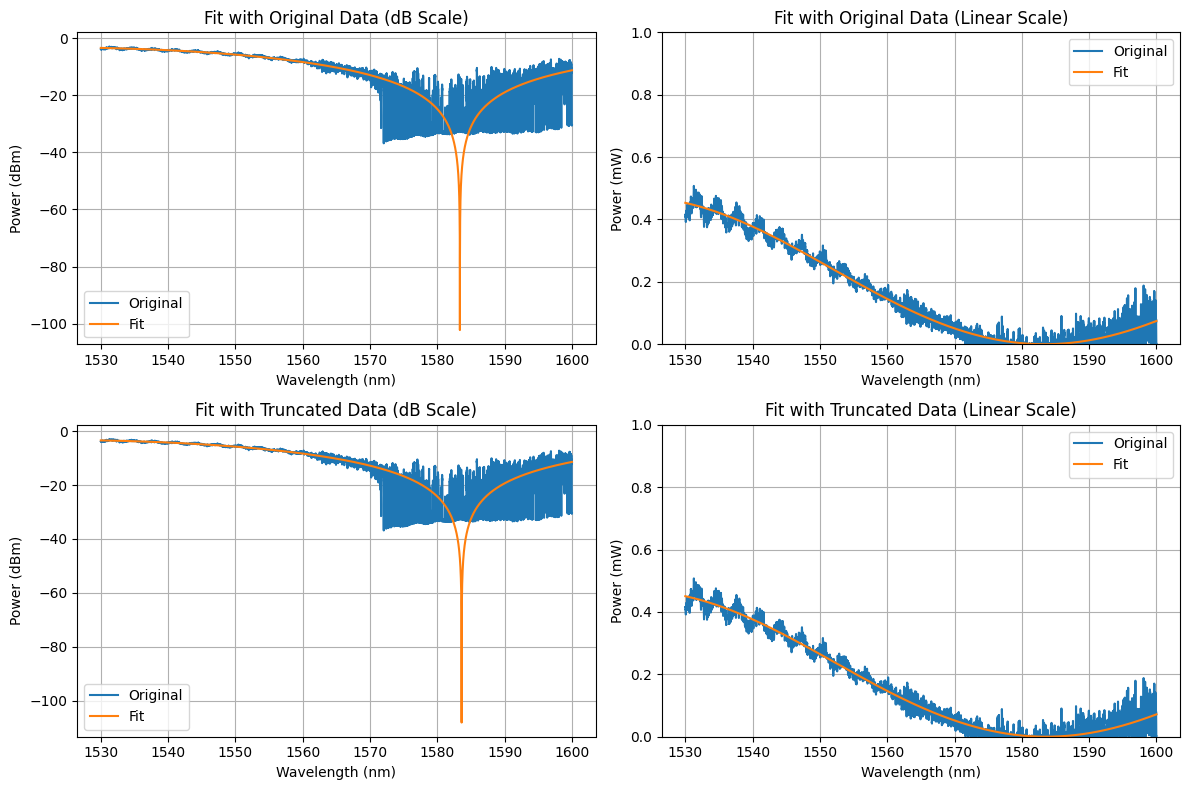

In [ ]:
## Output port 2, v2
threshold_dB = np.inf
wavelength_mzi2_12_v2_filter, power_mzi2_12_v2_filter, wavelength_noise, power_noise = surpress_noise(wavelength_mzi2_12_v2, power_mzi2_12_v2, window_size = 0.1, threshold_dB = threshold_dB, plot=True)

power_mzi2_12_v2_fit, popt_mzi2_12_v2 = cosine_fit(wavelength_mzi2_12_v2, power_mzi2_12_v2, dL)
power_mzi2_12_v2_fit_2, popt_mzi2_12_v2_2 = cosine_fit(wavelength_mzi2_12_v2_filter, power_mzi2_12_v2_filter, dL, wavelength_out = wavelength_mzi2_12_v2)

fig, ax = plt.subplots(2,2, figsize=(12, 8))

ax[0, 0].plot(wavelength_mzi2_12_v2, power_mzi2_12_v2, label = 'Original')
ax[0, 0].plot(wavelength_mzi2_12_v2, power_mzi2_12_v2_fit, label='Fit')
ax[0, 0].set_xlabel('Wavelength (nm)')   
ax[0, 0].set_ylabel('Power (dBm)')
ax[0, 0].set_title('Fit with Original Data (dB Scale)')
ax[0, 0].legend()
ax[0, 0].grid()

ax[0, 1].plot(wavelength_mzi2_12_v2, 10**(power_mzi2_12_v2/10), label = 'Original')
ax[0, 1].plot(wavelength_mzi2_12_v2, 10**(power_mzi2_12_v2_fit/10), label='Fit')
ax[0, 1].set_ylim(0, 1)
ax[0, 1].set_xlabel('Wavelength (nm)')   
ax[0, 1].set_ylabel('Power (mW)')
ax[0, 1].set_title('Fit with Original Data (Linear Scale)')
ax[0, 1].legend()
ax[0, 1].grid()

ax[1, 0].plot(wavelength_mzi2_12_v2, power_mzi2_12_v2, label = 'Original')
ax[1, 0].plot(wavelength_mzi2_12_v2, power_mzi2_12_v2_fit_2, label='Fit')
ax[1, 0].set_xlabel('Wavelength (nm)')   
ax[1, 0].set_ylabel('Power (dBm)')
ax[1, 0].set_title('Fit with Truncated Data (dB Scale)')
ax[1, 0].legend()
ax[1, 0].grid()

ax[1, 1].plot(wavelength_mzi2_12_v2, 10**(power_mzi2_12_v2/10), label = 'Original')
ax[1, 1].plot(wavelength_mzi2_12_v2, 10**(power_mzi2_12_v2_fit_2/10), label='Fit')
ax[1, 1].set_ylim(0, 1)
ax[1, 1].set_xlabel('Wavelength (nm)')   
ax[1, 1].set_ylabel('Power (mW)')
ax[1, 1].set_title('Fit with Truncated Data (Linear Scale)')
ax[1, 1].legend()
ax[1, 1].grid()

plt.tight_layout()
plt.show()

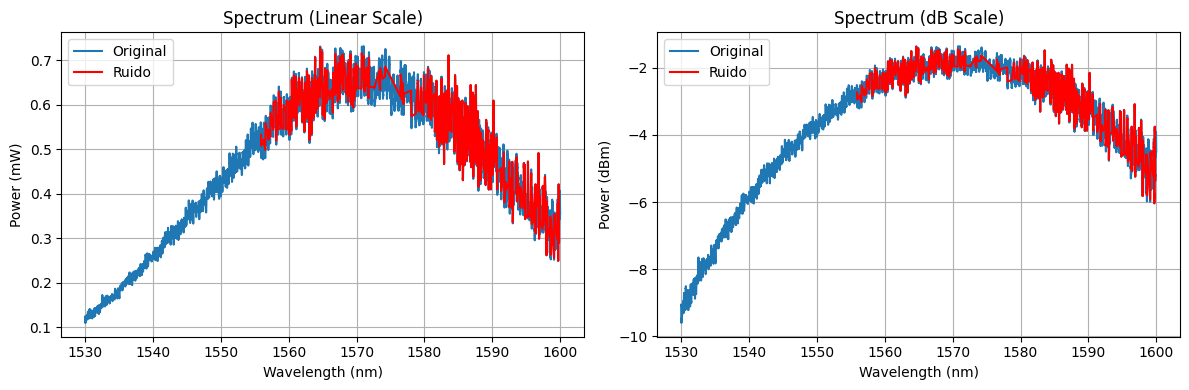

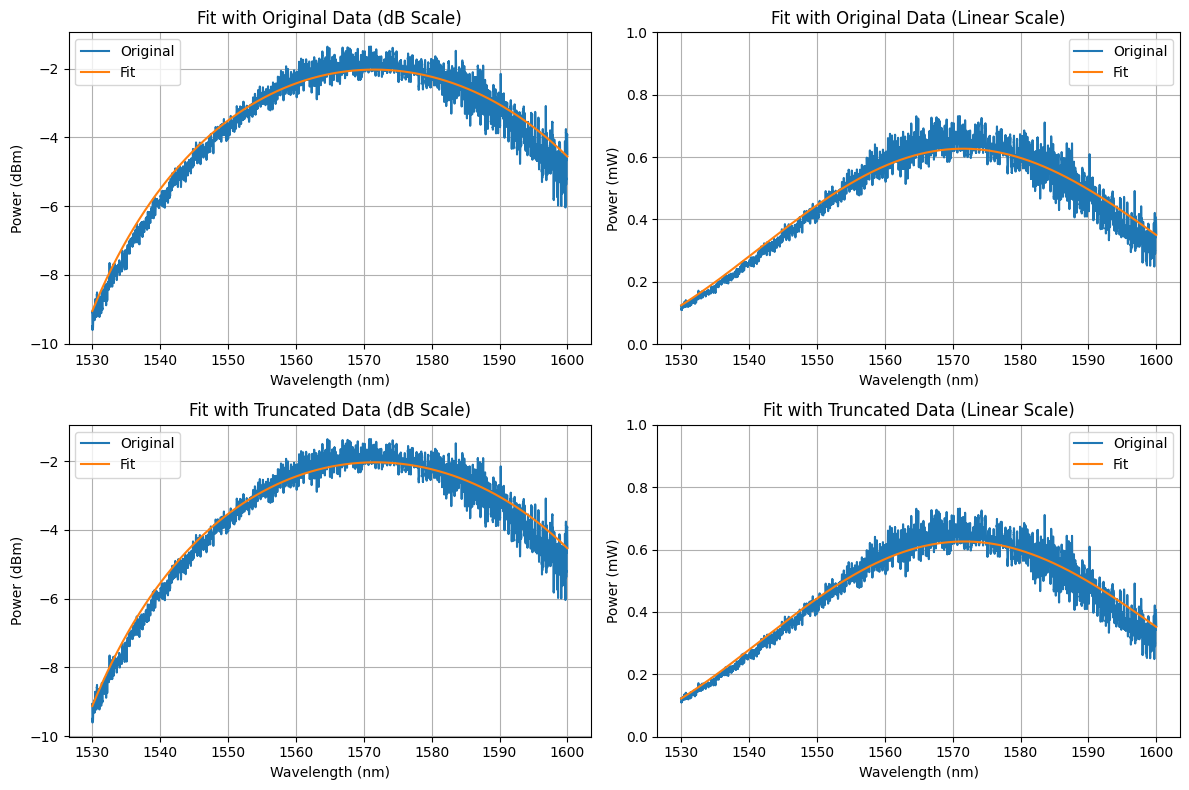

In [ ]:
## Output port 2, v3
threshold_dB = np.inf
wavelength_mzi2_12_v3_filter, power_mzi2_12_v3_filter, wavelength_noise, power_noise = surpress_noise(wavelength_mzi2_12_v3, power_mzi2_12_v3, window_size = 0.1, threshold_dB = threshold_dB, plot=True)

power_mzi2_12_v3_fit, popt_mzi2_12_v3 = cosine_fit(wavelength_mzi2_12_v3, power_mzi2_12_v3, dL)
power_mzi2_12_v3_fit_2, popt_mzi2_12_v3_2 = cosine_fit(wavelength_mzi2_12_v3_filter, power_mzi2_12_v3_filter, dL, wavelength_out = wavelength_mzi2_12_v3)

fig, ax = plt.subplots(2,2, figsize=(12, 8))

ax[0, 0].plot(wavelength_mzi2_12_v3, power_mzi2_12_v3, label = 'Original')
ax[0, 0].plot(wavelength_mzi2_12_v3, power_mzi2_12_v3_fit, label='Fit')
ax[0, 0].set_xlabel('Wavelength (nm)')   
ax[0, 0].set_ylabel('Power (dBm)')
ax[0, 0].set_title('Fit with Original Data (dB Scale)')
ax[0, 0].legend()
ax[0, 0].grid()

ax[0, 1].plot(wavelength_mzi2_12_v3, 10**(power_mzi2_12_v3/10), label = 'Original')
ax[0, 1].plot(wavelength_mzi2_12_v3, 10**(power_mzi2_12_v3_fit/10), label='Fit')
ax[0, 1].set_ylim(0, 1)
ax[0, 1].set_xlabel('Wavelength (nm)')   
ax[0, 1].set_ylabel('Power (mW)')
ax[0, 1].set_title('Fit with Original Data (Linear Scale)')
ax[0, 1].legend()
ax[0, 1].grid()

ax[1, 0].plot(wavelength_mzi2_12_v3, power_mzi2_12_v3, label = 'Original')
ax[1, 0].plot(wavelength_mzi2_12_v3, power_mzi2_12_v3_fit_2, label='Fit')
ax[1, 0].set_xlabel('Wavelength (nm)')   
ax[1, 0].set_ylabel('Power (dBm)')
ax[1, 0].set_title('Fit with Truncated Data (dB Scale)')
ax[1, 0].legend()
ax[1, 0].grid()

ax[1, 1].plot(wavelength_mzi2_12_v3, 10**(power_mzi2_12_v3/10), label = 'Original')
ax[1, 1].plot(wavelength_mzi2_12_v3, 10**(power_mzi2_12_v3_fit_2/10), label='Fit')
ax[1, 1].set_ylim(0, 1)
ax[1, 1].set_xlabel('Wavelength (nm)')   
ax[1, 1].set_ylabel('Power (mW)')
ax[1, 1].set_title('Fit with Truncated Data (Linear Scale)')
ax[1, 1].legend()
ax[1, 1].grid()

plt.tight_layout()
plt.show()

### Absolute Dephase

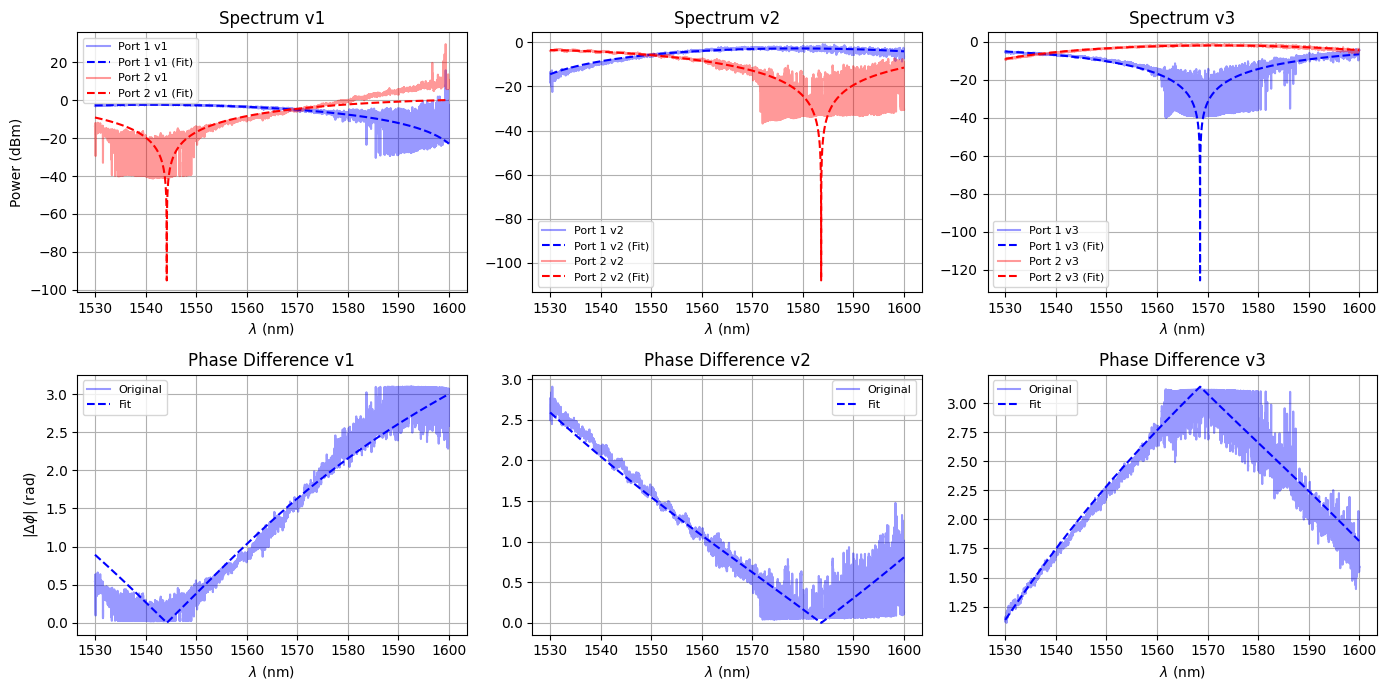

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(14, 7))

axs[0, 0].plot(wavelength_mzi2_11_v1, power_mzi2_11_v1, label='Port 1 v1', alpha=0.4, color='blue')
axs[0, 0].plot(wavelength_mzi2_11_v1, power_mzi2_11_v1_fit_2, label='Port 1 v1 (Fit)', color='blue', linestyle='--')
axs[0, 0].plot(wavelength_mzi2_12_v1, power_mzi2_12_v1, label='Port 2 v1', alpha=0.4, color='red')
axs[0, 0].plot(wavelength_mzi2_12_v1, power_mzi2_12_v1_fit_2, label='Port 2 v1 (Fit)', color='red', linestyle='--')
axs[0, 0].set_title('Spectrum v1')
axs[0, 0].set_xlabel(r'$\lambda$ (nm)')
axs[0, 0].set_ylabel('Power (dBm)')
axs[0, 0].grid()
axs[0, 0].legend(fontsize=8)

axs[0, 1].plot(wavelength_mzi2_11_v2, power_mzi2_11_v2, label='Port 1 v2', alpha=0.4, color='blue')
axs[0, 1].plot(wavelength_mzi2_11_v2, power_mzi2_11_v2_fit_2, label='Port 1 v2 (Fit)', color='blue', linestyle='--')
axs[0, 1].plot(wavelength_mzi2_12_v2, power_mzi2_12_v2, label='Port 2 v2', alpha=0.4, color='red')
axs[0, 1].plot(wavelength_mzi2_12_v2, power_mzi2_12_v2_fit_2, label='Port 2 v2 (Fit)', color='red', linestyle='--')
axs[0, 1].set_title('Spectrum v2')
axs[0, 1].set_xlabel(r'$\lambda$ (nm)')
axs[0, 1].grid()
axs[0, 1].legend(fontsize=8)

axs[0, 2].plot(wavelength_mzi2_11_v3, power_mzi2_11_v3, label='Port 1 v3', alpha=0.4, color='blue')
axs[0, 2].plot(wavelength_mzi2_11_v3, power_mzi2_11_v3_fit_2, label='Port 1 v3 (Fit)', color='blue', linestyle='--')
axs[0, 2].plot(wavelength_mzi2_12_v3, power_mzi2_12_v3, label='Port 2 v3', alpha=0.4, color='red')
axs[0, 2].plot(wavelength_mzi2_12_v3, power_mzi2_12_v3_fit_2, label='Port 2 v3 (Fit)', color='red', linestyle='--')
axs[0, 2].set_title('Spectrum v3')
axs[0, 2].set_xlabel(r'$\lambda$ (nm)')
axs[0, 2].grid()
axs[0, 2].legend(fontsize=8)

delta_phi_v1 = ideal_dephase(wavelength_mzi2_11_v1, power_mzi2_11_v1, power_mzi2_12_v1)
delta_phi_v2 = ideal_dephase(wavelength_mzi2_11_v2, power_mzi2_11_v2, power_mzi2_12_v2)
delta_phi_v3 = ideal_dephase(wavelength_mzi2_11_v3, power_mzi2_11_v3, power_mzi2_12_v3)

delta_phi_v1_fit = ideal_dephase(wavelength_mzi2_11_v1, power_mzi2_11_v1_fit_2, power_mzi2_12_v1_fit_2)
delta_phi_v2_fit = ideal_dephase(wavelength_mzi2_11_v2, power_mzi2_11_v2_fit_2, power_mzi2_12_v2_fit_2)
delta_phi_v3_fit = ideal_dephase(wavelength_mzi2_11_v3, power_mzi2_11_v3_fit_2, power_mzi2_12_v3_fit_2)

axs[1, 0].plot(wavelength_mzi2_11_v1, delta_phi_v1, label='Original', alpha=0.4, color='blue')
axs[1, 0].plot(wavelength_mzi2_11_v1, delta_phi_v1_fit, label='Fit', color='blue', linestyle='--')
axs[1, 0].set_title('Phase Difference v1')
axs[1, 0].set_xlabel(r'$\lambda$ (nm)')
axs[1, 0].set_ylabel(r'$|\Delta \phi|$ (rad)')
axs[1, 0].legend(fontsize=8)
axs[1, 0].grid()

axs[1, 1].plot(wavelength_mzi2_11_v2, delta_phi_v2, label='Original', alpha=0.4, color='blue')
axs[1, 1].plot(wavelength_mzi2_11_v2, delta_phi_v2_fit, label='Fit', color='blue', linestyle='--')
axs[1, 1].set_title('Phase Difference v2')
axs[1, 1].set_xlabel(r'$\lambda$ (nm)')
axs[1, 1].legend(fontsize=8)
axs[1, 1].grid()

axs[1, 2].plot(wavelength_mzi2_11_v3, delta_phi_v3, label='Original', alpha=0.4, color='blue')
axs[1, 2].plot(wavelength_mzi2_11_v3, delta_phi_v3_fit, label='Fit', color='blue', linestyle='--')
axs[1, 2].set_title('Phase Difference v3')
axs[1, 2].set_xlabel(r'$\lambda$ (nm)')
axs[1, 2].legend(fontsize=8)
axs[1, 2].grid()

#plt.suptitle(r'MZI: $\Delta L = 0$ um', fontsize=14)
plt.tight_layout()
plt.show()

## MZI ΔL = 30 um

In [14]:
# Common variables
dL = 30e-6

### Fitting

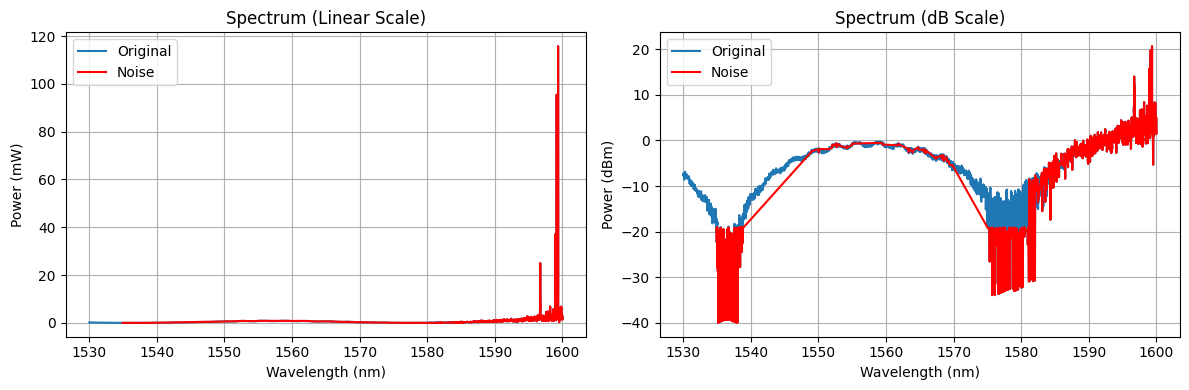

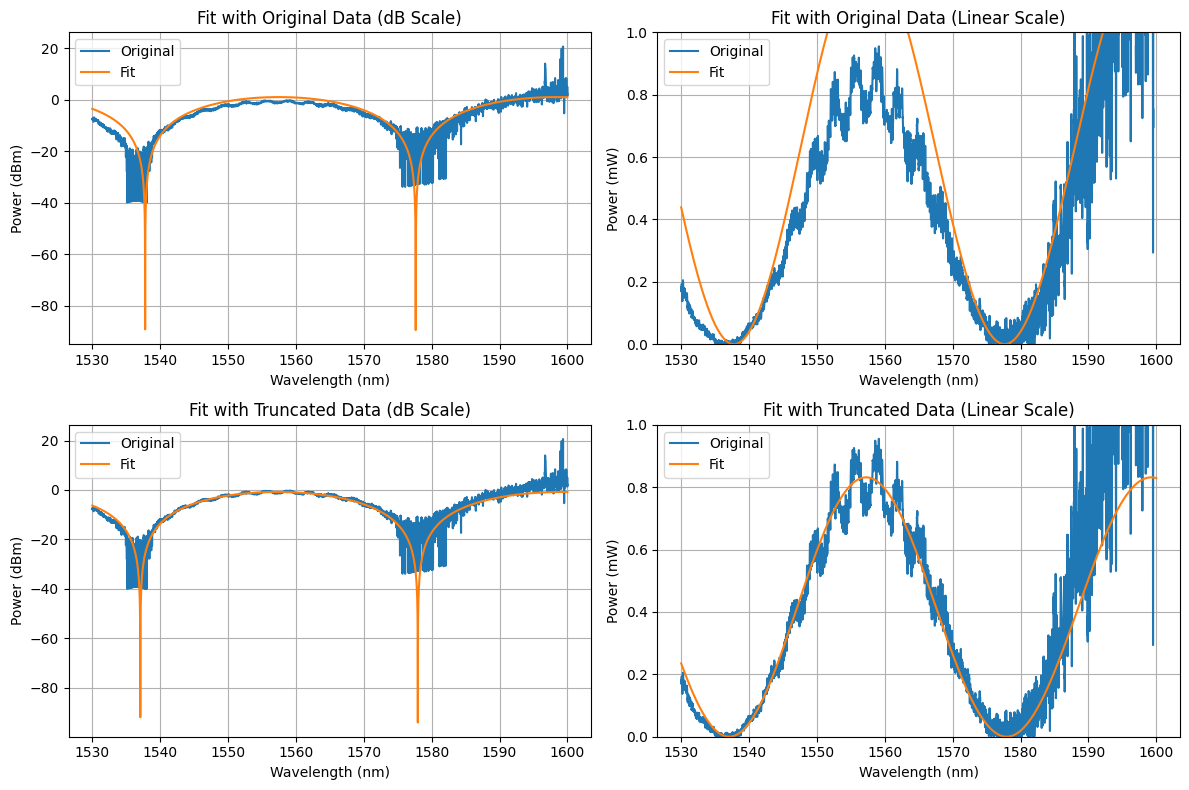

In [15]:
## Output port 1, v1
threshold_dB = 20
wavelength_mzi3_11_v1_filter, power_mzi3_11_v1_filter, wavelength_noise, power_noise = surpress_noise(wavelength_mzi3_11_v1, power_mzi3_11_v1, window_size = 0.1, threshold_dB = threshold_dB, plot=True)

power_mzi3_11_v1_fit, popt_mzi3_11_v1 = cosine_fit(wavelength_mzi3_11_v1, power_mzi3_11_v1, dL)
power_mzi3_11_v1_fit_2, popt_mzi3_11_v1_2 = cosine_fit(wavelength_mzi3_11_v1_filter, power_mzi3_11_v1_filter, dL, wavelength_out = wavelength_mzi3_11_v1)

fig, ax = plt.subplots(2,2, figsize=(12, 8))

ax[0, 0].plot(wavelength_mzi3_11_v1, power_mzi3_11_v1, label = 'Original')
ax[0, 0].plot(wavelength_mzi3_11_v1, power_mzi3_11_v1_fit, label='Fit')
ax[0, 0].set_xlabel('Wavelength (nm)')   
ax[0, 0].set_ylabel('Power (dBm)')
ax[0, 0].set_title('Fit with Original Data (dB Scale)')
ax[0, 0].legend()
ax[0, 0].grid()

ax[0, 1].plot(wavelength_mzi3_11_v1, 10**(power_mzi3_11_v1/10), label = 'Original')
ax[0, 1].plot(wavelength_mzi3_11_v1, 10**(power_mzi3_11_v1_fit/10), label='Fit')
ax[0, 1].set_ylim(0, 1)
ax[0, 1].set_xlabel('Wavelength (nm)')   
ax[0, 1].set_ylabel('Power (mW)')
ax[0, 1].set_title('Fit with Original Data (Linear Scale)')
ax[0, 1].legend()
ax[0, 1].grid()

ax[1, 0].plot(wavelength_mzi3_11_v1, power_mzi3_11_v1, label = 'Original')
ax[1, 0].plot(wavelength_mzi3_11_v1, power_mzi3_11_v1_fit_2, label='Fit')
ax[1, 0].set_xlabel('Wavelength (nm)')   
ax[1, 0].set_ylabel('Power (dBm)')
ax[1, 0].set_title('Fit with Truncated Data (dB Scale)')
ax[1, 0].legend()
ax[1, 0].grid()

ax[1, 1].plot(wavelength_mzi3_11_v1, 10**(power_mzi3_11_v1/10), label = 'Original')
ax[1, 1].plot(wavelength_mzi3_11_v1, 10**(power_mzi3_11_v1_fit_2/10), label='Fit')
ax[1, 1].set_ylim(0, 1)
ax[1, 1].set_xlabel('Wavelength (nm)')   
ax[1, 1].set_ylabel('Power (mW)')
ax[1, 1].set_title('Fit with Truncated Data (Linear Scale)')
ax[1, 1].legend()
ax[1, 1].grid()

plt.tight_layout()
plt.show()

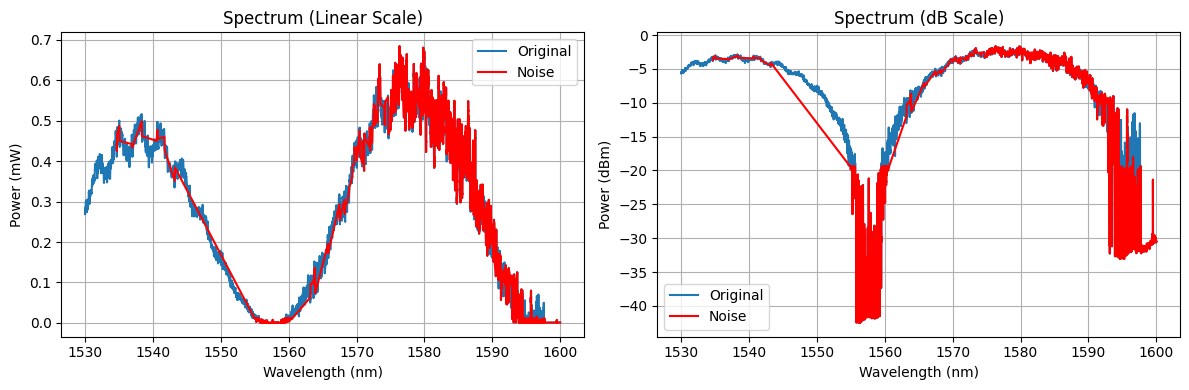

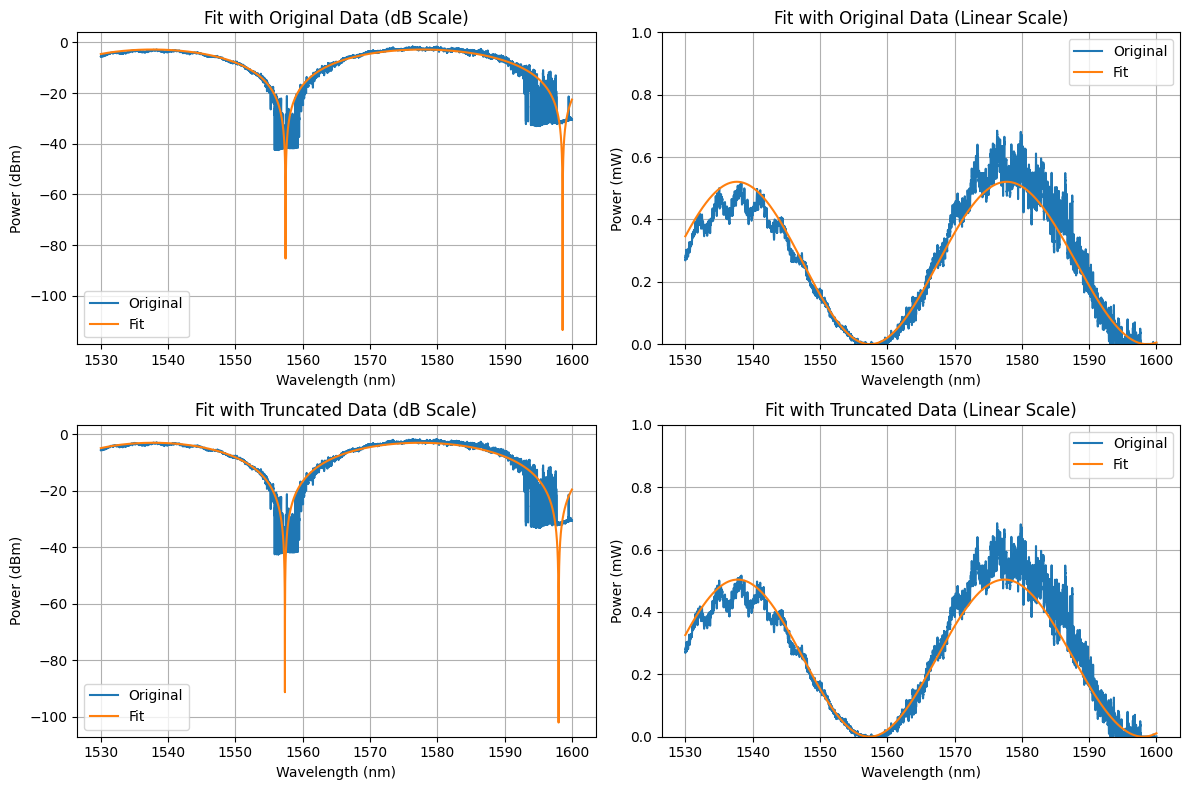

In [16]:
## Output port 1, v2
threshold_dB = 20
wavelength_mzi3_11_v2_filter, power_mzi3_11_v2_filter, wavelength_noise, power_noise = surpress_noise(wavelength_mzi3_11_v2, power_mzi3_11_v2, window_size = 0.1, threshold_dB = threshold_dB, plot=True)

power_mzi3_11_v2_fit, popt_mzi3_11_v2 = cosine_fit(wavelength_mzi3_11_v2, power_mzi3_11_v2, dL)
power_mzi3_11_v2_fit_2, popt_mzi3_11_v2_2 = cosine_fit(wavelength_mzi3_11_v2_filter, power_mzi3_11_v2_filter, dL, wavelength_out = wavelength_mzi3_11_v2)

fig, ax = plt.subplots(2,2, figsize=(12, 8))

ax[0, 0].plot(wavelength_mzi3_11_v2, power_mzi3_11_v2, label = 'Original')
ax[0, 0].plot(wavelength_mzi3_11_v2, power_mzi3_11_v2_fit, label='Fit')
ax[0, 0].set_xlabel('Wavelength (nm)')   
ax[0, 0].set_ylabel('Power (dBm)')
ax[0, 0].set_title('Fit with Original Data (dB Scale)')
ax[0, 0].legend()
ax[0, 0].grid()

ax[0, 1].plot(wavelength_mzi3_11_v2, 10**(power_mzi3_11_v2/10), label = 'Original')
ax[0, 1].plot(wavelength_mzi3_11_v2, 10**(power_mzi3_11_v2_fit/10), label='Fit')
ax[0, 1].set_ylim(0, 1)
ax[0, 1].set_xlabel('Wavelength (nm)')   
ax[0, 1].set_ylabel('Power (mW)')
ax[0, 1].set_title('Fit with Original Data (Linear Scale)')
ax[0, 1].legend()
ax[0, 1].grid()

ax[1, 0].plot(wavelength_mzi3_11_v2, power_mzi3_11_v2, label = 'Original')
ax[1, 0].plot(wavelength_mzi3_11_v2, power_mzi3_11_v2_fit_2, label='Fit')
ax[1, 0].set_xlabel('Wavelength (nm)')   
ax[1, 0].set_ylabel('Power (dBm)')
ax[1, 0].set_title('Fit with Truncated Data (dB Scale)')
ax[1, 0].legend()
ax[1, 0].grid()

ax[1, 1].plot(wavelength_mzi3_11_v2, 10**(power_mzi3_11_v2/10), label = 'Original')
ax[1, 1].plot(wavelength_mzi3_11_v2, 10**(power_mzi3_11_v2_fit_2/10), label='Fit')
ax[1, 1].set_ylim(0, 1)
ax[1, 1].set_xlabel('Wavelength (nm)')   
ax[1, 1].set_ylabel('Power (mW)')
ax[1, 1].set_title('Fit with Truncated Data (Linear Scale)')
ax[1, 1].legend()
ax[1, 1].grid()

plt.tight_layout()
plt.show()

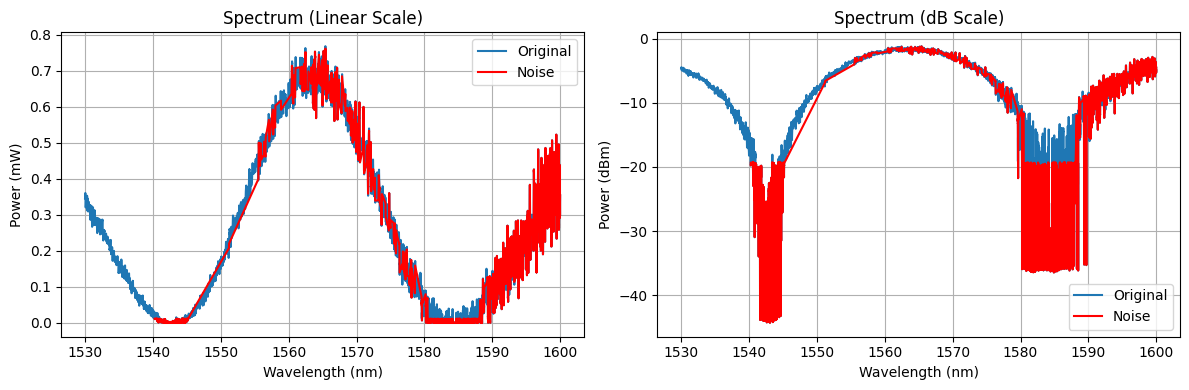

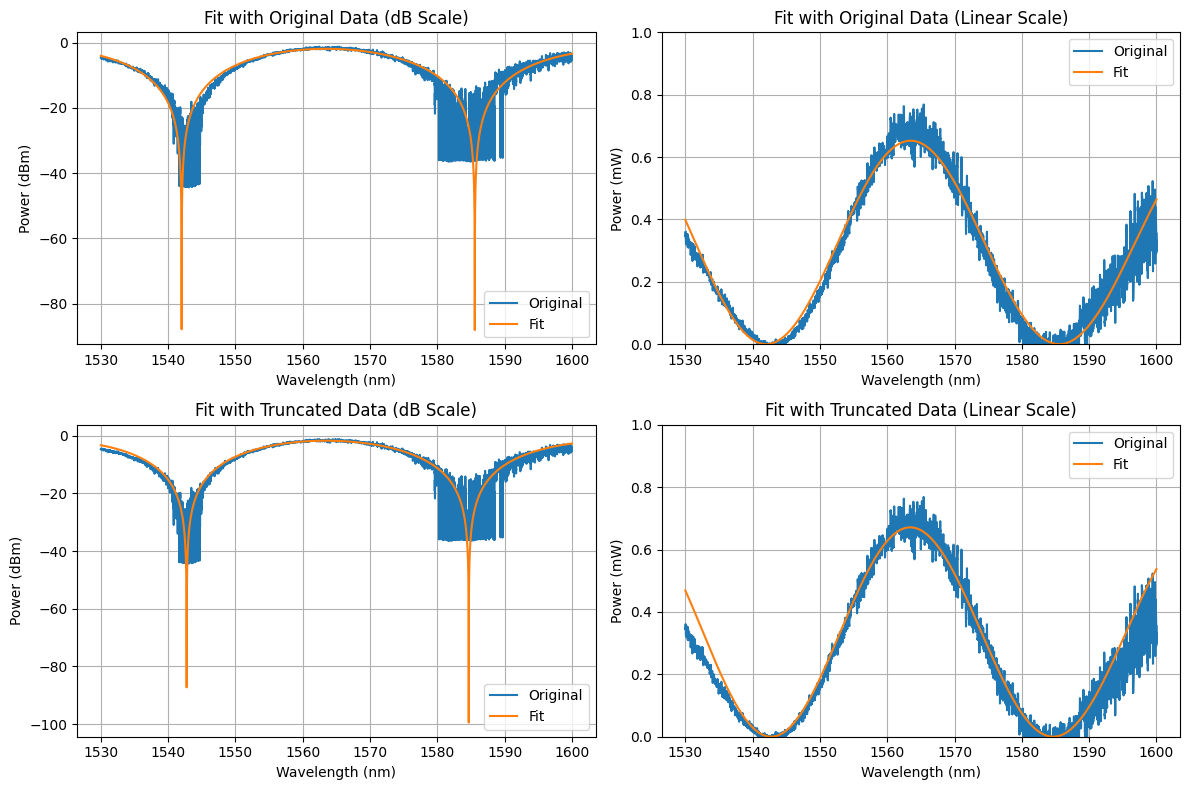

In [17]:
## Output port 1, v3
threshold_dB = 20
wavelength_mzi3_11_v3_filter, power_mzi3_11_v3_filter, wavelength_noise, power_noise = surpress_noise(wavelength_mzi3_11_v3, power_mzi3_11_v3, window_size = 0.1, threshold_dB = threshold_dB, plot=True)

power_mzi3_11_v3_fit, popt_mzi3_11_v3 = cosine_fit(wavelength_mzi3_11_v3, power_mzi3_11_v3, dL)

wavelength_mzi3_11_v3_filter, power_mzi3_11_v3_filter = filter_wavelength(wavelength_mzi3_11_v3_filter, power_mzi3_11_v3_filter, 1535, 1580)
power_mzi3_11_v3_fit_2, popt_mzi3_11_v3_2 = cosine_fit(wavelength_mzi3_11_v3_filter, power_mzi3_11_v3_filter, dL, wavelength_out = wavelength_mzi3_11_v3)

fig, ax = plt.subplots(2,2, figsize=(12, 8))

ax[0, 0].plot(wavelength_mzi3_11_v3, power_mzi3_11_v3, label = 'Original')
ax[0, 0].plot(wavelength_mzi3_11_v3, power_mzi3_11_v3_fit, label=f'Fit')
ax[0, 0].set_xlabel('Wavelength (nm)')   
ax[0, 0].set_ylabel('Power (dBm)')
ax[0, 0].set_title('Fit with Original Data (dB Scale)')
ax[0, 0].legend()
ax[0, 0].grid()

ax[0, 1].plot(wavelength_mzi3_11_v3, 10**(power_mzi3_11_v3/10), label = 'Original')
ax[0, 1].plot(wavelength_mzi3_11_v3, 10**(power_mzi3_11_v3_fit/10), label=f'Fit')
ax[0, 1].set_ylim(0, 1)
ax[0, 1].set_xlabel('Wavelength (nm)')   
ax[0, 1].set_ylabel('Power (mW)')
ax[0, 1].set_title('Fit with Original Data (Linear Scale)')
ax[0, 1].legend()
ax[0, 1].grid()

ax[1, 0].plot(wavelength_mzi3_11_v3, power_mzi3_11_v3, label = 'Original')
ax[1, 0].plot(wavelength_mzi3_11_v3, power_mzi3_11_v3_fit_2, label=f'Fit')
ax[1, 0].set_xlabel('Wavelength (nm)')   
ax[1, 0].set_ylabel('Power (dBm)')
ax[1, 0].set_title('Fit with Truncated Data (dB Scale)')
ax[1, 0].legend()
ax[1, 0].grid()

ax[1, 1].plot(wavelength_mzi3_11_v3, 10**(power_mzi3_11_v3/10), label = 'Original')
ax[1, 1].plot(wavelength_mzi3_11_v3, 10**(power_mzi3_11_v3_fit_2/10), label=f'Fit')
ax[1, 1].set_ylim(0, 1)
ax[1, 1].set_xlabel('Wavelength (nm)')   
ax[1, 1].set_ylabel('Power (mW)')
ax[1, 1].set_title('Fit with Truncated Data (Linear Scale)')
ax[1, 1].legend()
ax[1, 1].grid()

plt.tight_layout()
plt.show()

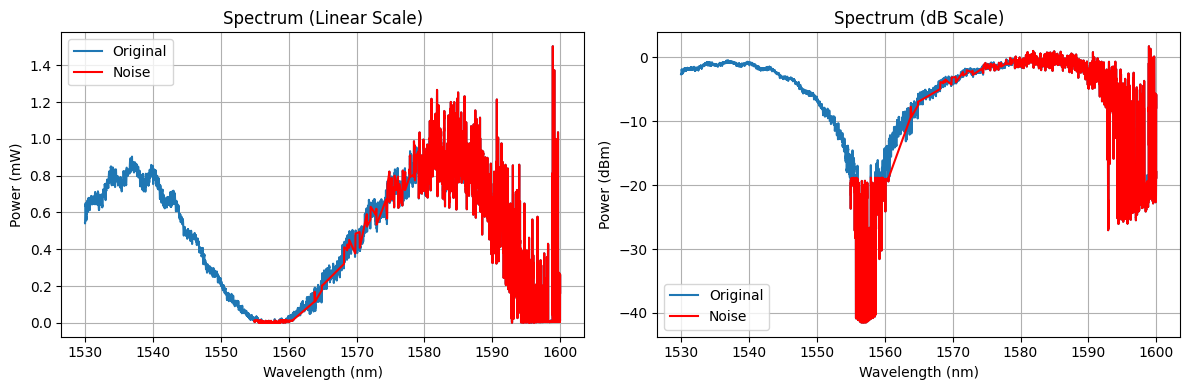

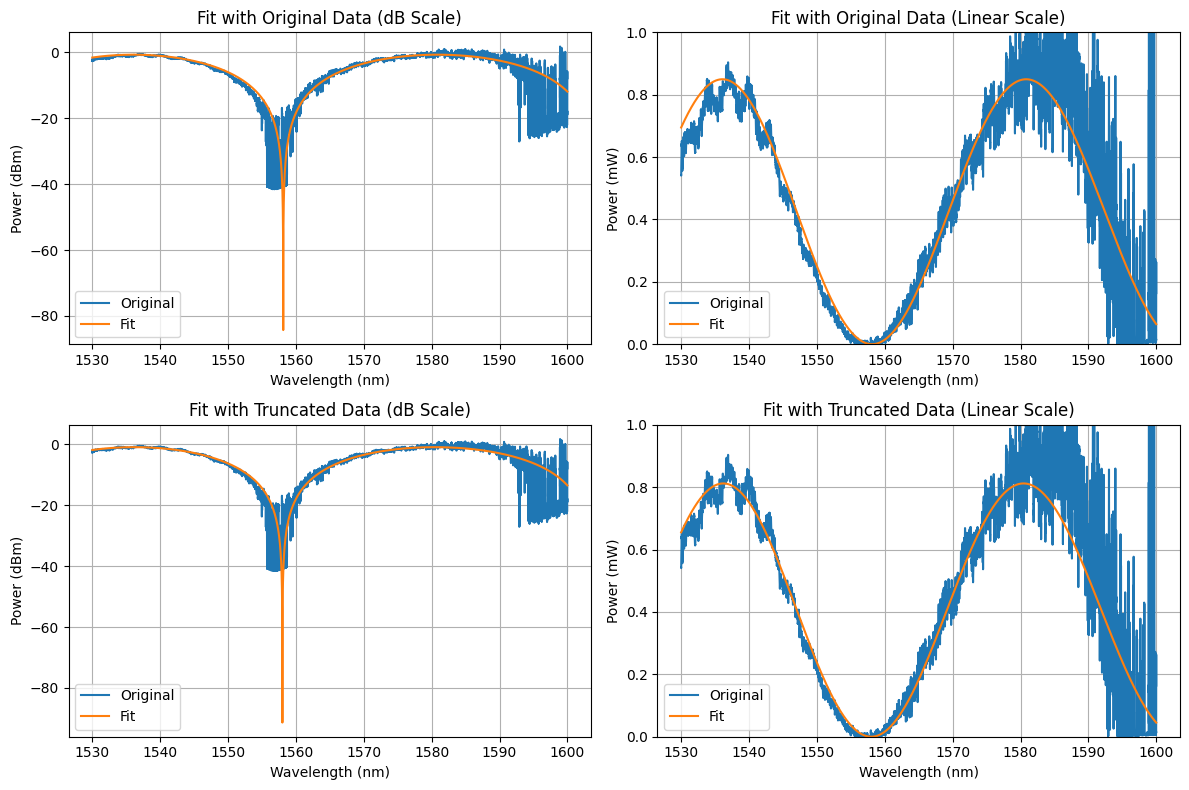

In [18]:
## Output port 2, v1
threshold_dB = 20
wavelength_mzi3_12_v1_filter, power_mzi3_12_v1_filter, wavelength_noise, power_noise = surpress_noise(wavelength_mzi3_12_v1, power_mzi3_12_v1, window_size = 0.1, threshold_dB = threshold_dB, plot=True)

power_mzi3_12_v1_fit, popt_mzi3_12_v1 = cosine_fit(wavelength_mzi3_12_v1, power_mzi3_12_v1, dL)
power_mzi3_12_v1_fit_2, popt_mzi3_12_v1_2 = cosine_fit(wavelength_mzi3_12_v1_filter, power_mzi3_12_v1_filter, dL, wavelength_out = wavelength_mzi3_12_v1)

fig, ax = plt.subplots(2,2, figsize=(12, 8))

ax[0, 0].plot(wavelength_mzi3_12_v1, power_mzi3_12_v1, label = 'Original')
ax[0, 0].plot(wavelength_mzi3_12_v1, power_mzi3_12_v1_fit, label=f'Fit')
ax[0, 0].set_xlabel('Wavelength (nm)')   
ax[0, 0].set_ylabel('Power (dBm)')
ax[0, 0].set_title('Fit with Original Data (dB Scale)')
ax[0, 0].legend()
ax[0, 0].grid()

ax[0, 1].plot(wavelength_mzi3_12_v1, 10**(power_mzi3_12_v1/10), label = 'Original')
ax[0, 1].plot(wavelength_mzi3_12_v1, 10**(power_mzi3_12_v1_fit/10), label=f'Fit')
ax[0, 1].set_ylim(0, 1)
ax[0, 1].set_xlabel('Wavelength (nm)')   
ax[0, 1].set_ylabel('Power (mW)')
ax[0, 1].set_title('Fit with Original Data (Linear Scale)')
ax[0, 1].legend()
ax[0, 1].grid()

ax[1, 0].plot(wavelength_mzi3_12_v1, power_mzi3_12_v1, label = 'Original')
ax[1, 0].plot(wavelength_mzi3_12_v1, power_mzi3_12_v1_fit_2, label=f'Fit')
ax[1, 0].set_xlabel('Wavelength (nm)')   
ax[1, 0].set_ylabel('Power (dBm)')
ax[1, 0].set_title('Fit with Truncated Data (dB Scale)')
ax[1, 0].legend()
ax[1, 0].grid()

ax[1, 1].plot(wavelength_mzi3_12_v1, 10**(power_mzi3_12_v1/10), label = 'Original')
ax[1, 1].plot(wavelength_mzi3_12_v1, 10**(power_mzi3_12_v1_fit_2/10), label=f'Fit')
ax[1, 1].set_ylim(0, 1)
ax[1, 1].set_xlabel('Wavelength (nm)')   
ax[1, 1].set_ylabel('Power (mW)')
ax[1, 1].set_title('Fit with Truncated Data (Linear Scale)')
ax[1, 1].legend()
ax[1, 1].grid()

plt.tight_layout()
plt.show()

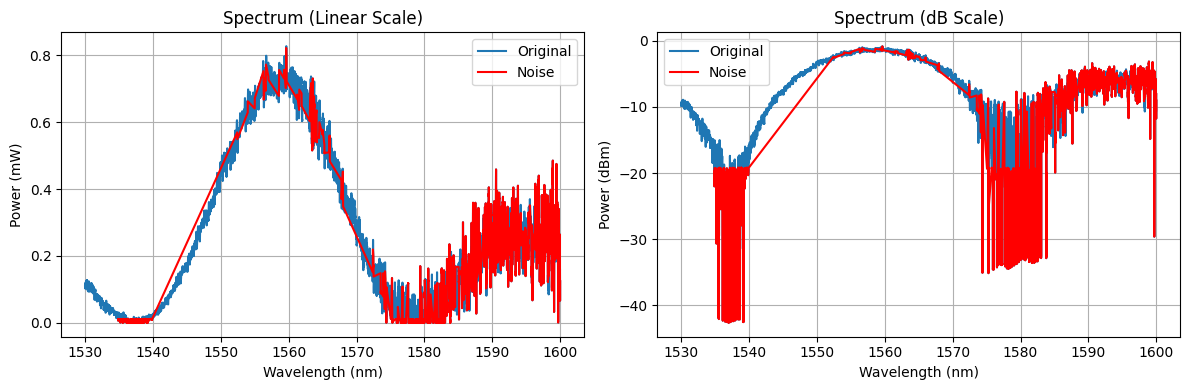

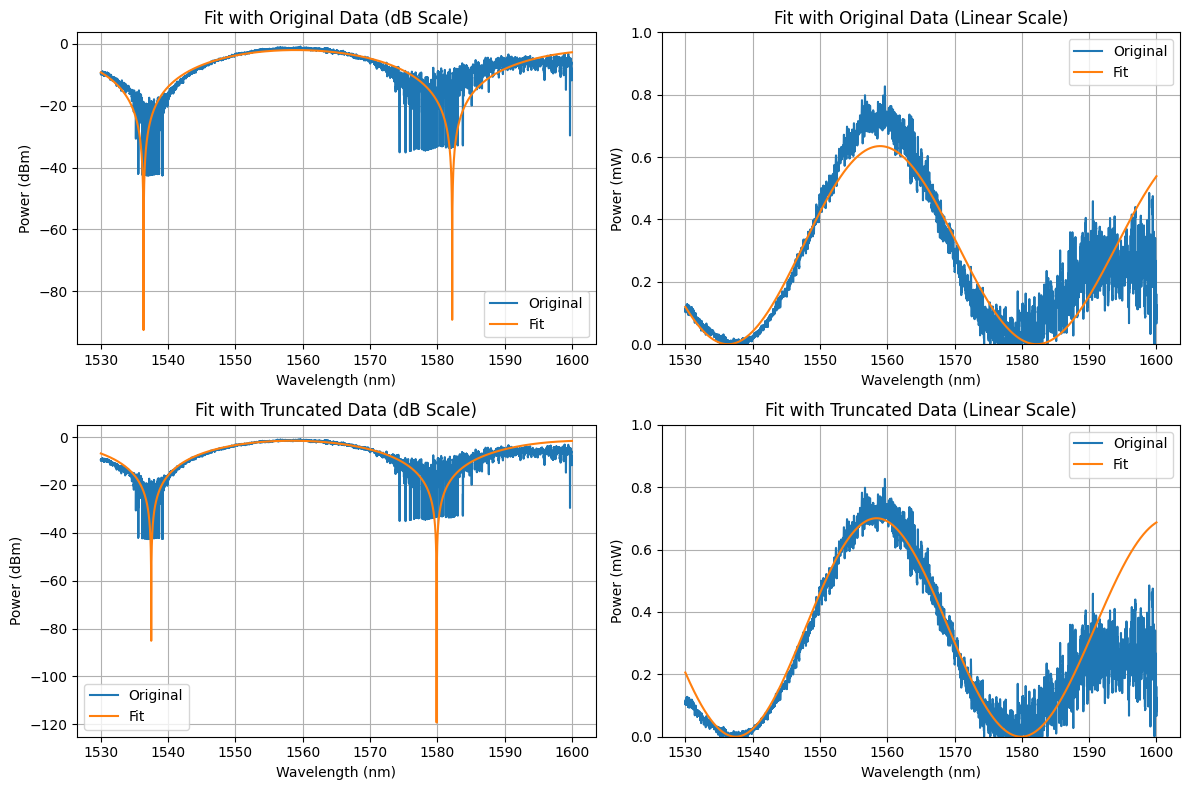

In [19]:
## Output port 2, v2
threshold_dB = 20
wavelength_mzi3_12_v2_filter, power_mzi3_12_v2_filter, wavelength_noise, power_noise = surpress_noise(wavelength_mzi3_12_v2, power_mzi3_12_v2, window_size = 0.1, threshold_dB = threshold_dB, plot=True)

power_mzi3_12_v2_fit, popt_mzi3_12_v2 = cosine_fit(wavelength_mzi3_12_v2, power_mzi3_12_v2, dL)

wavelength_mzi3_12_v2_filter, power_mzi3_12_v2_filter = filter_wavelength(wavelength_mzi3_12_v2_filter, power_mzi3_12_v2_filter, wl_0, 1580)
power_mzi3_12_v2_fit_2, popt_mzi3_12_v2_2 = cosine_fit(wavelength_mzi3_12_v2_filter, power_mzi3_12_v2_filter, dL, wavelength_out = wavelength_mzi3_12_v2)

fig, ax = plt.subplots(2,2, figsize=(12, 8))

ax[0, 0].plot(wavelength_mzi3_12_v2, power_mzi3_12_v2, label = 'Original')
ax[0, 0].plot(wavelength_mzi3_12_v2, power_mzi3_12_v2_fit, label='Fit')
ax[0, 0].set_xlabel('Wavelength (nm)')   
ax[0, 0].set_ylabel('Power (dBm)')
ax[0, 0].set_title('Fit with Original Data (dB Scale)')
ax[0, 0].legend()
ax[0, 0].grid()

ax[0, 1].plot(wavelength_mzi3_12_v2, 10**(power_mzi3_12_v2/10), label = 'Original')
ax[0, 1].plot(wavelength_mzi3_12_v2, 10**(power_mzi3_12_v2_fit/10), label='Fit')
ax[0, 1].set_ylim(0, 1)
ax[0, 1].set_xlabel('Wavelength (nm)')   
ax[0, 1].set_ylabel('Power (mW)')
ax[0, 1].set_title('Fit with Original Data (Linear Scale)')
ax[0, 1].legend()
ax[0, 1].grid()

ax[1, 0].plot(wavelength_mzi3_12_v2, power_mzi3_12_v2, label = 'Original')
ax[1, 0].plot(wavelength_mzi3_12_v2, power_mzi3_12_v2_fit_2, label='Fit')
ax[1, 0].set_xlabel('Wavelength (nm)')   
ax[1, 0].set_ylabel('Power (dBm)')
ax[1, 0].set_title('Fit with Truncated Data (dB Scale)')
ax[1, 0].legend()
ax[1, 0].grid()

ax[1, 1].plot(wavelength_mzi3_12_v2, 10**(power_mzi3_12_v2/10), label = 'Original')
ax[1, 1].plot(wavelength_mzi3_12_v2, 10**(power_mzi3_12_v2_fit_2/10), label='Fit')
ax[1, 1].set_ylim(0, 1)
ax[1, 1].set_xlabel('Wavelength (nm)')   
ax[1, 1].set_ylabel('Power (mW)')
ax[1, 1].set_title('Fit with Truncated Data (Linear Scale)')
ax[1, 1].legend()
ax[1, 1].grid()

plt.tight_layout()
plt.show()

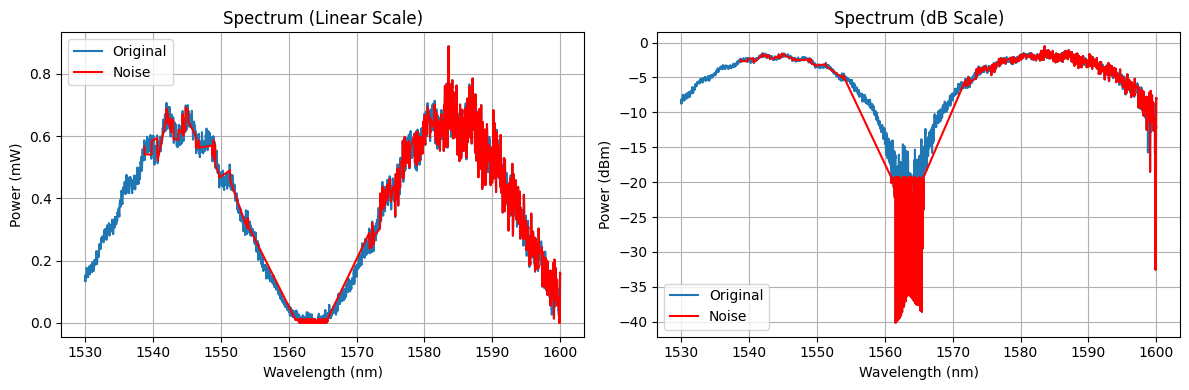

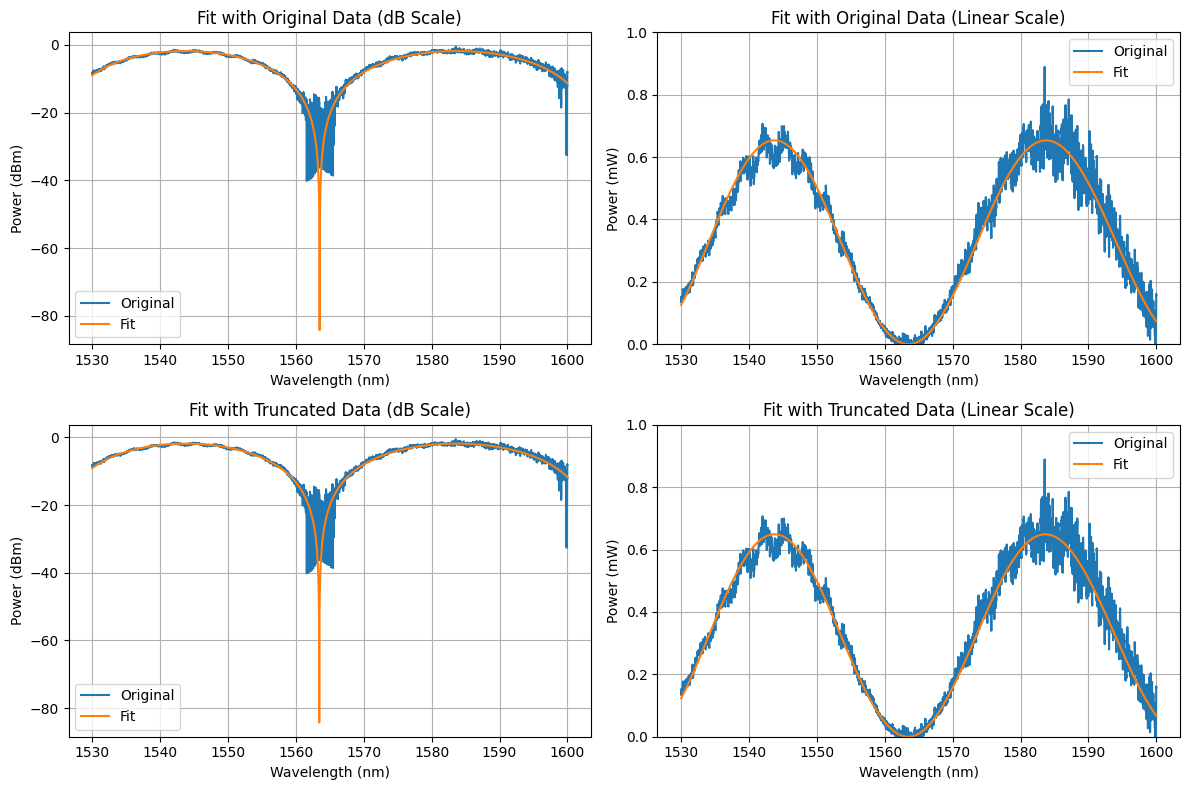

In [20]:
## Output port 2, v3
threshold_dB = 20
wavelength_mzi3_12_v3_filter, power_mzi3_12_v3_filter, wavelength_noise, power_noise = surpress_noise(wavelength_mzi3_12_v3, power_mzi3_12_v3, window_size = 0.1, threshold_dB = threshold_dB, plot=True)

power_mzi3_12_v3_fit, popt_mzi3_12_v3 = cosine_fit(wavelength_mzi3_12_v3, power_mzi3_12_v3, dL)
power_mzi3_12_v3_fit_2, popt_mzi3_12_v3_2 = cosine_fit(wavelength_mzi3_12_v3_filter, power_mzi3_12_v3_filter, dL, wavelength_out = wavelength_mzi3_12_v3)

fig, ax = plt.subplots(2,2, figsize=(12, 8))

ax[0, 0].plot(wavelength_mzi3_12_v3, power_mzi3_12_v3, label = 'Original')
ax[0, 0].plot(wavelength_mzi3_12_v3, power_mzi3_12_v3_fit, label=f'Fit')
ax[0, 0].set_xlabel('Wavelength (nm)')   
ax[0, 0].set_ylabel('Power (dBm)')
ax[0, 0].set_title('Fit with Original Data (dB Scale)')
ax[0, 0].legend()
ax[0, 0].grid()

ax[0, 1].plot(wavelength_mzi3_12_v3, 10**(power_mzi3_12_v3/10), label = 'Original')
ax[0, 1].plot(wavelength_mzi3_12_v3, 10**(power_mzi3_12_v3_fit/10), label=f'Fit')
ax[0, 1].set_ylim(0, 1)
ax[0, 1].set_xlabel('Wavelength (nm)')   
ax[0, 1].set_ylabel('Power (mW)')
ax[0, 1].set_title('Fit with Original Data (Linear Scale)')
ax[0, 1].legend()
ax[0, 1].grid()

ax[1, 0].plot(wavelength_mzi3_12_v3, power_mzi3_12_v3, label = 'Original')
ax[1, 0].plot(wavelength_mzi3_12_v3, power_mzi3_12_v3_fit_2, label=f'Fit')
ax[1, 0].set_xlabel('Wavelength (nm)')   
ax[1, 0].set_ylabel('Power (dBm)')
ax[1, 0].set_title('Fit with Truncated Data (dB Scale)')
ax[1, 0].legend()
ax[1, 0].grid()

ax[1, 1].plot(wavelength_mzi3_12_v3, 10**(power_mzi3_12_v3/10), label = 'Original')
ax[1, 1].plot(wavelength_mzi3_12_v3, 10**(power_mzi3_12_v3_fit_2/10), label=f'Fit')
ax[1, 1].set_ylim(0, 1)
ax[1, 1].set_xlabel('Wavelength (nm)')   
ax[1, 1].set_ylabel('Power (mW)')
ax[1, 1].set_title('Fit with Truncated Data (Linear Scale)')
ax[1, 1].legend()
ax[1, 1].grid()

plt.tight_layout()
plt.show()

### Absolute Dephase

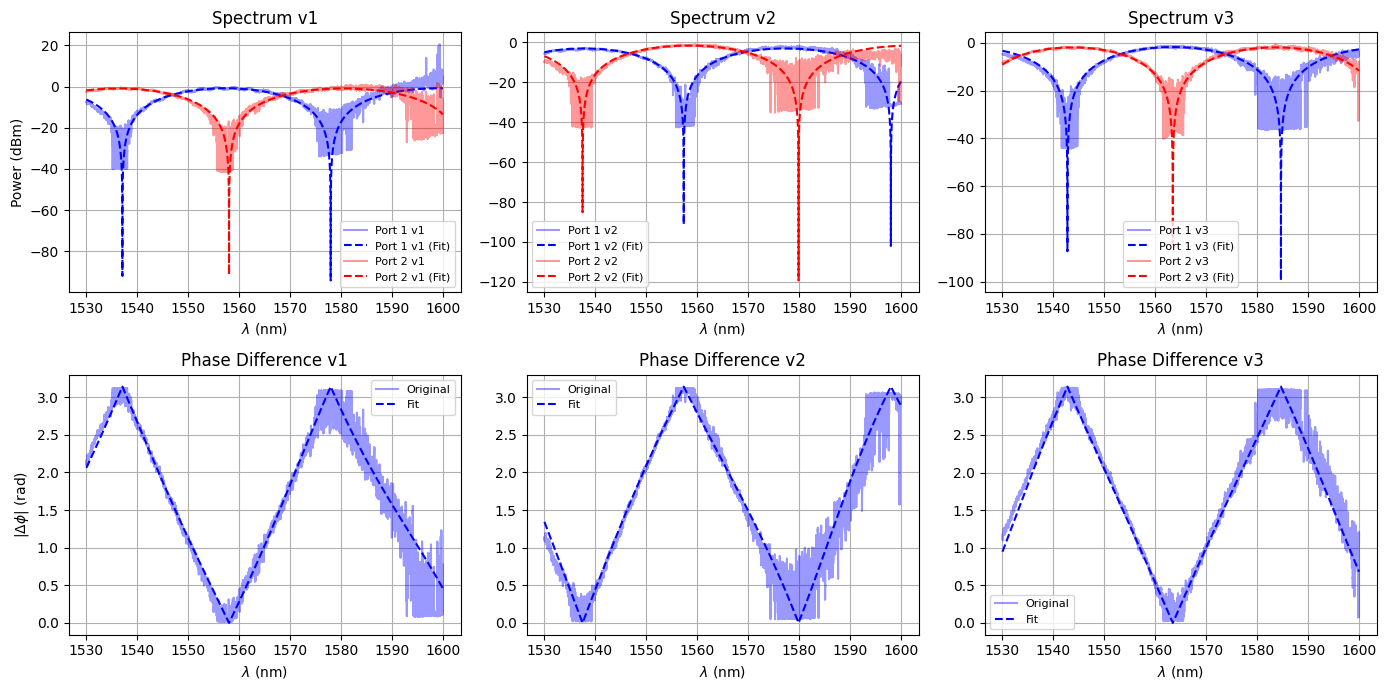

In [21]:
fig, axs = plt.subplots(2, 3, figsize=(14, 7))

axs[0, 0].plot(wavelength_mzi3_11_v1, power_mzi3_11_v1, label='Port 1 v1', alpha=0.4, color='blue')
axs[0, 0].plot(wavelength_mzi3_11_v1, power_mzi3_11_v1_fit_2, label='Port 1 v1 (Fit)', color='blue', linestyle='--')
axs[0, 0].plot(wavelength_mzi3_12_v1, power_mzi3_12_v1, label='Port 2 v1', alpha=0.4, color='red')
axs[0, 0].plot(wavelength_mzi3_12_v1, power_mzi3_12_v1_fit_2, label='Port 2 v1 (Fit)', color='red', linestyle='--')
axs[0, 0].set_title('Spectrum v1')
axs[0, 0].set_xlabel(r'$\lambda$ (nm)')
axs[0, 0].set_ylabel('Power (dBm)')
axs[0, 0].grid()
axs[0, 0].legend(fontsize=8)

axs[0, 1].plot(wavelength_mzi3_11_v2, power_mzi3_11_v2, label='Port 1 v2', alpha=0.4, color='blue')
axs[0, 1].plot(wavelength_mzi3_11_v2, power_mzi3_11_v2_fit_2, label='Port 1 v2 (Fit)', color='blue', linestyle='--')
axs[0, 1].plot(wavelength_mzi3_12_v2, power_mzi3_12_v2, label='Port 2 v2', alpha=0.4, color='red')
axs[0, 1].plot(wavelength_mzi3_12_v2, power_mzi3_12_v2_fit_2, label='Port 2 v2 (Fit)', color='red', linestyle='--')
axs[0, 1].set_title('Spectrum v2')
axs[0, 1].set_xlabel(r'$\lambda$ (nm)')
axs[0, 1].grid()
axs[0, 1].legend(fontsize=8)

axs[0, 2].plot(wavelength_mzi3_11_v3, power_mzi3_11_v3, label='Port 1 v3', alpha=0.4, color='blue')
axs[0, 2].plot(wavelength_mzi3_11_v3, power_mzi3_11_v3_fit_2, label='Port 1 v3 (Fit)', color='blue', linestyle='--')
axs[0, 2].plot(wavelength_mzi3_12_v3, power_mzi3_12_v3, label='Port 2 v3', alpha=0.4, color='red')
axs[0, 2].plot(wavelength_mzi3_12_v3, power_mzi3_12_v3_fit_2, label='Port 2 v3 (Fit)', color='red', linestyle='--')
axs[0, 2].set_title('Spectrum v3')
axs[0, 2].set_xlabel(r'$\lambda$ (nm)')
axs[0, 2].grid()
axs[0, 2].legend(fontsize=8)

delta_phi_v1 = ideal_dephase(wavelength_mzi3_11_v1, power_mzi3_11_v1, power_mzi3_12_v1)
delta_phi_v2 = ideal_dephase(wavelength_mzi3_11_v2, power_mzi3_11_v2, power_mzi3_12_v2)
delta_phi_v3 = ideal_dephase(wavelength_mzi3_11_v3, power_mzi3_11_v3, power_mzi3_12_v3)

delta_phi_v1_fit = ideal_dephase(wavelength_mzi3_11_v1, power_mzi3_11_v1_fit_2, power_mzi3_12_v1_fit_2)
delta_phi_v2_fit = ideal_dephase(wavelength_mzi3_11_v2, power_mzi3_11_v2_fit_2, power_mzi3_12_v2_fit_2)
delta_phi_v3_fit = ideal_dephase(wavelength_mzi3_11_v3, power_mzi3_11_v3_fit_2, power_mzi3_12_v3_fit_2)

axs[1, 0].plot(wavelength_mzi3_11_v1, delta_phi_v1, label='Original', alpha=0.4, color='blue')
axs[1, 0].plot(wavelength_mzi3_11_v1, delta_phi_v1_fit, label='Fit', color='blue', linestyle='--')
axs[1, 0].set_title('Phase Difference v1')
axs[1, 0].set_xlabel(r'$\lambda$ (nm)')
axs[1, 0].set_ylabel(r'$|\Delta \phi|$ (rad)')
axs[1, 0].legend(fontsize=8)
axs[1, 0].grid()

axs[1, 1].plot(wavelength_mzi3_11_v2, delta_phi_v2, label='Original', alpha=0.4, color='blue')
axs[1, 1].plot(wavelength_mzi3_11_v2, delta_phi_v2_fit, label='Fit', color='blue', linestyle='--')
axs[1, 1].set_title('Phase Difference v2')
axs[1, 1].set_xlabel(r'$\lambda$ (nm)')
axs[1, 1].legend(fontsize=8)
axs[1, 1].grid()

axs[1, 2].plot(wavelength_mzi3_11_v3, delta_phi_v3, label='Original', alpha=0.4, color='blue')
axs[1, 2].plot(wavelength_mzi3_11_v3, delta_phi_v3_fit, label='Fit', color='blue', linestyle='--')
axs[1, 2].set_title('Phase Difference v3')
axs[1, 2].set_xlabel(r'$\lambda$ (nm)')
axs[1, 2].legend(fontsize=8)
axs[1, 2].grid()

#plt.suptitle(r'MZI: $\Delta L = 0$ um', fontsize=14)
plt.tight_layout()
plt.show()

### Refractive Index Estimation

FSR = 40.37 nm
ng = [1.97412418 2.07846103]


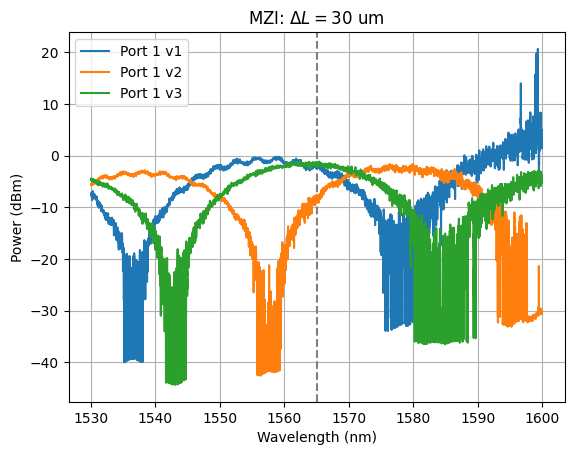

In [34]:
# Processing parameters
threshold = 3
separation = 30
dL = 30e-6

# Calculate FSR and group index
fsr_v1, ng_v1, indices_v1 = calculate_FSR(wavelength_mzi3_11_v1, power_mzi3_11_v1, threshold, separation, dL, plot=False)
fsr_v2, ng_v2, indices_v2 = calculate_FSR(wavelength_mzi3_11_v2, power_mzi3_11_v2, threshold, separation, dL, plot=False)
fsr_v3, ng_v3, indices_v3 = calculate_FSR(wavelength_mzi3_11_v3, power_mzi3_11_v3, threshold, separation, dL, plot=False)

fsr_mean = np.mean([fsr_v1, fsr_v2, fsr_v3])
ng_mean = mean_array([ng_v1, ng_v2, ng_v3])

print(f"FSR = {fsr_mean:.2f} nm")
print(f"ng = {ng_mean}")

indices = mean_array([indices_v1, indices_v2, indices_v3]).astype(int)

for i in range(len(indices) + 1):
    wl = wavelength_mzi3_11_v1[indices[0]] + (i-1/2)*fsr_mean
    wl_min = min(wavelength_mzi3_11_v1)
    wl_max = max(wavelength_mzi3_11_v1)
    
    if wl_min < wl < wl_max:
        plt.axvline(wl, color='gray', linestyle='--')


plt.plot(wavelength_mzi3_11_v1, power_mzi3_11_v1, label='Port 1 v1')
plt.plot(wavelength_mzi3_11_v2, power_mzi3_11_v2, label='Port 1 v2')
plt.plot(wavelength_mzi3_11_v3, power_mzi3_11_v3, label='Port 1 v3')

'''plt.plot(wavelength_mzi3_11_v1, power_mzi3_11_v1_fit, label='Port 1 v1')
plt.plot(wavelength_mzi3_11_v2, power_mzi3_11_v2_fit, label='Port 1 v2')
plt.plot(wavelength_mzi3_11_v3, power_mzi3_11_v3_fit, label='Port 1 v3')'''

plt.title(r'MZI: $\Delta L = 30$ um')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Power (dBm)')
plt.legend()
plt.grid()
plt.show()

In [23]:
## Center
wavelength_dut_center = wavelength_mzi3_11_v3 
power_dut_center = power_mzi3_11_v3 
indices_center = indices_v3
ng_center = ng_v3

## Right
wavelength_dut_right = wavelength_mzi3_11_v2
power_dut_right = power_mzi3_11_v2
indices_right = indices_v2

## Left
wavelength_dut_left = wavelength_mzi3_11_v1
power_dut_left = power_mzi3_11_v1
indices_left = indices_v1

## General
fsr = fsr_mean
plot = False

delta_lambda, delta_neff = refractive_indices(wavelength_dut_left, wavelength_dut_center, wavelength_dut_right, power_dut_left, power_dut_center, power_dut_right, indices_left, indices_center, indices_right, fsr, ng_center, plot)
print(f'Δn_eff = {delta_neff}')
print(f'Δlambda = {delta_lambda}')

Δn_eff = [0.01303478 0.01174925]
Δlambda = [10.603  9.305]


## MZI ΔL = 100 um

In [ ]:
# Common variables
dL = 100e-6

### Fitting

In [ ]:
## Output port 1, v1
threshold_dB = 20
wavelength_mzi4_11_v1_filter, power_mzi4_11_v1_filter, wavelength_noise, power_noise = surpress_noise(wavelength_mzi4_11_v1, power_mzi4_11_v1, window_size = 0.1, threshold_dB = threshold_dB, plot=True)

power_mzi4_11_v1_fit, popt_mzi4_11_v1 = cosine_fit(wavelength_mzi4_11_v1, power_mzi4_11_v1, dL)
power_mzi4_11_v1_fit_2, popt_mzi4_11_v1_2 = cosine_fit(wavelength_mzi4_11_v1_filter, power_mzi4_11_v1_filter, dL, wavelength_out = wavelength_mzi4_11_v1)

fig, ax = plt.subplots(2,2, figsize=(12, 8))

ax[0, 0].plot(wavelength_mzi4_11_v1, power_mzi4_11_v1, label = 'Original')
ax[0, 0].plot(wavelength_mzi4_11_v1, power_mzi4_11_v1_fit, label='Fit')
ax[0, 0].set_xlabel('Wavelength (nm)')   
ax[0, 0].set_ylabel('Power (dBm)')
ax[0, 0].set_title('Fit with Original Data (dB Scale)')
ax[0, 0].legend()
ax[0, 0].grid()

ax[0, 1].plot(wavelength_mzi4_11_v1, 10**(power_mzi4_11_v1/10), label = 'Original')
ax[0, 1].plot(wavelength_mzi4_11_v1, 10**(power_mzi4_11_v1_fit/10), label='Fit')
ax[0, 1].set_ylim(0, 1)
ax[0, 1].set_xlabel('Wavelength (nm)')   
ax[0, 1].set_ylabel('Power (mW)')
ax[0, 1].set_title('Fit with Original Data (Linear Scale)')
ax[0, 1].legend()
ax[0, 1].grid()

ax[1, 0].plot(wavelength_mzi4_11_v1, power_mzi4_11_v1, label = 'Original')
ax[1, 0].plot(wavelength_mzi4_11_v1, power_mzi4_11_v1_fit_2, label='Fit')
ax[1, 0].set_xlabel('Wavelength (nm)')   
ax[1, 0].set_ylabel('Power (dBm)')
ax[1, 0].set_title('Fit with Truncated Data (dB Scale)')
ax[1, 0].legend()
ax[1, 0].grid()

ax[1, 1].plot(wavelength_mzi4_11_v1, 10**(power_mzi4_11_v1/10), label = 'Original')
ax[1, 1].plot(wavelength_mzi4_11_v1, 10**(power_mzi4_11_v1_fit_2/10), label='Fit')
ax[1, 1].set_ylim(0, 1)
ax[1, 1].set_xlabel('Wavelength (nm)')   
ax[1, 1].set_ylabel('Power (mW)')
ax[1, 1].set_title('Fit with Truncated Data (Linear Scale)')
ax[1, 1].legend()
ax[1, 1].grid()

plt.tight_layout()
plt.show()

NameError: name 'wavelength_mzi4_11_v1' is not defined

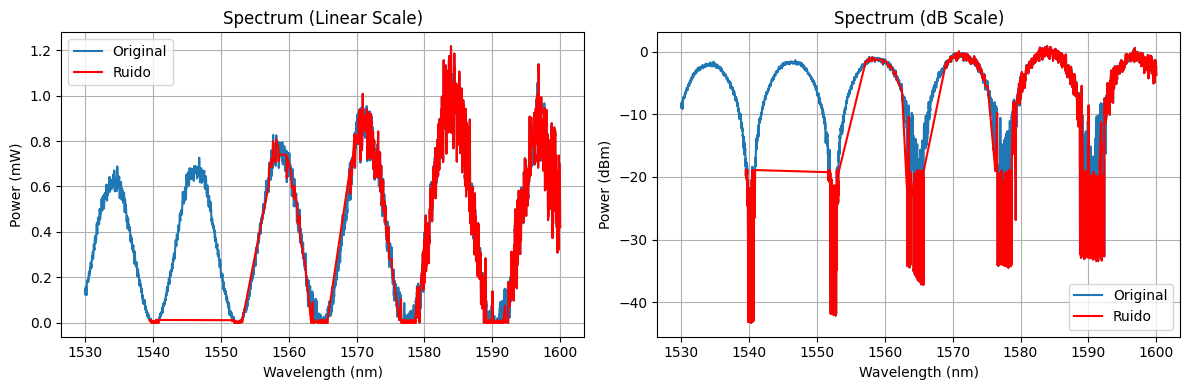

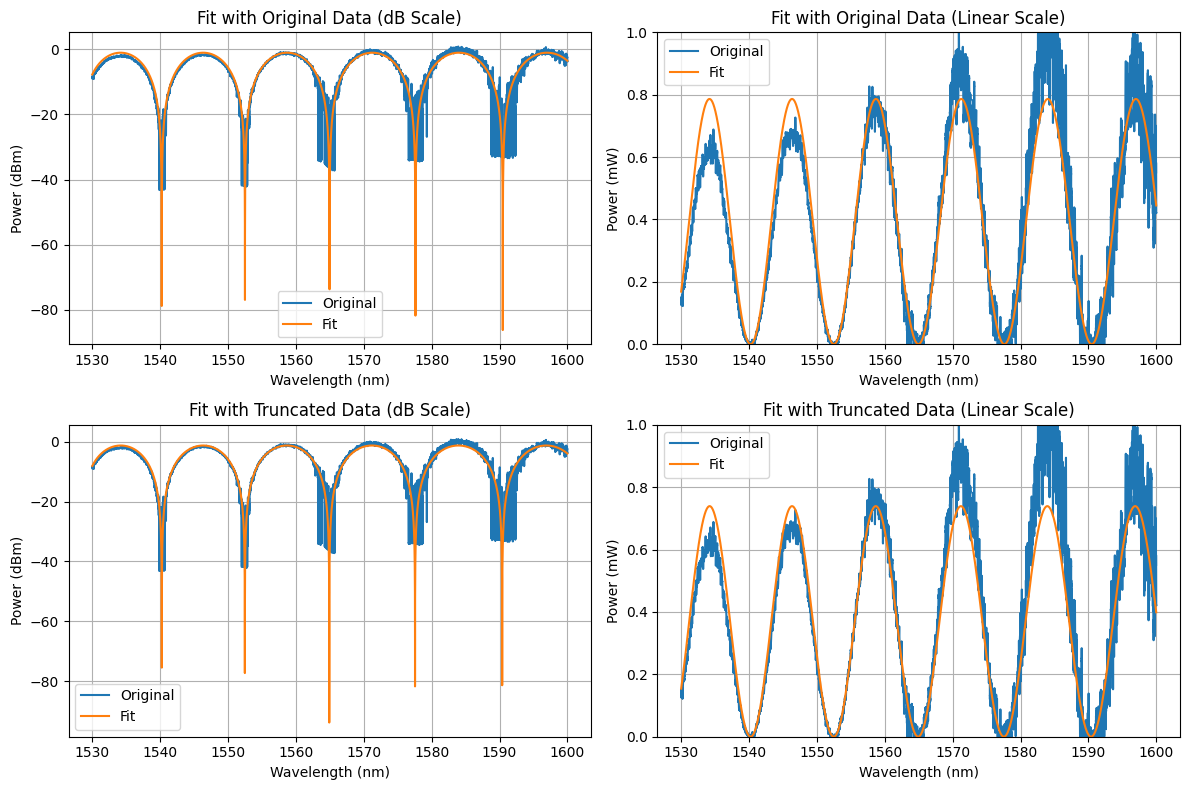

In [ ]:
## Output port 1, v2
threshold_dB = 20
wavelength_mzi4_11_v2_filter, power_mzi4_11_v2_filter, wavelength_noise, power_noise = surpress_noise(wavelength_mzi4_11_v2, power_mzi4_11_v2, window_size = 0.1, threshold_dB = threshold_dB, plot=True)

power_mzi4_11_v2_fit, popt_mzi4_11_v2 = cosine_fit(wavelength_mzi4_11_v2, power_mzi4_11_v2, dL)
power_mzi4_11_v2_fit_2, popt_mzi4_11_v2_2 = cosine_fit(wavelength_mzi4_11_v2_filter, power_mzi4_11_v2_filter, dL, wavelength_out = wavelength_mzi4_11_v2)

fig, ax = plt.subplots(2,2, figsize=(12, 8))

ax[0, 0].plot(wavelength_mzi4_11_v2, power_mzi4_11_v2, label = 'Original')
ax[0, 0].plot(wavelength_mzi4_11_v2, power_mzi4_11_v2_fit, label='Fit')
ax[0, 0].set_xlabel('Wavelength (nm)')   
ax[0, 0].set_ylabel('Power (dBm)')
ax[0, 0].set_title('Fit with Original Data (dB Scale)')
ax[0, 0].legend()
ax[0, 0].grid()

ax[0, 1].plot(wavelength_mzi4_11_v2, 10**(power_mzi4_11_v2/10), label = 'Original')
ax[0, 1].plot(wavelength_mzi4_11_v2, 10**(power_mzi4_11_v2_fit/10), label='Fit')
ax[0, 1].set_ylim(0, 1)
ax[0, 1].set_xlabel('Wavelength (nm)')   
ax[0, 1].set_ylabel('Power (mW)')
ax[0, 1].set_title('Fit with Original Data (Linear Scale)')
ax[0, 1].legend()
ax[0, 1].grid()

ax[1, 0].plot(wavelength_mzi4_11_v2, power_mzi4_11_v2, label = 'Original')
ax[1, 0].plot(wavelength_mzi4_11_v2, power_mzi4_11_v2_fit_2, label='Fit')
ax[1, 0].set_xlabel('Wavelength (nm)')   
ax[1, 0].set_ylabel('Power (dBm)')
ax[1, 0].set_title('Fit with Truncated Data (dB Scale)')
ax[1, 0].legend()
ax[1, 0].grid()

ax[1, 1].plot(wavelength_mzi4_11_v2, 10**(power_mzi4_11_v2/10), label = 'Original')
ax[1, 1].plot(wavelength_mzi4_11_v2, 10**(power_mzi4_11_v2_fit_2/10), label='Fit')
ax[1, 1].set_ylim(0, 1)
ax[1, 1].set_xlabel('Wavelength (nm)')   
ax[1, 1].set_ylabel('Power (mW)')
ax[1, 1].set_title('Fit with Truncated Data (Linear Scale)')
ax[1, 1].legend()
ax[1, 1].grid()

plt.tight_layout()
plt.show()

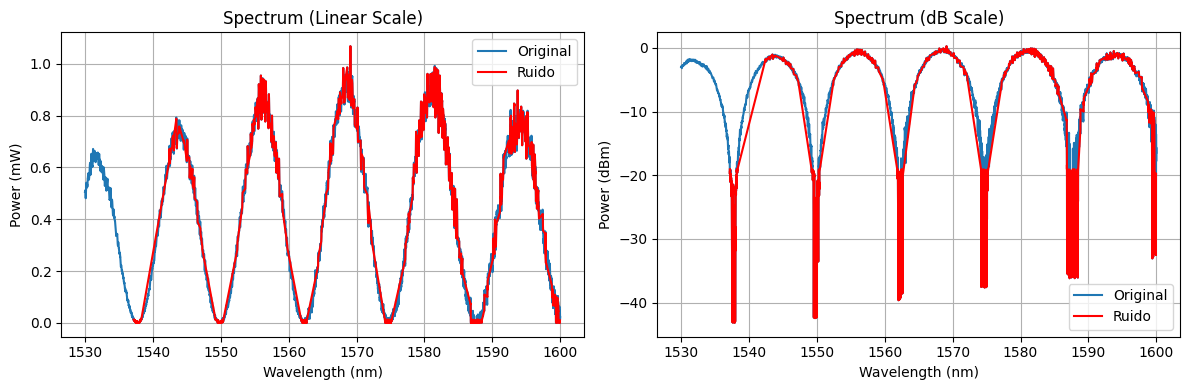

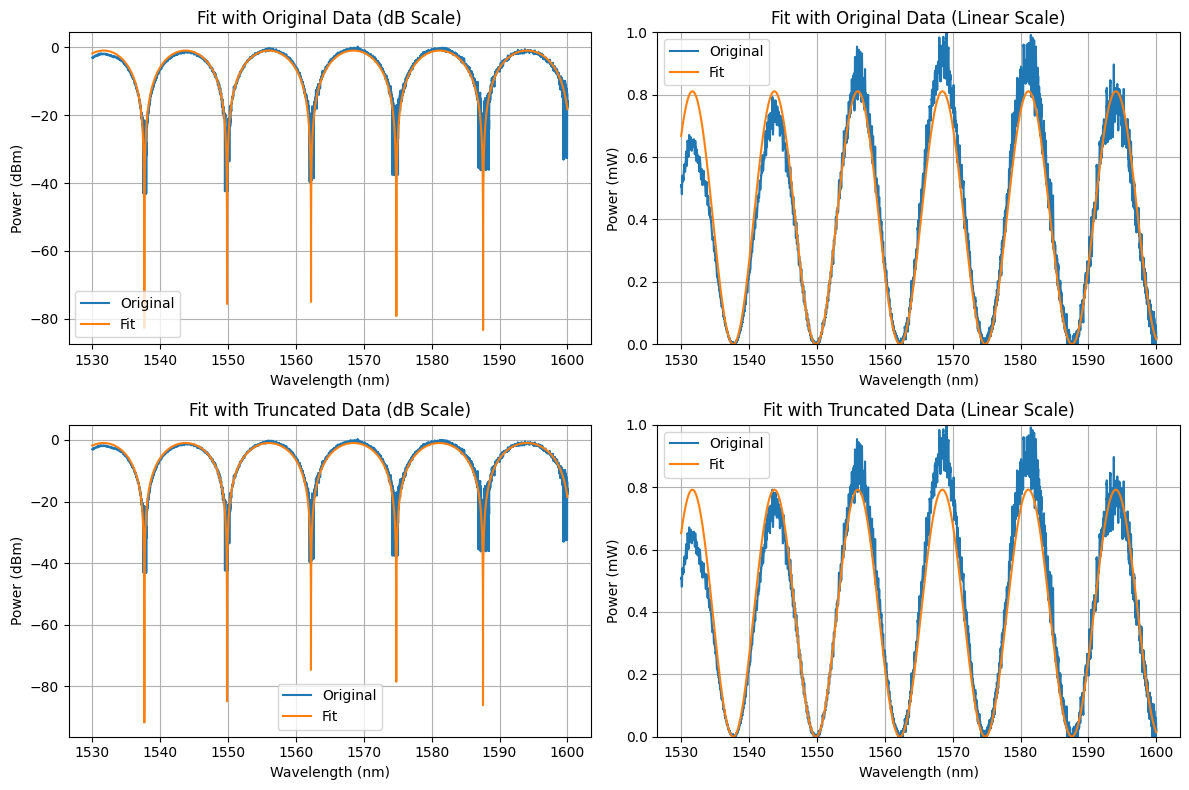

In [ ]:
## Output port 1, v3
threshold_dB = 20
wavelength_mzi4_11_v3_filter, power_mzi4_11_v3_filter, wavelength_noise, power_noise = surpress_noise(wavelength_mzi4_11_v3, power_mzi4_11_v3, window_size = 0.1, threshold_dB = threshold_dB, plot=True)

power_mzi4_11_v3_fit, popt_mzi4_11_v3 = cosine_fit(wavelength_mzi4_11_v3, power_mzi4_11_v3, dL)
power_mzi4_11_v3_fit_2, popt_mzi4_11_v3_2 = cosine_fit(wavelength_mzi4_11_v3_filter, power_mzi4_11_v3_filter, dL, wavelength_out = wavelength_mzi4_11_v3)

fig, ax = plt.subplots(2,2, figsize=(12, 8))

ax[0, 0].plot(wavelength_mzi4_11_v3, power_mzi4_11_v3, label = 'Original')
ax[0, 0].plot(wavelength_mzi4_11_v3, power_mzi4_11_v3_fit, label=f'Fit')
ax[0, 0].set_xlabel('Wavelength (nm)')   
ax[0, 0].set_ylabel('Power (dBm)')
ax[0, 0].set_title('Fit with Original Data (dB Scale)')
ax[0, 0].legend()
ax[0, 0].grid()

ax[0, 1].plot(wavelength_mzi4_11_v3, 10**(power_mzi4_11_v3/10), label = 'Original')
ax[0, 1].plot(wavelength_mzi4_11_v3, 10**(power_mzi4_11_v3_fit/10), label=f'Fit')
ax[0, 1].set_ylim(0, 1)
ax[0, 1].set_xlabel('Wavelength (nm)')   
ax[0, 1].set_ylabel('Power (mW)')
ax[0, 1].set_title('Fit with Original Data (Linear Scale)')
ax[0, 1].legend()
ax[0, 1].grid()

ax[1, 0].plot(wavelength_mzi4_11_v3, power_mzi4_11_v3, label = 'Original')
ax[1, 0].plot(wavelength_mzi4_11_v3, power_mzi4_11_v3_fit_2, label=f'Fit')
ax[1, 0].set_xlabel('Wavelength (nm)')   
ax[1, 0].set_ylabel('Power (dBm)')
ax[1, 0].set_title('Fit with Truncated Data (dB Scale)')
ax[1, 0].legend()
ax[1, 0].grid()

ax[1, 1].plot(wavelength_mzi4_11_v3, 10**(power_mzi4_11_v3/10), label = 'Original')
ax[1, 1].plot(wavelength_mzi4_11_v3, 10**(power_mzi4_11_v3_fit_2/10), label=f'Fit')
ax[1, 1].set_ylim(0, 1)
ax[1, 1].set_xlabel('Wavelength (nm)')   
ax[1, 1].set_ylabel('Power (mW)')
ax[1, 1].set_title('Fit with Truncated Data (Linear Scale)')
ax[1, 1].legend()
ax[1, 1].grid()

plt.tight_layout()
plt.show()

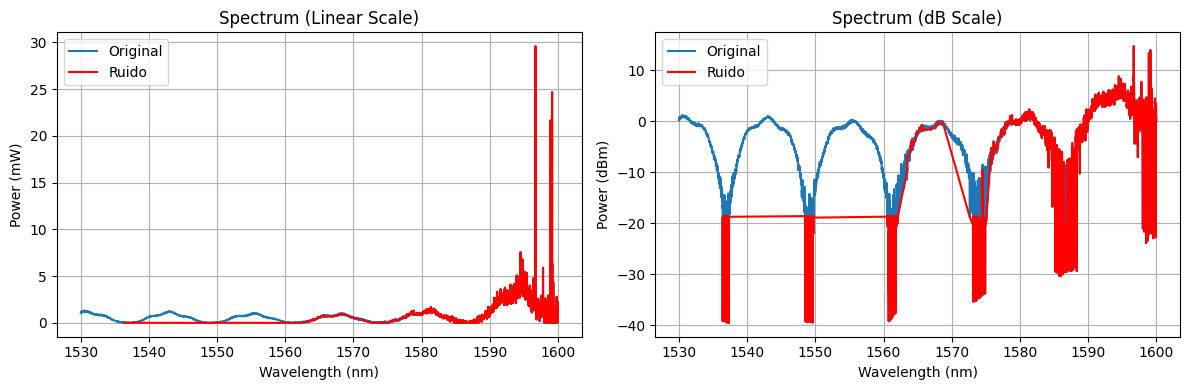

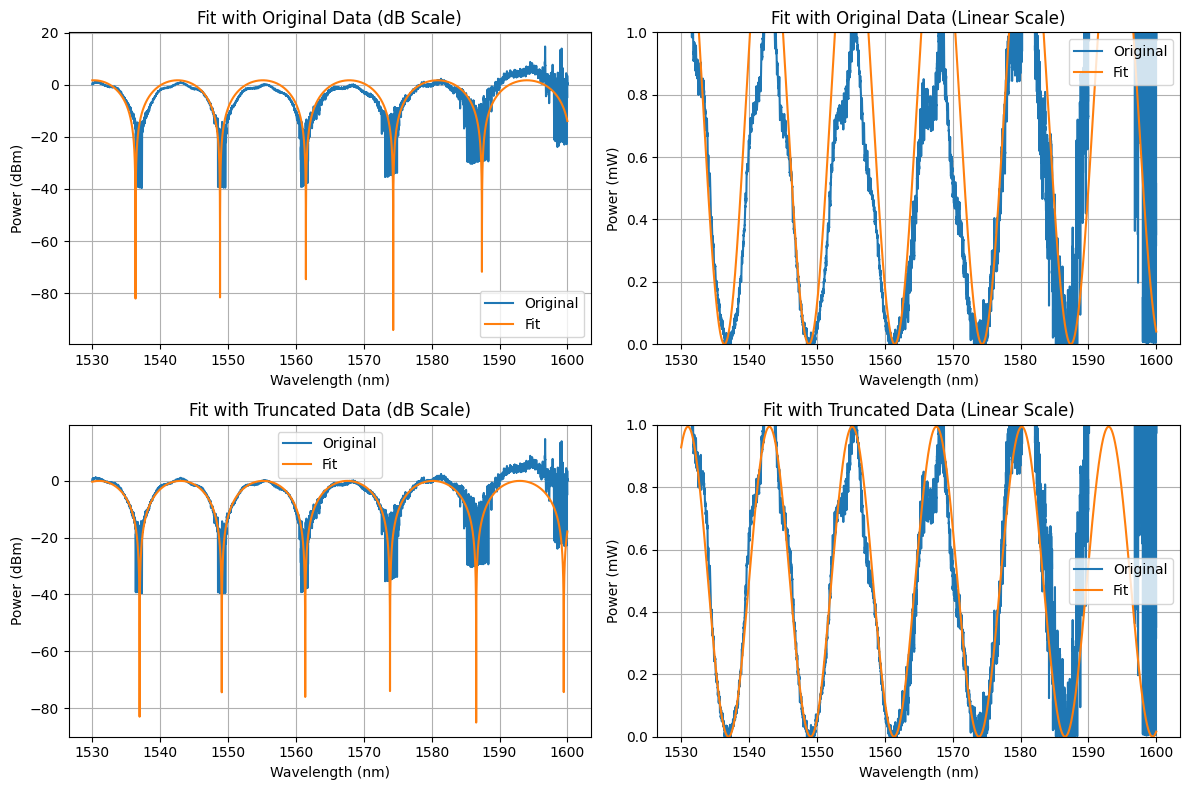

In [ ]:
## Output port 2, v1
threshold_dB = 20
wavelength_mzi4_12_v1_filter, power_mzi4_12_v1_filter, wavelength_noise, power_noise = surpress_noise(wavelength_mzi4_12_v1, power_mzi4_12_v1, window_size = 0.1, threshold_dB = threshold_dB, plot=True)

power_mzi4_12_v1_fit, popt_mzi4_12_v1 = cosine_fit(wavelength_mzi4_12_v1, power_mzi4_12_v1, dL)
power_mzi4_12_v1_fit_2, popt_mzi4_12_v1_2 = cosine_fit(wavelength_mzi4_12_v1_filter, power_mzi4_12_v1_filter, dL, wavelength_out = wavelength_mzi4_12_v1)

fig, ax = plt.subplots(2,2, figsize=(12, 8))

ax[0, 0].plot(wavelength_mzi4_12_v1, power_mzi4_12_v1, label = 'Original')
ax[0, 0].plot(wavelength_mzi4_12_v1, power_mzi4_12_v1_fit, label=f'Fit')
ax[0, 0].set_xlabel('Wavelength (nm)')   
ax[0, 0].set_ylabel('Power (dBm)')
ax[0, 0].set_title('Fit with Original Data (dB Scale)')
ax[0, 0].legend()
ax[0, 0].grid()

ax[0, 1].plot(wavelength_mzi4_12_v1, 10**(power_mzi4_12_v1/10), label = 'Original')
ax[0, 1].plot(wavelength_mzi4_12_v1, 10**(power_mzi4_12_v1_fit/10), label=f'Fit')
ax[0, 1].set_ylim(0, 1)
ax[0, 1].set_xlabel('Wavelength (nm)')   
ax[0, 1].set_ylabel('Power (mW)')
ax[0, 1].set_title('Fit with Original Data (Linear Scale)')
ax[0, 1].legend()
ax[0, 1].grid()

ax[1, 0].plot(wavelength_mzi4_12_v1, power_mzi4_12_v1, label = 'Original')
ax[1, 0].plot(wavelength_mzi4_12_v1, power_mzi4_12_v1_fit_2, label=f'Fit')
ax[1, 0].set_xlabel('Wavelength (nm)')   
ax[1, 0].set_ylabel('Power (dBm)')
ax[1, 0].set_title('Fit with Truncated Data (dB Scale)')
ax[1, 0].legend()
ax[1, 0].grid()

ax[1, 1].plot(wavelength_mzi4_12_v1, 10**(power_mzi4_12_v1/10), label = 'Original')
ax[1, 1].plot(wavelength_mzi4_12_v1, 10**(power_mzi4_12_v1_fit_2/10), label=f'Fit')
ax[1, 1].set_ylim(0, 1)
ax[1, 1].set_xlabel('Wavelength (nm)')   
ax[1, 1].set_ylabel('Power (mW)')
ax[1, 1].set_title('Fit with Truncated Data (Linear Scale)')
ax[1, 1].legend()
ax[1, 1].grid()

plt.tight_layout()
plt.show()

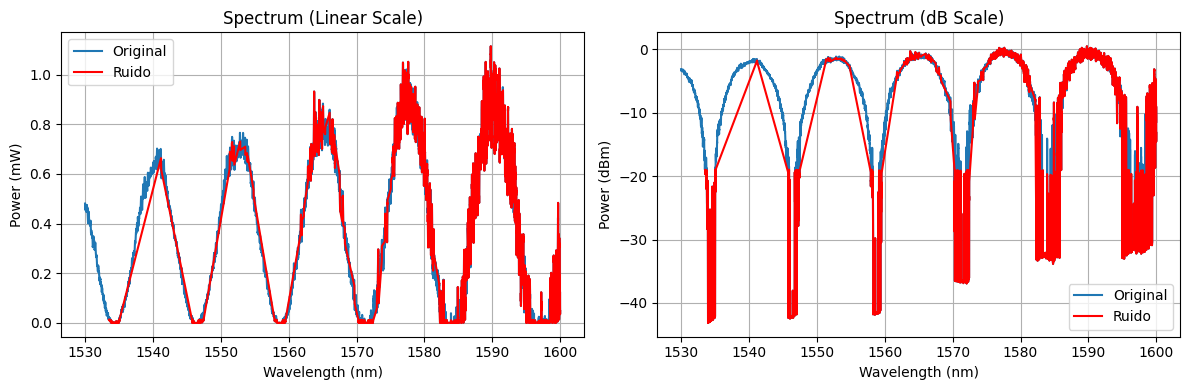

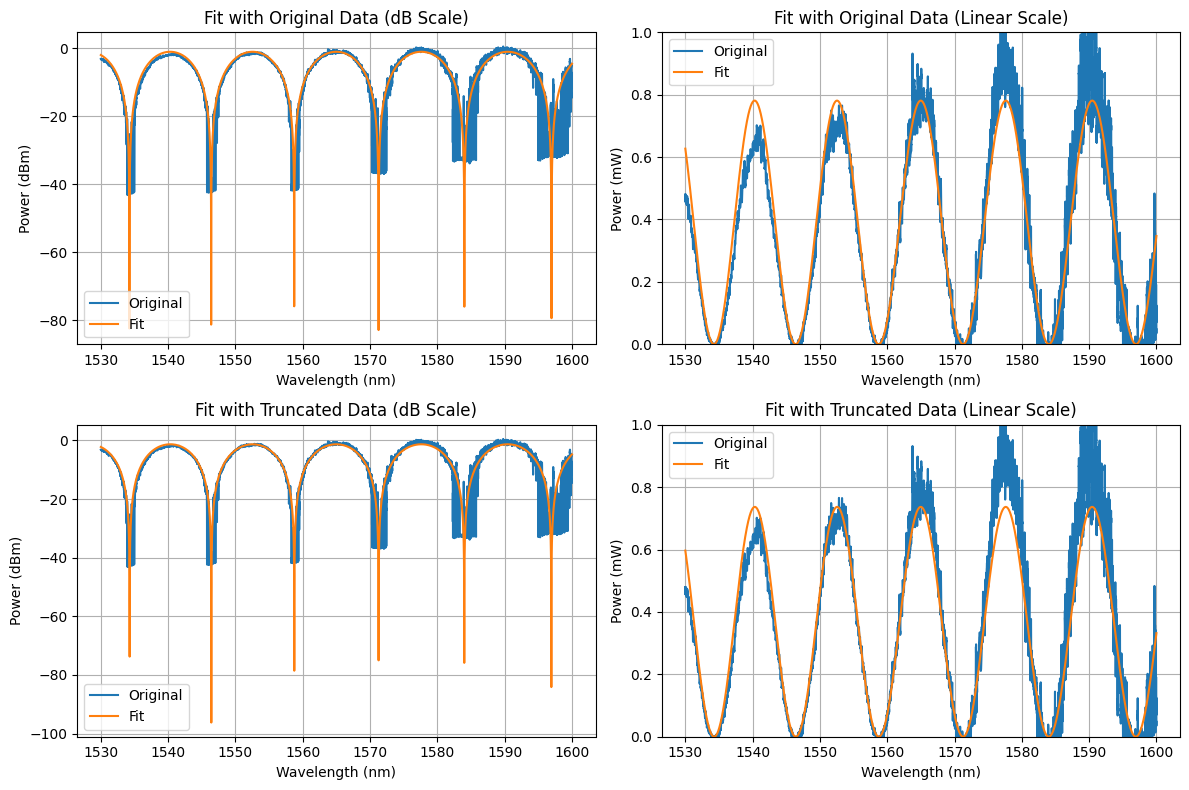

In [ ]:
## Output port 2, v2
threshold_dB = 20
wavelength_mzi4_12_v2_filter, power_mzi4_12_v2_filter, wavelength_noise, power_noise = surpress_noise(wavelength_mzi4_12_v2, power_mzi4_12_v2, window_size = 0.1, threshold_dB = threshold_dB, plot=True)

power_mzi4_12_v2_fit, popt_mzi4_12_v2 = cosine_fit(wavelength_mzi4_12_v2, power_mzi4_12_v2, dL)
power_mzi4_12_v2_fit_2, popt_mzi4_12_v2_2 = cosine_fit(wavelength_mzi4_12_v2_filter, power_mzi4_12_v2_filter, dL, wavelength_out = wavelength_mzi4_12_v2)

fig, ax = plt.subplots(2,2, figsize=(12, 8))

ax[0, 0].plot(wavelength_mzi4_12_v2, power_mzi4_12_v2, label = 'Original')
ax[0, 0].plot(wavelength_mzi4_12_v2, power_mzi4_12_v2_fit, label='Fit')
ax[0, 0].set_xlabel('Wavelength (nm)')   
ax[0, 0].set_ylabel('Power (dBm)')
ax[0, 0].set_title('Fit with Original Data (dB Scale)')
ax[0, 0].legend()
ax[0, 0].grid()

ax[0, 1].plot(wavelength_mzi4_12_v2, 10**(power_mzi4_12_v2/10), label = 'Original')
ax[0, 1].plot(wavelength_mzi4_12_v2, 10**(power_mzi4_12_v2_fit/10), label='Fit')
ax[0, 1].set_ylim(0, 1)
ax[0, 1].set_xlabel('Wavelength (nm)')   
ax[0, 1].set_ylabel('Power (mW)')
ax[0, 1].set_title('Fit with Original Data (Linear Scale)')
ax[0, 1].legend()
ax[0, 1].grid()

ax[1, 0].plot(wavelength_mzi4_12_v2, power_mzi4_12_v2, label = 'Original')
ax[1, 0].plot(wavelength_mzi4_12_v2, power_mzi4_12_v2_fit_2, label='Fit')
ax[1, 0].set_xlabel('Wavelength (nm)')   
ax[1, 0].set_ylabel('Power (dBm)')
ax[1, 0].set_title('Fit with Truncated Data (dB Scale)')
ax[1, 0].legend()
ax[1, 0].grid()

ax[1, 1].plot(wavelength_mzi4_12_v2, 10**(power_mzi4_12_v2/10), label = 'Original')
ax[1, 1].plot(wavelength_mzi4_12_v2, 10**(power_mzi4_12_v2_fit_2/10), label='Fit')
ax[1, 1].set_ylim(0, 1)
ax[1, 1].set_xlabel('Wavelength (nm)')   
ax[1, 1].set_ylabel('Power (mW)')
ax[1, 1].set_title('Fit with Truncated Data (Linear Scale)')
ax[1, 1].legend()
ax[1, 1].grid()

plt.tight_layout()
plt.show()

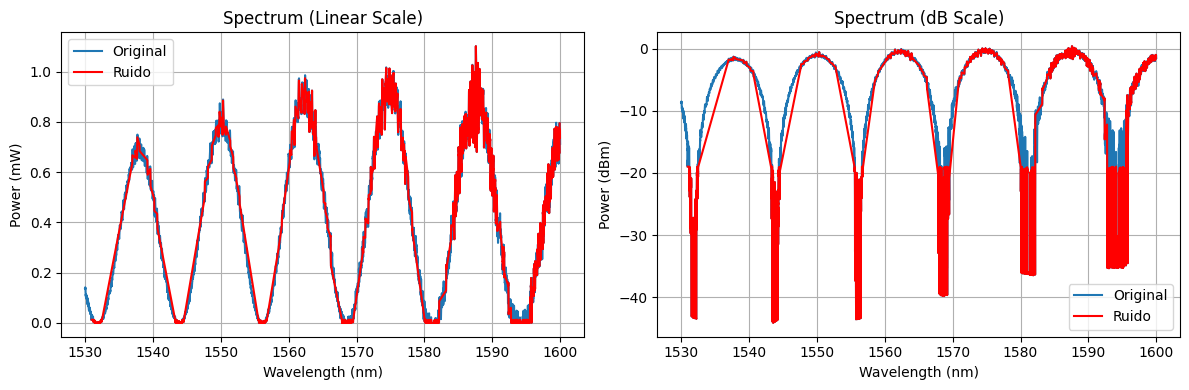

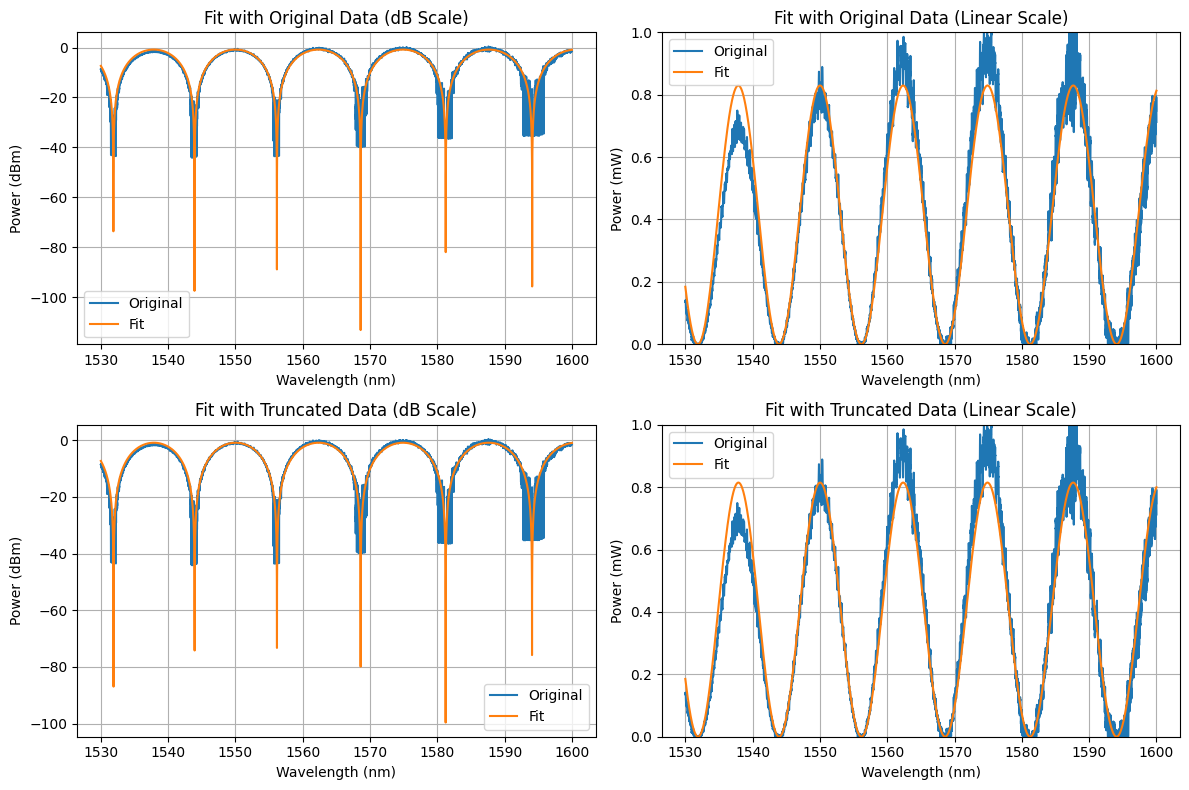

In [ ]:
## Output port 2, v3
threshold_dB = 20
wavelength_mzi4_12_v3_filter, power_mzi4_12_v3_filter, wavelength_noise, power_noise = surpress_noise(wavelength_mzi4_12_v3, power_mzi4_12_v3, window_size = 0.1, threshold_dB = threshold_dB, plot=True)

power_mzi4_12_v3_fit, popt_mzi4_12_v3 = cosine_fit(wavelength_mzi4_12_v3, power_mzi4_12_v3, dL)
power_mzi4_12_v3_fit_2, popt_mzi4_12_v3_2 = cosine_fit(wavelength_mzi4_12_v3_filter, power_mzi4_12_v3_filter, dL, wavelength_out = wavelength_mzi4_12_v3)

fig, ax = plt.subplots(2,2, figsize=(12, 8))

ax[0, 0].plot(wavelength_mzi4_12_v3, power_mzi4_12_v3, label = 'Original')
ax[0, 0].plot(wavelength_mzi4_12_v3, power_mzi4_12_v3_fit, label=f'Fit')
ax[0, 0].set_xlabel('Wavelength (nm)')   
ax[0, 0].set_ylabel('Power (dBm)')
ax[0, 0].set_title('Fit with Original Data (dB Scale)')
ax[0, 0].legend()
ax[0, 0].grid()

ax[0, 1].plot(wavelength_mzi4_12_v3, 10**(power_mzi4_12_v3/10), label = 'Original')
ax[0, 1].plot(wavelength_mzi4_12_v3, 10**(power_mzi4_12_v3_fit/10), label=f'Fit')
ax[0, 1].set_ylim(0, 1)
ax[0, 1].set_xlabel('Wavelength (nm)')   
ax[0, 1].set_ylabel('Power (mW)')
ax[0, 1].set_title('Fit with Original Data (Linear Scale)')
ax[0, 1].legend()
ax[0, 1].grid()

ax[1, 0].plot(wavelength_mzi4_12_v3, power_mzi4_12_v3, label = 'Original')
ax[1, 0].plot(wavelength_mzi4_12_v3, power_mzi4_12_v3_fit_2, label=f'Fit')
ax[1, 0].set_xlabel('Wavelength (nm)')   
ax[1, 0].set_ylabel('Power (dBm)')
ax[1, 0].set_title('Fit with Truncated Data (dB Scale)')
ax[1, 0].legend()
ax[1, 0].grid()

ax[1, 1].plot(wavelength_mzi4_12_v3, 10**(power_mzi4_12_v3/10), label = 'Original')
ax[1, 1].plot(wavelength_mzi4_12_v3, 10**(power_mzi4_12_v3_fit_2/10), label=f'Fit')
ax[1, 1].set_ylim(0, 1)
ax[1, 1].set_xlabel('Wavelength (nm)')   
ax[1, 1].set_ylabel('Power (mW)')
ax[1, 1].set_title('Fit with Truncated Data (Linear Scale)')
ax[1, 1].legend()
ax[1, 1].grid()

plt.tight_layout()
plt.show()

### Absolute Dephase

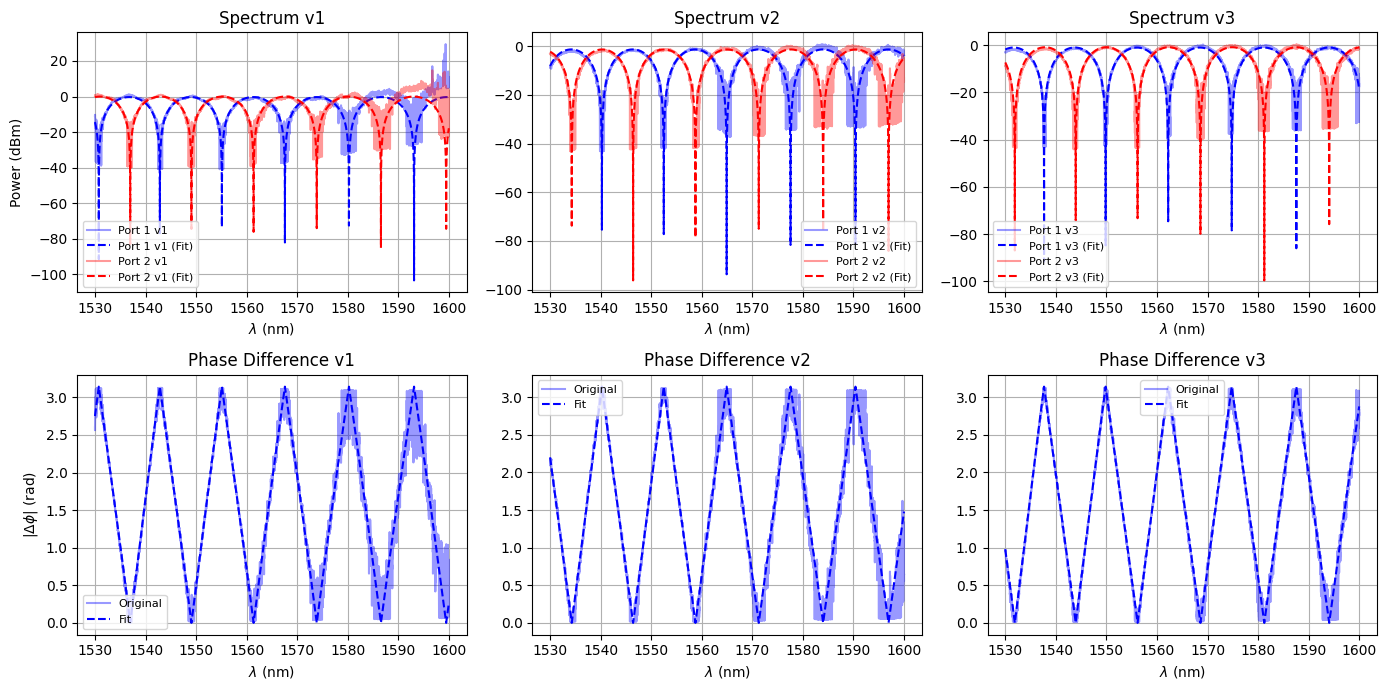

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(14, 7))

axs[0, 0].plot(wavelength_mzi4_11_v1, power_mzi4_11_v1, label='Port 1 v1', alpha=0.4, color='blue')
axs[0, 0].plot(wavelength_mzi4_11_v1, power_mzi4_11_v1_fit_2, label='Port 1 v1 (Fit)', color='blue', linestyle='--')
axs[0, 0].plot(wavelength_mzi4_12_v1, power_mzi4_12_v1, label='Port 2 v1', alpha=0.4, color='red')
axs[0, 0].plot(wavelength_mzi4_12_v1, power_mzi4_12_v1_fit_2, label='Port 2 v1 (Fit)', color='red', linestyle='--')
axs[0, 0].set_title('Spectrum v1')
axs[0, 0].set_xlabel(r'$\lambda$ (nm)')
axs[0, 0].set_ylabel('Power (dBm)')
axs[0, 0].grid()
axs[0, 0].legend(fontsize=8)

axs[0, 1].plot(wavelength_mzi4_11_v2, power_mzi4_11_v2, label='Port 1 v2', alpha=0.4, color='blue')
axs[0, 1].plot(wavelength_mzi4_11_v2, power_mzi4_11_v2_fit_2, label='Port 1 v2 (Fit)', color='blue', linestyle='--')
axs[0, 1].plot(wavelength_mzi4_12_v2, power_mzi4_12_v2, label='Port 2 v2', alpha=0.4, color='red')
axs[0, 1].plot(wavelength_mzi4_12_v2, power_mzi4_12_v2_fit_2, label='Port 2 v2 (Fit)', color='red', linestyle='--')
axs[0, 1].set_title('Spectrum v2')
axs[0, 1].set_xlabel(r'$\lambda$ (nm)')
axs[0, 1].grid()
axs[0, 1].legend(fontsize=8)

axs[0, 2].plot(wavelength_mzi4_11_v3, power_mzi4_11_v3, label='Port 1 v3', alpha=0.4, color='blue')
axs[0, 2].plot(wavelength_mzi4_11_v3, power_mzi4_11_v3_fit_2, label='Port 1 v3 (Fit)', color='blue', linestyle='--')
axs[0, 2].plot(wavelength_mzi4_12_v3, power_mzi4_12_v3, label='Port 2 v3', alpha=0.4, color='red')
axs[0, 2].plot(wavelength_mzi4_12_v3, power_mzi4_12_v3_fit_2, label='Port 2 v3 (Fit)', color='red', linestyle='--')
axs[0, 2].set_title('Spectrum v3')
axs[0, 2].set_xlabel(r'$\lambda$ (nm)')
axs[0, 2].grid()
axs[0, 2].legend(fontsize=8)

delta_phi_v1 = ideal_dephase(wavelength_mzi4_11_v1, power_mzi4_11_v1, power_mzi4_12_v1)
delta_phi_v2 = ideal_dephase(wavelength_mzi4_11_v2, power_mzi4_11_v2, power_mzi4_12_v2)
delta_phi_v3 = ideal_dephase(wavelength_mzi4_11_v3, power_mzi4_11_v3, power_mzi4_12_v3)

delta_phi_v1_fit = ideal_dephase(wavelength_mzi4_11_v1, power_mzi4_11_v1_fit_2, power_mzi4_12_v1_fit_2)
delta_phi_v2_fit = ideal_dephase(wavelength_mzi4_11_v2, power_mzi4_11_v2_fit_2, power_mzi4_12_v2_fit_2)
delta_phi_v3_fit = ideal_dephase(wavelength_mzi4_11_v3, power_mzi4_11_v3_fit_2, power_mzi4_12_v3_fit_2)

axs[1, 0].plot(wavelength_mzi4_11_v1, delta_phi_v1, label='Original', alpha=0.4, color='blue')
axs[1, 0].plot(wavelength_mzi4_11_v1, delta_phi_v1_fit, label='Fit', color='blue', linestyle='--')
axs[1, 0].set_title('Phase Difference v1')
axs[1, 0].set_xlabel(r'$\lambda$ (nm)')
axs[1, 0].set_ylabel(r'$|\Delta \phi|$ (rad)')
axs[1, 0].legend(fontsize=8)
axs[1, 0].grid()

axs[1, 1].plot(wavelength_mzi4_11_v2, delta_phi_v2, label='Original', alpha=0.4, color='blue')
axs[1, 1].plot(wavelength_mzi4_11_v2, delta_phi_v2_fit, label='Fit', color='blue', linestyle='--')
axs[1, 1].set_title('Phase Difference v2')
axs[1, 1].set_xlabel(r'$\lambda$ (nm)')
axs[1, 1].legend(fontsize=8)
axs[1, 1].grid()

axs[1, 2].plot(wavelength_mzi4_11_v3, delta_phi_v3, label='Original', alpha=0.4, color='blue')
axs[1, 2].plot(wavelength_mzi4_11_v3, delta_phi_v3_fit, label='Fit', color='blue', linestyle='--')
axs[1, 2].set_title('Phase Difference v3')
axs[1, 2].set_xlabel(r'$\lambda$ (nm)')
axs[1, 2].legend(fontsize=8)
axs[1, 2].grid()

#plt.suptitle(r'MZI: $\Delta L = 0$ um', fontsize=14)
plt.tight_layout()
plt.show()

### Refractive Index Estimation

FSR = 12.45 nm
ng = [1.90615343 1.93617766 1.96697103 1.99858546 2.03173732]


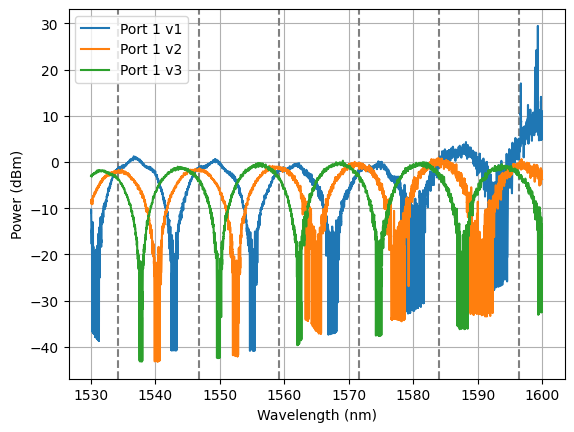

In [ ]:
# Processing parameters
threshold = 3
separation = 10
dL = 100e-6

# Calculate FSR and group index
fsr_v1, ng_v1, indices_v1 = calculate_FSR(wavelength_mzi4_11_v1, power_mzi4_11_v1, threshold, separation, dL, plot=False)
fsr_v2, ng_v2, indices_v2 = calculate_FSR(wavelength_mzi4_11_v2, power_mzi4_11_v2, threshold, separation, dL, plot=False)
fsr_v3, ng_v3, indices_v3 = calculate_FSR(wavelength_mzi4_11_v3, power_mzi4_11_v3, threshold, separation, dL, plot=False)

ng_v1 = ng_v1[1:]
indices_v1 = indices_v1[1:]
ng_v3 = ng_v3[:-1]
indices_v3 = indices_v3[:-1]

fsr_mean = np.mean([fsr_v1, fsr_v2, fsr_v3])
ng_mean = mean_array([ng_v1, ng_v2, ng_v3])

print(f"FSR = {fsr_mean:.2f} nm")
print(f"ng = {ng_mean}")

indices = mean_array([indices_v1, indices_v2, indices_v3]).astype(int)

for i in range(len(indices) + 1):
    wl = wavelength_mzi4_11_v1[indices[0]] + (i-1/2)*fsr_mean
    wl_min = min(wavelength_mzi4_11_v1)
    wl_max = max(wavelength_mzi4_11_v1)
    
    if wl_min < wl < wl_max:
        plt.axvline(wl, color='gray', linestyle='--')

plt.plot(wavelength_mzi4_11_v1, power_mzi4_11_v1, label='Port 1 v1')
plt.plot(wavelength_mzi4_11_v2, power_mzi4_11_v2, label='Port 1 v2')
plt.plot(wavelength_mzi4_11_v3, power_mzi4_11_v3, label='Port 1 v3')

plt.xlabel('Wavelength (nm)')
plt.ylabel('Power (dBm)')
plt.legend()
plt.grid()
plt.show()

In [ ]:
## Center
wavelength_dut_center = wavelength_mzi4_11_v2 
power_dut_center = power_mzi4_11_v2 
indices_center = indices_v2
ng_center = ng_v2

## Right
wavelength_dut_right = wavelength_mzi4_11_v1
power_dut_right = power_mzi4_11_v1
indices_right = indices_v1

## Left
wavelength_dut_left = wavelength_mzi4_11_v3
power_dut_left = power_mzi4_11_v3
indices_left = indices_v3

## General
fsr = fsr_mean
plot = False

delta_lambda, delta_neff = refractive_indices(wavelength_dut_right, wavelength_dut_center, wavelength_dut_left, power_dut_right, power_dut_center, power_dut_left, indices_right, indices_center, indices_left, fsr, ng_center, plot)
print(f'Δn_eff = {delta_neff}')

Δn_eff = [0.00319589 0.00330671 0.00295195 0.00278661 0.00332435]


## MZI ΔL = 210 um

In [24]:
# Common variables
dL = 210e-6

### Fitting

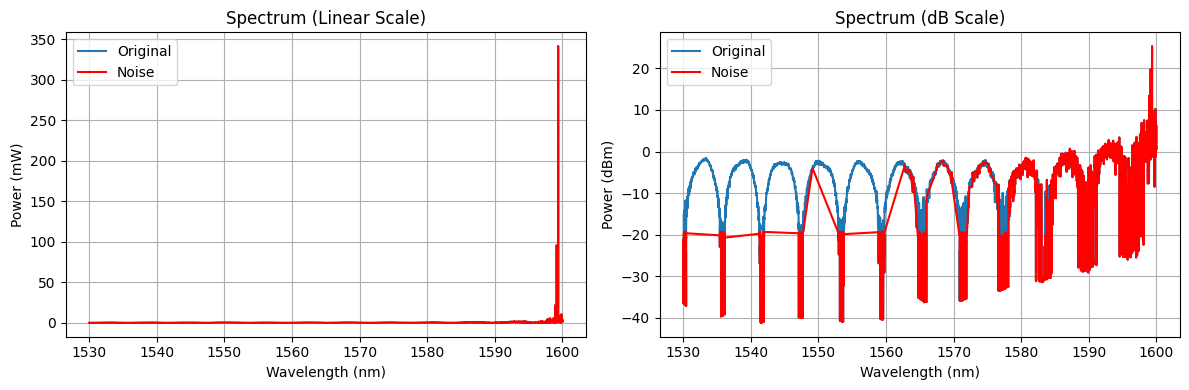

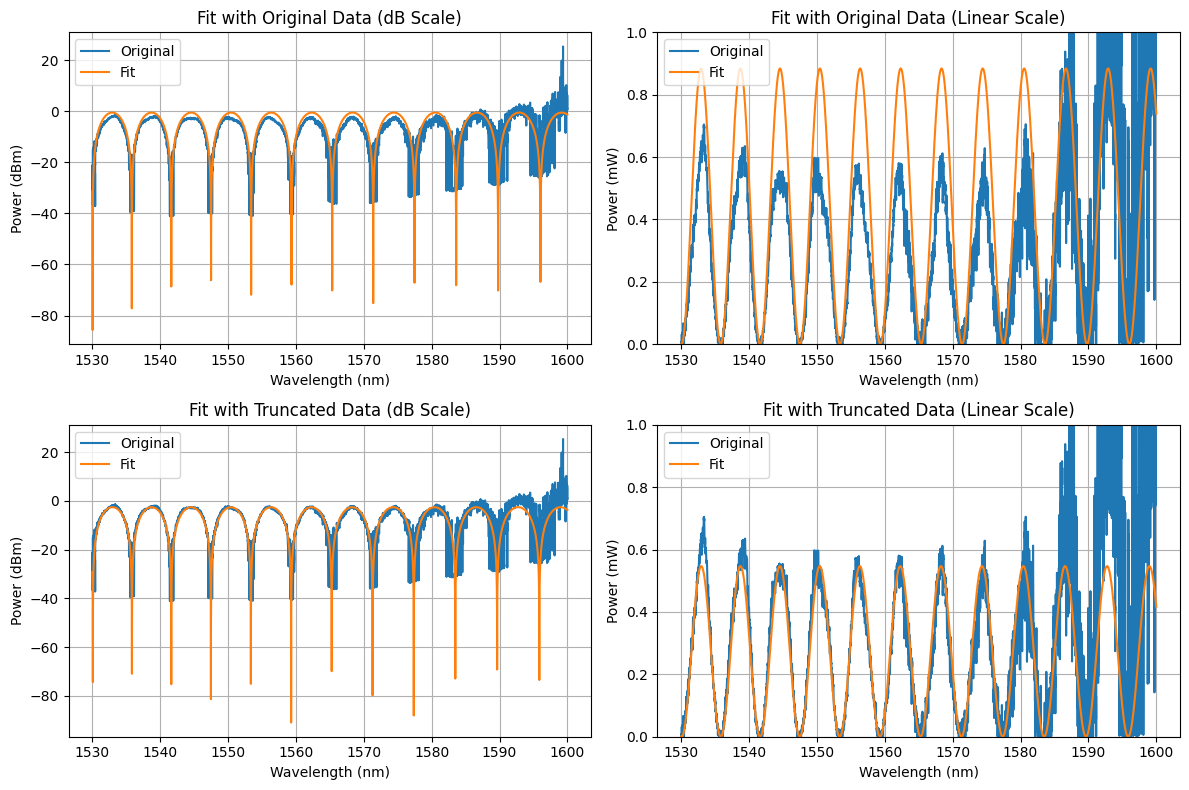

In [25]:
## Output port 1, v1
threshold_dB = 20
wavelength_mzi5_11_v1_filter, power_mzi5_11_v1_filter, wavelength_noise, power_noise = surpress_noise(wavelength_mzi5_11_v1, power_mzi5_11_v1, window_size = 0.1, threshold_dB = threshold_dB, plot=True)

power_mzi5_11_v1_fit, popt_mzi5_11_v1 = cosine_fit(wavelength_mzi5_11_v1, power_mzi5_11_v1, dL)
power_mzi5_11_v1_fit_2, popt_mzi5_11_v1_2 = cosine_fit(wavelength_mzi5_11_v1_filter, power_mzi5_11_v1_filter, dL, wavelength_out = wavelength_mzi5_11_v1)

fig, ax = plt.subplots(2,2, figsize=(12, 8))

ax[0, 0].plot(wavelength_mzi5_11_v1, power_mzi5_11_v1, label = 'Original')
ax[0, 0].plot(wavelength_mzi5_11_v1, power_mzi5_11_v1_fit, label='Fit')
ax[0, 0].set_xlabel('Wavelength (nm)')   
ax[0, 0].set_ylabel('Power (dBm)')
ax[0, 0].set_title('Fit with Original Data (dB Scale)')
ax[0, 0].legend()
ax[0, 0].grid()

ax[0, 1].plot(wavelength_mzi5_11_v1, 10**(power_mzi5_11_v1/10), label = 'Original')
ax[0, 1].plot(wavelength_mzi5_11_v1, 10**(power_mzi5_11_v1_fit/10), label='Fit')
ax[0, 1].set_ylim(0, 1)
ax[0, 1].set_xlabel('Wavelength (nm)')   
ax[0, 1].set_ylabel('Power (mW)')
ax[0, 1].set_title('Fit with Original Data (Linear Scale)')
ax[0, 1].legend()
ax[0, 1].grid()

ax[1, 0].plot(wavelength_mzi5_11_v1, power_mzi5_11_v1, label = 'Original')
ax[1, 0].plot(wavelength_mzi5_11_v1, power_mzi5_11_v1_fit_2, label='Fit')
ax[1, 0].set_xlabel('Wavelength (nm)')   
ax[1, 0].set_ylabel('Power (dBm)')
ax[1, 0].set_title('Fit with Truncated Data (dB Scale)')
ax[1, 0].legend()
ax[1, 0].grid()

ax[1, 1].plot(wavelength_mzi5_11_v1, 10**(power_mzi5_11_v1/10), label = 'Original')
ax[1, 1].plot(wavelength_mzi5_11_v1, 10**(power_mzi5_11_v1_fit_2/10), label='Fit')
ax[1, 1].set_ylim(0, 1)
ax[1, 1].set_xlabel('Wavelength (nm)')   
ax[1, 1].set_ylabel('Power (mW)')
ax[1, 1].set_title('Fit with Truncated Data (Linear Scale)')
ax[1, 1].legend()
ax[1, 1].grid()

plt.tight_layout()
plt.show()

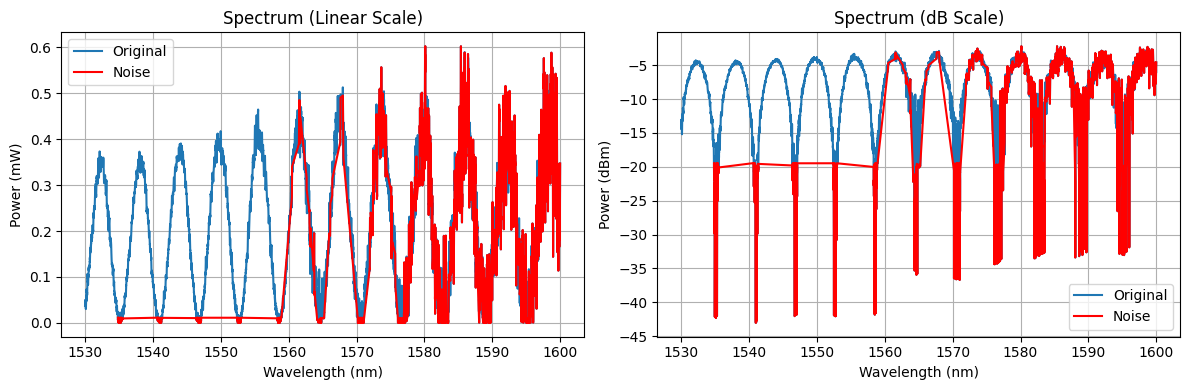

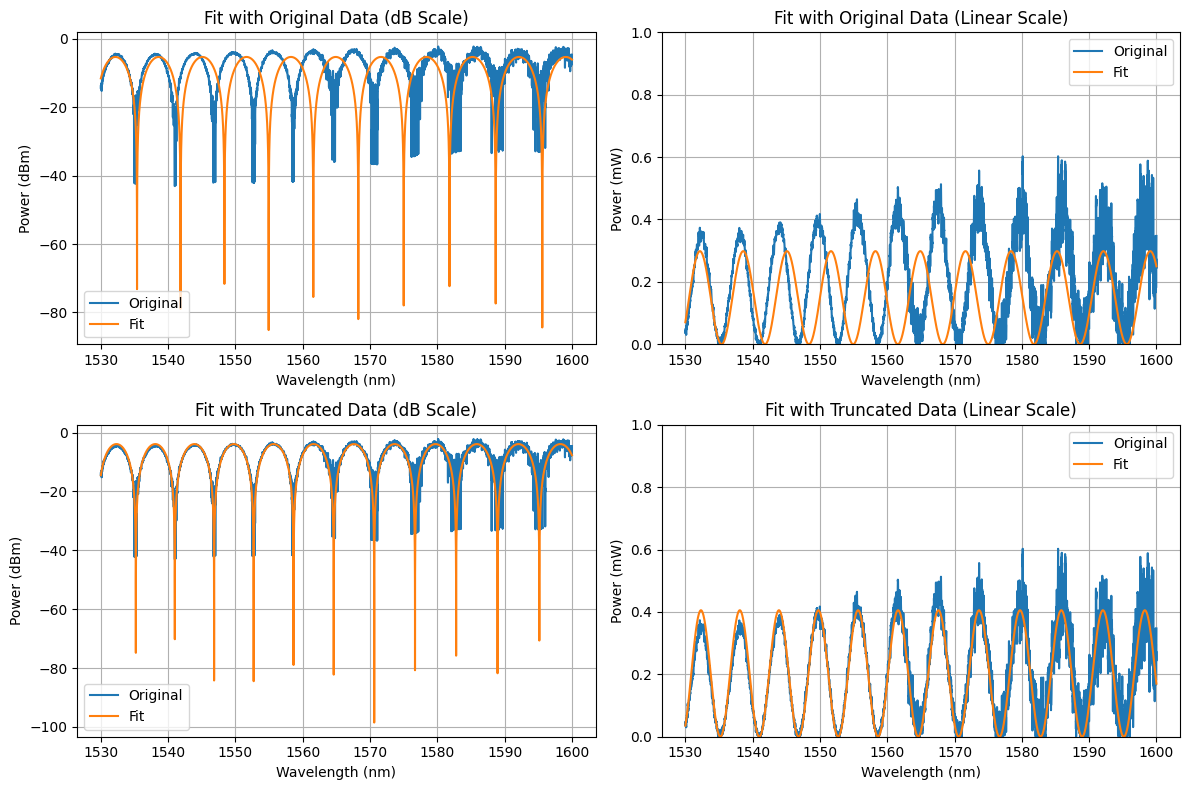

In [26]:
## Output port 1, v2
threshold_dB = 20
wavelength_mzi5_11_v2_filter, power_mzi5_11_v2_filter, wavelength_noise, power_noise = surpress_noise(wavelength_mzi5_11_v2, power_mzi5_11_v2, window_size = 0.1, threshold_dB = threshold_dB, plot=True)

power_mzi5_11_v2_fit, popt_mzi5_11_v2 = cosine_fit(wavelength_mzi5_11_v2, power_mzi5_11_v2, dL)
power_mzi5_11_v2_fit_2, popt_mzi5_11_v2_2 = cosine_fit(wavelength_mzi5_11_v2_filter, power_mzi5_11_v2_filter, dL, wavelength_out = wavelength_mzi5_11_v2)

fig, ax = plt.subplots(2,2, figsize=(12, 8))

ax[0, 0].plot(wavelength_mzi5_11_v2, power_mzi5_11_v2, label = 'Original')
ax[0, 0].plot(wavelength_mzi5_11_v2, power_mzi5_11_v2_fit, label='Fit')
ax[0, 0].set_xlabel('Wavelength (nm)')   
ax[0, 0].set_ylabel('Power (dBm)')
ax[0, 0].set_title('Fit with Original Data (dB Scale)')
ax[0, 0].legend()
ax[0, 0].grid()

ax[0, 1].plot(wavelength_mzi5_11_v2, 10**(power_mzi5_11_v2/10), label = 'Original')
ax[0, 1].plot(wavelength_mzi5_11_v2, 10**(power_mzi5_11_v2_fit/10), label='Fit')
ax[0, 1].set_ylim(0, 1)
ax[0, 1].set_xlabel('Wavelength (nm)')   
ax[0, 1].set_ylabel('Power (mW)')
ax[0, 1].set_title('Fit with Original Data (Linear Scale)')
ax[0, 1].legend()
ax[0, 1].grid()

ax[1, 0].plot(wavelength_mzi5_11_v2, power_mzi5_11_v2, label = 'Original')
ax[1, 0].plot(wavelength_mzi5_11_v2, power_mzi5_11_v2_fit_2, label='Fit')
ax[1, 0].set_xlabel('Wavelength (nm)')   
ax[1, 0].set_ylabel('Power (dBm)')
ax[1, 0].set_title('Fit with Truncated Data (dB Scale)')
ax[1, 0].legend()
ax[1, 0].grid()

ax[1, 1].plot(wavelength_mzi5_11_v2, 10**(power_mzi5_11_v2/10), label = 'Original')
ax[1, 1].plot(wavelength_mzi5_11_v2, 10**(power_mzi5_11_v2_fit_2/10), label='Fit')
ax[1, 1].set_ylim(0, 1)
ax[1, 1].set_xlabel('Wavelength (nm)')   
ax[1, 1].set_ylabel('Power (mW)')
ax[1, 1].set_title('Fit with Truncated Data (Linear Scale)')
ax[1, 1].legend()
ax[1, 1].grid()

plt.tight_layout()
plt.show()

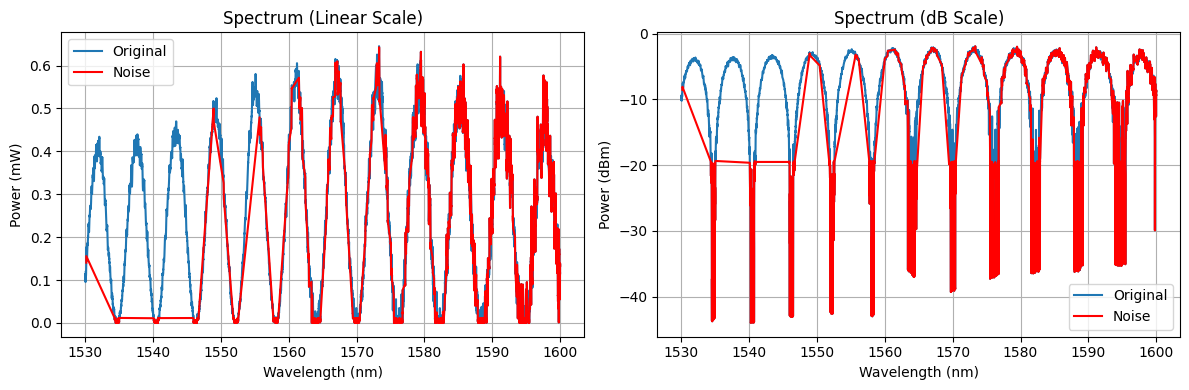

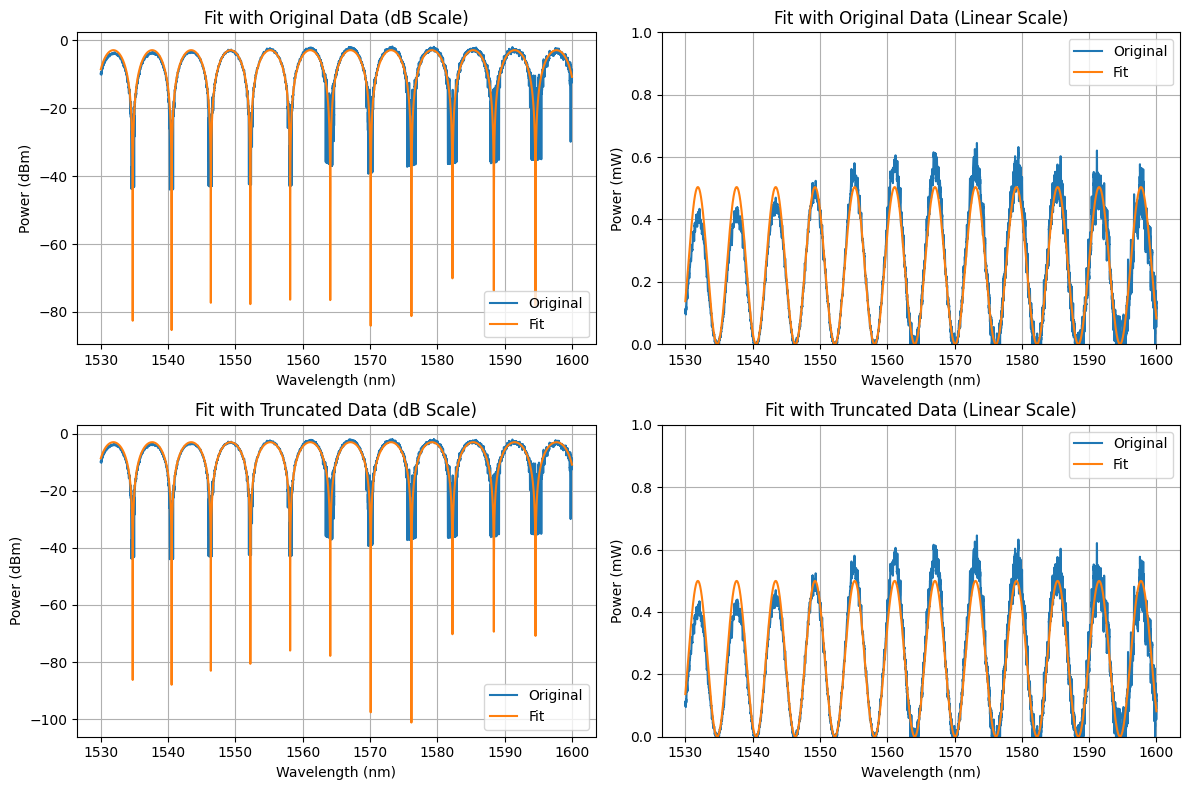

In [27]:
## Output port 1, v3
threshold_dB = 20
wavelength_mzi5_11_v3_filter, power_mzi5_11_v3_filter, wavelength_noise, power_noise = surpress_noise(wavelength_mzi5_11_v3, power_mzi5_11_v3, window_size = 0.1, threshold_dB = threshold_dB, plot=True)

power_mzi5_11_v3_fit, popt_mzi5_11_v3 = cosine_fit(wavelength_mzi5_11_v3, power_mzi5_11_v3, dL)
power_mzi5_11_v3_fit_2, popt_mzi5_11_v3_2 = cosine_fit(wavelength_mzi5_11_v3_filter, power_mzi5_11_v3_filter, dL, wavelength_out = wavelength_mzi5_11_v3)

fig, ax = plt.subplots(2,2, figsize=(12, 8))

ax[0, 0].plot(wavelength_mzi5_11_v3, power_mzi5_11_v3, label = 'Original')
ax[0, 0].plot(wavelength_mzi5_11_v3, power_mzi5_11_v3_fit, label=f'Fit')
ax[0, 0].set_xlabel('Wavelength (nm)')   
ax[0, 0].set_ylabel('Power (dBm)')
ax[0, 0].set_title('Fit with Original Data (dB Scale)')
ax[0, 0].legend()
ax[0, 0].grid()

ax[0, 1].plot(wavelength_mzi5_11_v3, 10**(power_mzi5_11_v3/10), label = 'Original')
ax[0, 1].plot(wavelength_mzi5_11_v3, 10**(power_mzi5_11_v3_fit/10), label=f'Fit')
ax[0, 1].set_ylim(0, 1)
ax[0, 1].set_xlabel('Wavelength (nm)')   
ax[0, 1].set_ylabel('Power (mW)')
ax[0, 1].set_title('Fit with Original Data (Linear Scale)')
ax[0, 1].legend()
ax[0, 1].grid()

ax[1, 0].plot(wavelength_mzi5_11_v3, power_mzi5_11_v3, label = 'Original')
ax[1, 0].plot(wavelength_mzi5_11_v3, power_mzi5_11_v3_fit_2, label=f'Fit')
ax[1, 0].set_xlabel('Wavelength (nm)')   
ax[1, 0].set_ylabel('Power (dBm)')
ax[1, 0].set_title('Fit with Truncated Data (dB Scale)')
ax[1, 0].legend()
ax[1, 0].grid()

ax[1, 1].plot(wavelength_mzi5_11_v3, 10**(power_mzi5_11_v3/10), label = 'Original')
ax[1, 1].plot(wavelength_mzi5_11_v3, 10**(power_mzi5_11_v3_fit_2/10), label=f'Fit')
ax[1, 1].set_ylim(0, 1)
ax[1, 1].set_xlabel('Wavelength (nm)')   
ax[1, 1].set_ylabel('Power (mW)')
ax[1, 1].set_title('Fit with Truncated Data (Linear Scale)')
ax[1, 1].legend()
ax[1, 1].grid()

plt.tight_layout()
plt.show()

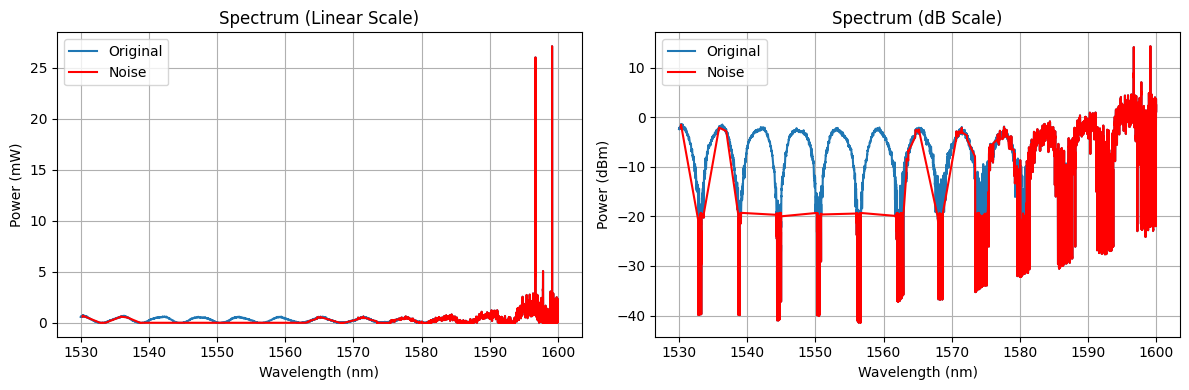

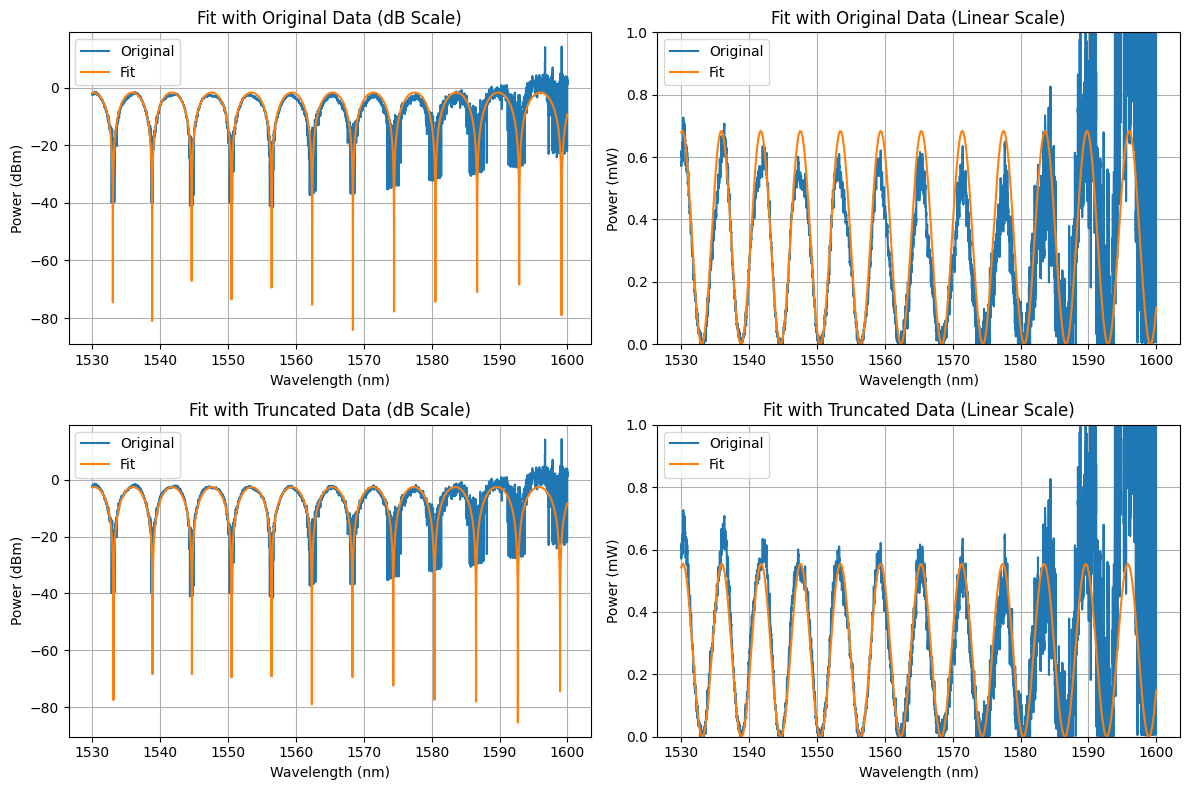

In [28]:
## Output port 2, v1
threshold_dB = 20
wavelength_mzi5_12_v1_filter, power_mzi5_12_v1_filter, wavelength_noise, power_noise = surpress_noise(wavelength_mzi5_12_v1, power_mzi5_12_v1, window_size = 0.1, threshold_dB = threshold_dB, plot=True)

power_mzi5_12_v1_fit, popt_mzi5_12_v1 = cosine_fit(wavelength_mzi5_12_v1, power_mzi5_12_v1, dL)
power_mzi5_12_v1_fit_2, popt_mzi5_12_v1_2 = cosine_fit(wavelength_mzi5_12_v1_filter, power_mzi5_12_v1_filter, dL, wavelength_out = wavelength_mzi5_12_v1)

fig, ax = plt.subplots(2,2, figsize=(12, 8))

ax[0, 0].plot(wavelength_mzi5_12_v1, power_mzi5_12_v1, label = 'Original')
ax[0, 0].plot(wavelength_mzi5_12_v1, power_mzi5_12_v1_fit, label=f'Fit')
ax[0, 0].set_xlabel('Wavelength (nm)')   
ax[0, 0].set_ylabel('Power (dBm)')
ax[0, 0].set_title('Fit with Original Data (dB Scale)')
ax[0, 0].legend()
ax[0, 0].grid()

ax[0, 1].plot(wavelength_mzi5_12_v1, 10**(power_mzi5_12_v1/10), label = 'Original')
ax[0, 1].plot(wavelength_mzi5_12_v1, 10**(power_mzi5_12_v1_fit/10), label=f'Fit')
ax[0, 1].set_ylim(0, 1)
ax[0, 1].set_xlabel('Wavelength (nm)')   
ax[0, 1].set_ylabel('Power (mW)')
ax[0, 1].set_title('Fit with Original Data (Linear Scale)')
ax[0, 1].legend()
ax[0, 1].grid()

ax[1, 0].plot(wavelength_mzi5_12_v1, power_mzi5_12_v1, label = 'Original')
ax[1, 0].plot(wavelength_mzi5_12_v1, power_mzi5_12_v1_fit_2, label=f'Fit')
ax[1, 0].set_xlabel('Wavelength (nm)')   
ax[1, 0].set_ylabel('Power (dBm)')
ax[1, 0].set_title('Fit with Truncated Data (dB Scale)')
ax[1, 0].legend()
ax[1, 0].grid()

ax[1, 1].plot(wavelength_mzi5_12_v1, 10**(power_mzi5_12_v1/10), label = 'Original')
ax[1, 1].plot(wavelength_mzi5_12_v1, 10**(power_mzi5_12_v1_fit_2/10), label=f'Fit')
ax[1, 1].set_ylim(0, 1)
ax[1, 1].set_xlabel('Wavelength (nm)')   
ax[1, 1].set_ylabel('Power (mW)')
ax[1, 1].set_title('Fit with Truncated Data (Linear Scale)')
ax[1, 1].legend()
ax[1, 1].grid()

plt.tight_layout()
plt.show()

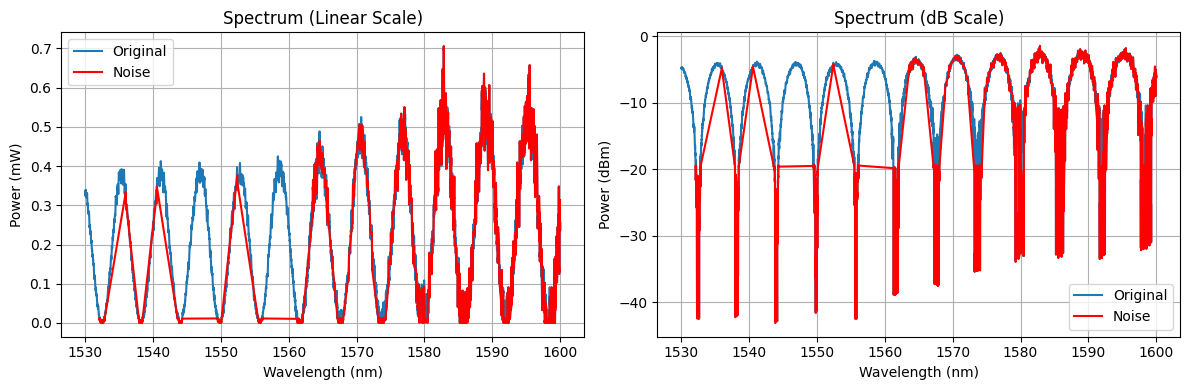

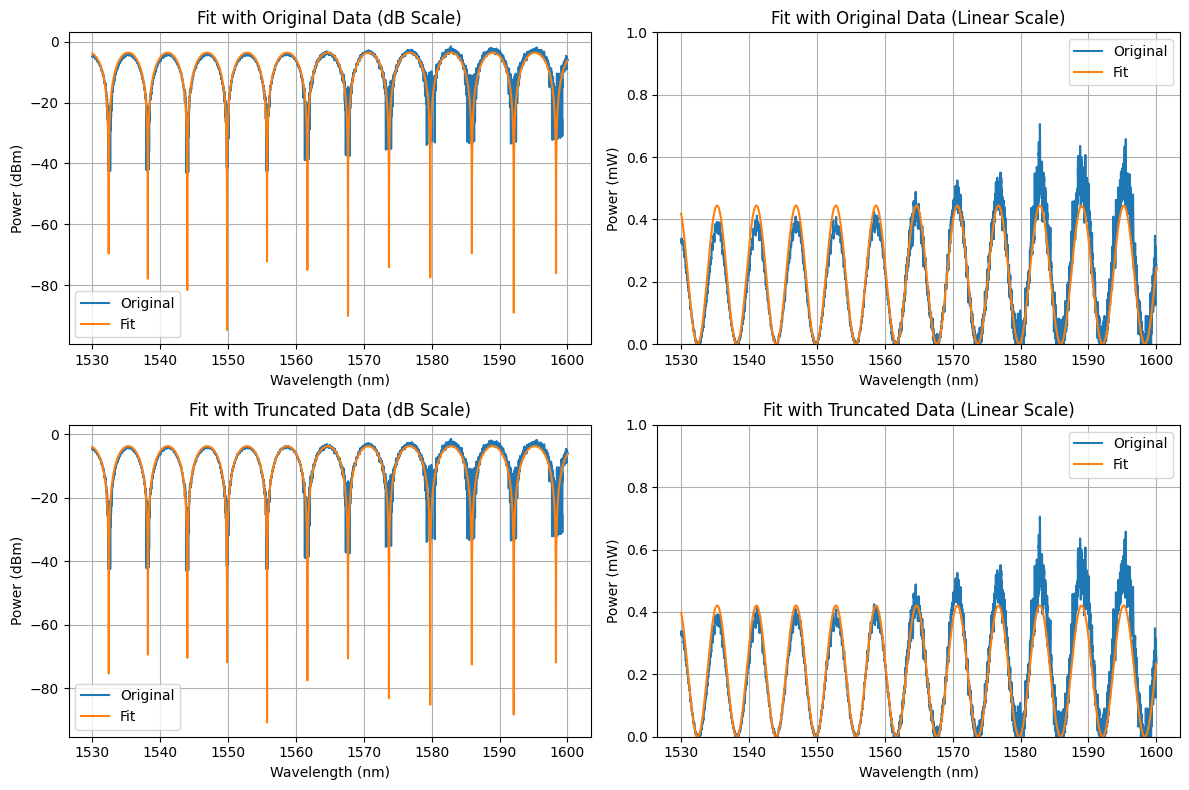

In [29]:
## Output port 2, v2
threshold_dB = 20
wavelength_mzi5_12_v2_filter, power_mzi5_12_v2_filter, wavelength_noise, power_noise = surpress_noise(wavelength_mzi5_12_v2, power_mzi5_12_v2, window_size = 0.1, threshold_dB = threshold_dB, plot=True)

power_mzi5_12_v2_fit, popt_mzi5_12_v2 = cosine_fit(wavelength_mzi5_12_v2, power_mzi5_12_v2, dL)
power_mzi5_12_v2_fit_2, popt_mzi5_12_v2_2 = cosine_fit(wavelength_mzi5_12_v2_filter, power_mzi5_12_v2_filter, dL, wavelength_out = wavelength_mzi5_12_v2)

fig, ax = plt.subplots(2,2, figsize=(12, 8))

ax[0, 0].plot(wavelength_mzi5_12_v2, power_mzi5_12_v2, label = 'Original')
ax[0, 0].plot(wavelength_mzi5_12_v2, power_mzi5_12_v2_fit, label='Fit')
ax[0, 0].set_xlabel('Wavelength (nm)')   
ax[0, 0].set_ylabel('Power (dBm)')
ax[0, 0].set_title('Fit with Original Data (dB Scale)')
ax[0, 0].legend()
ax[0, 0].grid()

ax[0, 1].plot(wavelength_mzi5_12_v2, 10**(power_mzi5_12_v2/10), label = 'Original')
ax[0, 1].plot(wavelength_mzi5_12_v2, 10**(power_mzi5_12_v2_fit/10), label='Fit')
ax[0, 1].set_ylim(0, 1)
ax[0, 1].set_xlabel('Wavelength (nm)')   
ax[0, 1].set_ylabel('Power (mW)')
ax[0, 1].set_title('Fit with Original Data (Linear Scale)')
ax[0, 1].legend()
ax[0, 1].grid()

ax[1, 0].plot(wavelength_mzi5_12_v2, power_mzi5_12_v2, label = 'Original')
ax[1, 0].plot(wavelength_mzi5_12_v2, power_mzi5_12_v2_fit_2, label='Fit')
ax[1, 0].set_xlabel('Wavelength (nm)')   
ax[1, 0].set_ylabel('Power (dBm)')
ax[1, 0].set_title('Fit with Truncated Data (dB Scale)')
ax[1, 0].legend()
ax[1, 0].grid()

ax[1, 1].plot(wavelength_mzi5_12_v2, 10**(power_mzi5_12_v2/10), label = 'Original')
ax[1, 1].plot(wavelength_mzi5_12_v2, 10**(power_mzi5_12_v2_fit_2/10), label='Fit')
ax[1, 1].set_ylim(0, 1)
ax[1, 1].set_xlabel('Wavelength (nm)')   
ax[1, 1].set_ylabel('Power (mW)')
ax[1, 1].set_title('Fit with Truncated Data (Linear Scale)')
ax[1, 1].legend()
ax[1, 1].grid()

plt.tight_layout()
plt.show()

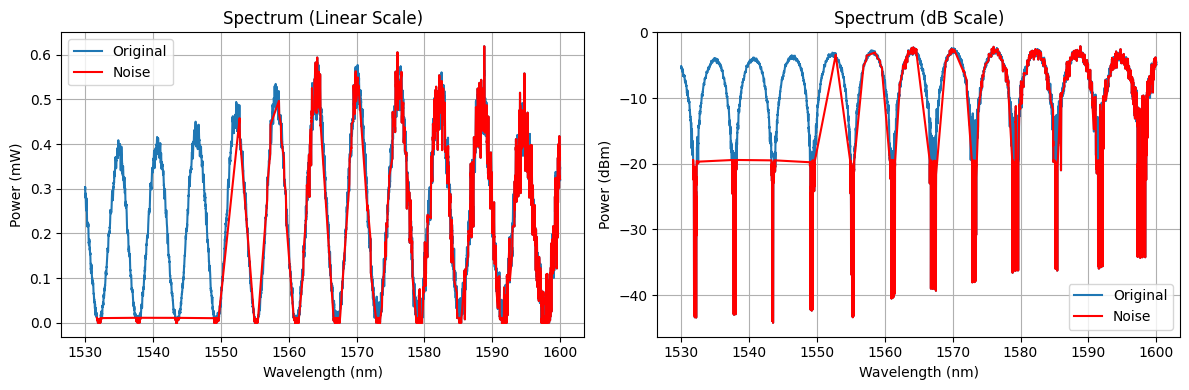

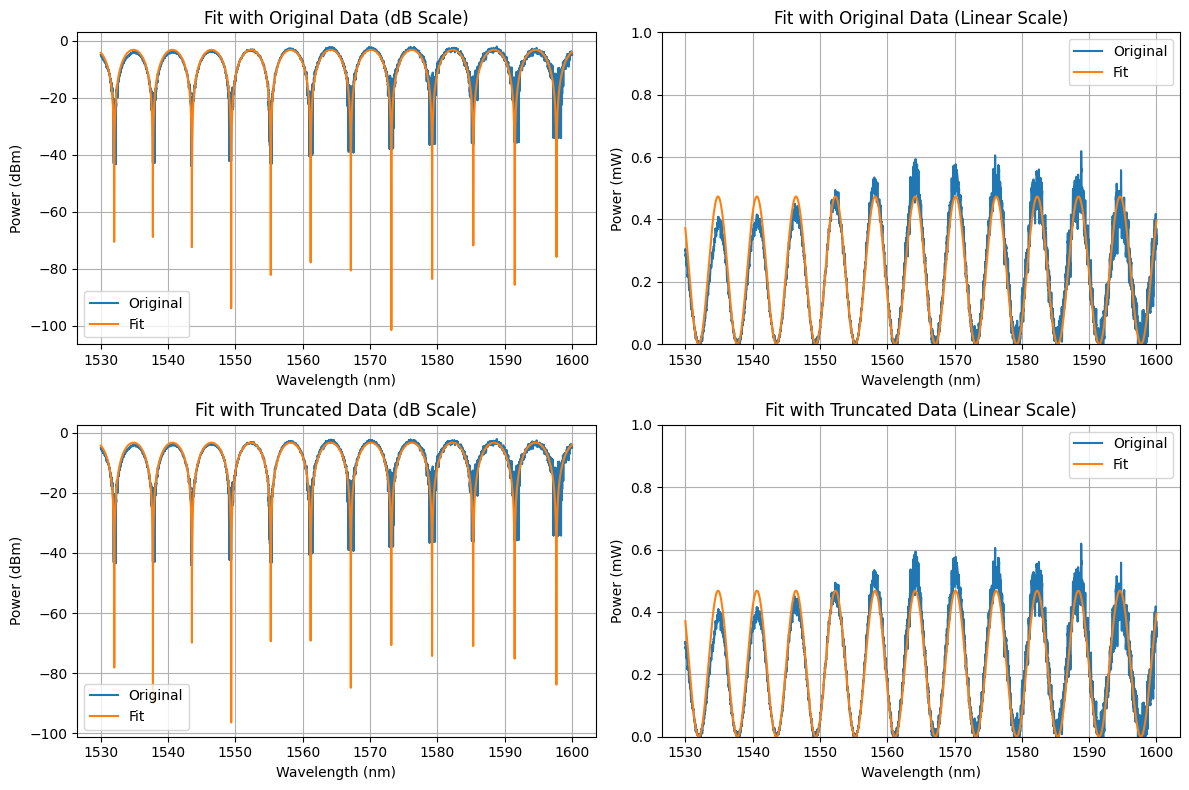

In [30]:
## Output port 2, v3
threshold_dB = 20
wavelength_mzi5_12_v3_filter, power_mzi5_12_v3_filter, wavelength_noise, power_noise = surpress_noise(wavelength_mzi5_12_v3, power_mzi5_12_v3, window_size = 0.1, threshold_dB = threshold_dB, plot=True)

power_mzi5_12_v3_fit, popt_mzi5_12_v3 = cosine_fit(wavelength_mzi5_12_v3, power_mzi5_12_v3, dL)
power_mzi5_12_v3_fit_2, popt_mzi5_12_v3_2 = cosine_fit(wavelength_mzi5_12_v3_filter, power_mzi5_12_v3_filter, dL, wavelength_out = wavelength_mzi5_12_v3)

fig, ax = plt.subplots(2,2, figsize=(12, 8))

ax[0, 0].plot(wavelength_mzi5_12_v3, power_mzi5_12_v3, label = 'Original')
ax[0, 0].plot(wavelength_mzi5_12_v3, power_mzi5_12_v3_fit, label='Fit')
ax[0, 0].set_xlabel('Wavelength (nm)')   
ax[0, 0].set_ylabel('Power (dBm)')
ax[0, 0].set_title('Fit with Original Data (dB Scale)')
ax[0, 0].legend()
ax[0, 0].grid()

ax[0, 1].plot(wavelength_mzi5_12_v3, 10**(power_mzi5_12_v3/10), label = 'Original')
ax[0, 1].plot(wavelength_mzi5_12_v3, 10**(power_mzi5_12_v3_fit/10), label='Fit')
ax[0, 1].set_ylim(0, 1)
ax[0, 1].set_xlabel('Wavelength (nm)')   
ax[0, 1].set_ylabel('Power (mW)')
ax[0, 1].set_title('Fit with Original Data (Linear Scale)')
ax[0, 1].legend()
ax[0, 1].grid()

ax[1, 0].plot(wavelength_mzi5_12_v3, power_mzi5_12_v3, label = 'Original')
ax[1, 0].plot(wavelength_mzi5_12_v3, power_mzi5_12_v3_fit_2, label='Fit')
ax[1, 0].set_xlabel('Wavelength (nm)')   
ax[1, 0].set_ylabel('Power (dBm)')
ax[1, 0].set_title('Fit with Truncated Data (dB Scale)')
ax[1, 0].legend()
ax[1, 0].grid()

ax[1, 1].plot(wavelength_mzi5_12_v3, 10**(power_mzi5_12_v3/10), label = 'Original')
ax[1, 1].plot(wavelength_mzi5_12_v3, 10**(power_mzi5_12_v3_fit_2/10), label='Fit')
ax[1, 1].set_ylim(0, 1)
ax[1, 1].set_xlabel('Wavelength (nm)')   
ax[1, 1].set_ylabel('Power (mW)')
ax[1, 1].set_title('Fit with Truncated Data (Linear Scale)')
ax[1, 1].legend()
ax[1, 1].grid()

plt.tight_layout()
plt.show()

### Absolute Dephase

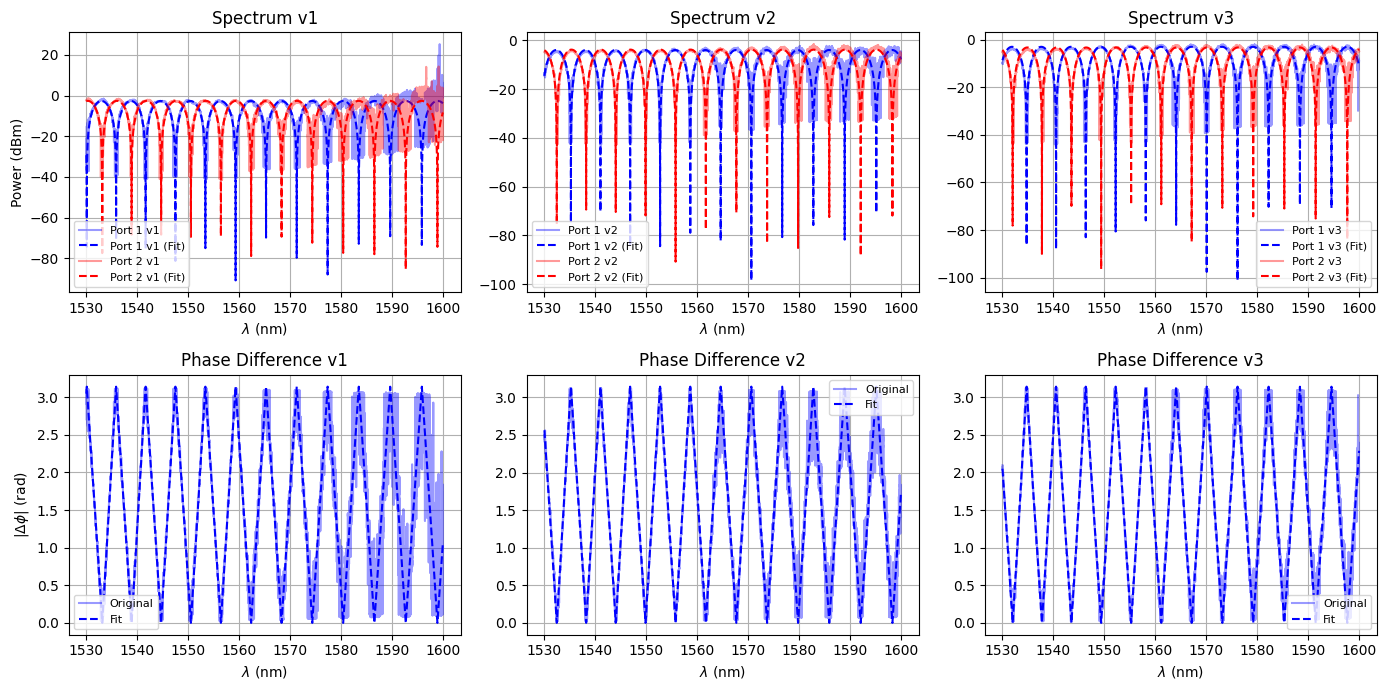

In [31]:
fig, axs = plt.subplots(2, 3, figsize=(14, 7))

axs[0, 0].plot(wavelength_mzi5_11_v1, power_mzi5_11_v1, label='Port 1 v1', alpha=0.4, color='blue')
axs[0, 0].plot(wavelength_mzi5_11_v1, power_mzi5_11_v1_fit_2, label='Port 1 v1 (Fit)', color='blue', linestyle='--')
axs[0, 0].plot(wavelength_mzi5_12_v1, power_mzi5_12_v1, label='Port 2 v1', alpha=0.4, color='red')
axs[0, 0].plot(wavelength_mzi5_12_v1, power_mzi5_12_v1_fit_2, label='Port 2 v1 (Fit)', color='red', linestyle='--')
axs[0, 0].set_title('Spectrum v1')
axs[0, 0].set_xlabel(r'$\lambda$ (nm)')
axs[0, 0].set_ylabel('Power (dBm)')
axs[0, 0].grid()
axs[0, 0].legend(fontsize=8)

axs[0, 1].plot(wavelength_mzi5_11_v2, power_mzi5_11_v2, label='Port 1 v2', alpha=0.4, color='blue')
axs[0, 1].plot(wavelength_mzi5_11_v2, power_mzi5_11_v2_fit_2, label='Port 1 v2 (Fit)', color='blue', linestyle='--')
axs[0, 1].plot(wavelength_mzi5_12_v2, power_mzi5_12_v2, label='Port 2 v2', alpha=0.4, color='red')
axs[0, 1].plot(wavelength_mzi5_12_v2, power_mzi5_12_v2_fit_2, label='Port 2 v2 (Fit)', color='red', linestyle='--')
axs[0, 1].set_title('Spectrum v2')
axs[0, 1].set_xlabel(r'$\lambda$ (nm)')
axs[0, 1].grid()
axs[0, 1].legend(fontsize=8)

axs[0, 2].plot(wavelength_mzi5_11_v3, power_mzi5_11_v3, label='Port 1 v3', alpha=0.4, color='blue')
axs[0, 2].plot(wavelength_mzi5_11_v3, power_mzi5_11_v3_fit_2, label='Port 1 v3 (Fit)', color='blue', linestyle='--')
axs[0, 2].plot(wavelength_mzi5_12_v3, power_mzi5_12_v3, label='Port 2 v3', alpha=0.4, color='red')
axs[0, 2].plot(wavelength_mzi5_12_v3, power_mzi5_12_v3_fit_2, label='Port 2 v3 (Fit)', color='red', linestyle='--')
axs[0, 2].set_title('Spectrum v3')
axs[0, 2].set_xlabel(r'$\lambda$ (nm)')
axs[0, 2].grid()
axs[0, 2].legend(fontsize=8)

delta_phi_v1 = ideal_dephase(wavelength_mzi5_11_v1, power_mzi5_11_v1, power_mzi5_12_v1)
delta_phi_v2 = ideal_dephase(wavelength_mzi5_11_v2, power_mzi5_11_v2, power_mzi5_12_v2)
delta_phi_v3 = ideal_dephase(wavelength_mzi5_11_v3, power_mzi5_11_v3, power_mzi5_12_v3)

delta_phi_v1_fit = ideal_dephase(wavelength_mzi5_11_v1, power_mzi5_11_v1_fit_2, power_mzi5_12_v1_fit_2)
delta_phi_v2_fit = ideal_dephase(wavelength_mzi5_11_v2, power_mzi5_11_v2_fit_2, power_mzi5_12_v2_fit_2)
delta_phi_v3_fit = ideal_dephase(wavelength_mzi5_11_v3, power_mzi5_11_v3_fit_2, power_mzi5_12_v3_fit_2)

axs[1, 0].plot(wavelength_mzi5_11_v1, delta_phi_v1, label='Original', alpha=0.4, color='blue')
axs[1, 0].plot(wavelength_mzi5_11_v1, delta_phi_v1_fit, label='Fit', color='blue', linestyle='--')
axs[1, 0].set_title('Phase Difference v1')
axs[1, 0].set_xlabel(r'$\lambda$ (nm)')
axs[1, 0].set_ylabel(r'$|\Delta \phi|$ (rad)')
axs[1, 0].legend(fontsize=8)
axs[1, 0].grid()

axs[1, 1].plot(wavelength_mzi5_11_v2, delta_phi_v2, label='Original', alpha=0.4, color='blue')
axs[1, 1].plot(wavelength_mzi5_11_v2, delta_phi_v2_fit, label='Fit', color='blue', linestyle='--')
axs[1, 1].set_title('Phase Difference v2')
axs[1, 1].set_xlabel(r'$\lambda$ (nm)')
axs[1, 1].legend(fontsize=8)
axs[1, 1].grid()

axs[1, 2].plot(wavelength_mzi5_11_v3, delta_phi_v3, label='Original', alpha=0.4, color='blue')
axs[1, 2].plot(wavelength_mzi5_11_v3, delta_phi_v3_fit, label='Fit', color='blue', linestyle='--')
axs[1, 2].set_title('Phase Difference v3')
axs[1, 2].set_xlabel(r'$\lambda$ (nm)')
axs[1, 2].legend(fontsize=8)
axs[1, 2].grid()

plt.tight_layout()
plt.show()

### Refractive Index Estimation

FSR = 5.97 nm
ng = [1.8808218  1.89508191 1.90951122 1.92457649 1.93916326 1.95447231
 1.96868986 1.98279001 1.99827946 2.01432697 2.03120107]


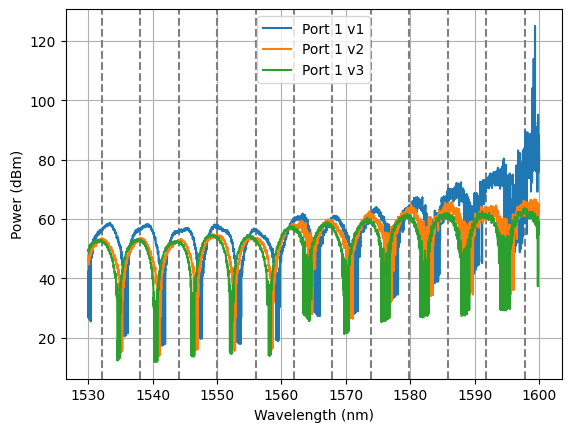

In [32]:
# Processing parameters
threshold = 3
separation = 5
dL = 210e-6

# Calculate FSR and group index
fsr_v1, ng_v1, indices_v1 = calculate_FSR(wavelength_mzi5_11_v1, power_mzi5_11_v1, threshold, separation, dL, plot=False)
fsr_v2, ng_v2, indices_v2 = calculate_FSR(wavelength_mzi5_11_v2, power_mzi5_11_v2, threshold, separation, dL, plot=False)
fsr_v3, ng_v3, indices_v3 = calculate_FSR(wavelength_mzi5_11_v3, power_mzi5_11_v3, threshold, separation, dL, plot=False)

ng_v1 = ng_v1[1:]
indices_v1 = indices_v1[1:]
ng_v3 = ng_v3[:-1]
indices_v3 = indices_v3[:-1]

fsr_mean = np.mean([fsr_v1, fsr_v2, fsr_v3])
ng_mean = mean_array([ng_v1, ng_v2, ng_v3])

print(f"FSR = {fsr_mean:.2f} nm")
print(f"ng = {ng_mean}")

indices = mean_array([indices_v1, indices_v2, indices_v3]).astype(int)

for i in range(len(indices) + 1):
    wl = wavelength_mzi5_11_v1[indices[0]] + (i-1/2)*fsr_mean
    wl_min = min(wavelength_mzi5_11_v1)
    wl_max = max(wavelength_mzi5_11_v1)
    
    if wl_min < wl < wl_max:
        plt.axvline(wl, color='gray', linestyle='--')

plt.plot(wavelength_mzi5_11_v1, power_mzi5_11_v1 - power_wg_v1, label='Port 1 v1')
plt.plot(wavelength_mzi5_11_v2, power_mzi5_11_v2 - power_wg_v2, label='Port 1 v2')
plt.plot(wavelength_mzi5_11_v3, power_mzi5_11_v3 - power_wg_v3, label='Port 1 v3')

plt.xlabel('Wavelength (nm)')
plt.ylabel('Power (dBm)')
plt.legend()
plt.grid()
plt.show()

In [33]:
## Center
wavelength_dut_center = wavelength_mzi5_11_v2 
power_dut_center = power_mzi5_11_v2 
indices_center = indices_v2
ng_center = ng_v2

## Right
wavelength_dut_right = wavelength_mzi5_11_v1
power_dut_right = power_mzi5_11_v1
indices_right = indices_v1

## Left
wavelength_dut_left = wavelength_mzi5_11_v3
power_dut_left = power_mzi5_11_v3
indices_left = indices_v3

## General
fsr = fsr_mean
plot = False

delta_lambda, delta_neff = refractive_indices(wavelength_dut_right, wavelength_dut_center, wavelength_dut_left, power_dut_right, power_dut_center, power_dut_left, indices_right, indices_center, indices_left, fsr, ng_center, plot)
print(f'Δn_eff = {delta_neff}')

Δn_eff = [0.00062121 0.00075294 0.00077166 0.0009173  0.00080841 0.00080291
 0.00083354 0.00078387 0.00071537 0.00122365 0.00057354]
